# Abundance Analysis

Viral abundance, lifestyle, host association, and core-phage analyses.


## Notebook Setup


In [1]:
# Load core libraries
%matplotlib widget

import os
import glob
import warnings
import statistics
import random

# Load data libraries
import numpy as np
import pandas as pd

# Load stats libraries
from scipy import stats
from scipy.signal import find_peaks
from scipy.stats import (
    gaussian_kde,
    linregress,
    mannwhitneyu,
    pearsonr,
    shapiro,
    spearmanr,
    ttest_ind,
    wilcoxon,
)

# Load plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import colors, gridspec
from matplotlib.ticker import MultipleLocator
from matplotlib import patches as mpatches

from upsetplot import UpSet, from_indicators
from scipy.spatial.distance import pdist, squareform

# Load bioinformatics libraries
from Bio import Entrez
from ete4 import NCBITaxa

# Load phylogeny libraries
from skbio.stats.distance import DistanceMatrix
try:
    from skbio.stats.distance import mantel
    HAS_SKBIO = True
except ImportError:
    mantel = None
    HAS_SKBIO = False

warnings.filterwarnings("ignore")


### Plotting Preferences


In [2]:
# Set plot colors
sns.set_style(
    "ticks",
    {
        "axes.grid": True,
        "grid.color": "#BFBFBF",
        "grid.linestyle": "-",
        "grid.linewidth": 0.35,
        "axes.facecolor": "white",
        "figure.facecolor": "white",
    },
)
sns.set_palette("colorblind")

# Set rcParams
# Set background and export
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"
plt.rcParams["savefig.transparent"] = False
plt.rcParams["savefig.bbox"] = "tight"

# Set line and axis styles
plt.rcParams["axes.linewidth"] = 0.7
plt.rcParams["axes.edgecolor"] = "#222222"
plt.rcParams["xtick.major.width"] = 0.7
plt.rcParams["ytick.major.width"] = 0.7
plt.rcParams["xtick.minor.width"] = 0.5
plt.rcParams["ytick.minor.width"] = 0.5
plt.rcParams["xtick.major.size"] = 4.5
plt.rcParams["ytick.major.size"] = 4.5
plt.rcParams["xtick.minor.size"] = 2.5
plt.rcParams["ytick.minor.size"] = 2.5
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"
plt.rcParams["grid.linewidth"] = 0.35
plt.rcParams["grid.alpha"] = 0.8
plt.rcParams["patch.linewidth"] = 0.7
plt.rcParams["patch.edgecolor"] = "#222222"
plt.rcParams["lines.linewidth"] = 1.0
plt.rcParams["lines.markersize"] = 4

# Set fonts
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Liberation Sans"]
plt.rcParams["text.usetex"] = False
plt.rcParams["font.size"] = 5
plt.rcParams["axes.titlepad"] = 5
plt.rcParams["axes.titlesize"] = 7
plt.rcParams["axes.labelsize"] = 7
plt.rcParams["xtick.labelsize"] = 6
plt.rcParams["ytick.labelsize"] = 6
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["axes.titleweight"] = "bold"

# Set legend style
plt.rcParams["legend.frameon"] = True
plt.rcParams["legend.fancybox"] = False
plt.rcParams["legend.framealpha"] = 1.0
plt.rcParams["legend.edgecolor"] = "#444444"
plt.rcParams["legend.facecolor"] = "white"
plt.rcParams["legend.fontsize"] = 5
plt.rcParams["legend.title_fontsize"] = 6
plt.rcParams["legend.labelspacing"] = 0.25
plt.rcParams["legend.borderpad"] = 0.35
plt.rcParams["legend.handlelength"] = 1.5
plt.rcParams["legend.handletextpad"] = 0.45

# Set boxplot style
plt.rcParams["boxplot.patchartist"] = True
plt.rcParams["boxplot.boxprops.linewidth"] = 0.7
plt.rcParams["boxplot.whiskerprops.linewidth"] = 0.7
plt.rcParams["boxplot.capprops.linewidth"] = 0.7
plt.rcParams["boxplot.medianprops.linewidth"] = 0.9

# Set output defaults
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["figure.dpi"] = 150
plt.rcParams["svg.fonttype"] = "none"
points_to_inches = 1 / 72


### Paths and Shared Variables


In [3]:
work_dir="/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/"

mapping_dir=work_dir+ "06_MAPPING"
clean_dir=work_dir+ "02_CLEAN_DATA"
sampling="tot"

DNA_metadata_file="/home/lmf/PhylloVir/VIRAL_WORLD/DNA_extraction_metadata.tsv"

raw_counts_file=mapping_dir + "/counts_raw.txt"
norm_counts_file=mapping_dir + "/counts_normalised.txt"
raw_rpkm_file=mapping_dir + "/RPKM_raw.txt"
norm_rpkm_file=mapping_dir + "/RPKM_normalised.txt"
percentage_rpkm_file=mapping_dir + "/breadth_coverage_percent.txt"
bases_rpkm_file=mapping_dir + "/breadth_coverage_bases.txt"
contig_length_file=mapping_dir + "/contig_lengths.txt"

raw_counts_file_sub=mapping_dir + "/counts_raw_sub.txt"
norm_counts_file_sub=mapping_dir + "/counts_normalised_sub.txt"
raw_rpkm_file_sub=mapping_dir + "/RPKM_raw_sub.txt"
norm_rpkm_file_sub=mapping_dir + "/RPKM_normalised_sub.txt"
percentage_rpkm_file_sub=mapping_dir + "/breadth_coverage_percent_sub.txt"
bases_rpkm_file_sub=mapping_dir + "/breadth_coverage_bases_sub.txt"
contig_length_file_sub=mapping_dir + "/contig_lengths_sub.txt"

filtered_list=work_dir+"05_vOTUs/filtered_95-85_positive_viral_contigs_list.tot.txt"
merged_summary=work_dir+"05_vOTUs/vOTU_clustering_summary.tot.csv"
blast_results=work_dir + "07_ANNOTATION/blast_output_ViralRefSeq_filtered_95-85_positive_viral_contigs.tot.csv"
iphop_results=work_dir + "07_ANNOTATION/iphop_hostID_filtered_95-85_positive_viral_contigs.tot_resultsDir/Host_prediction_to_genus_m90.csv"
PhaGCN_results=work_dir + "07_ANNOTATION/PhaGCN_taxonomy_report_filtered_95-85_positive_viral_contigs.tot.csv"
nucleotide_content=work_dir+"07_ANNOTATION/nucleotide_content_viral_contigs_clustered_with_filtered_95-85_positive_viral_contigs.tot.tsv"
viga_topology=work_dir + "07_ANNOTATION/viga_topology_filtered_95-85_positive_viral_contigstot.txt"


qc_read_counts=work_dir +'/FIGURES_AND_TABLES/01_qc_read_counts_paired.tot.csv'

DNA_metadata_file="/home/lmf/PhylloVir/VIRAL_WORLD/DNA_extraction_metadata.tsv"
mapping_dir=work_dir+ "06_MAPPING"


filtered_RPKM_norm_file_full=mapping_dir + "/filtered_RPKM_normalised_tot.txt"

filtered_RPKM_norm_file=mapping_dir + "/REFERENCES/filtered_active_vOTUs_threshold_1p5_RPKM_normalised_tot.txt"
filtered_RPKM_norm_sub_file=mapping_dir + "/REFERENCES/filtered_active_vOTUs_threshold_1p5_RPKM_normalised_sub.txt"

filtered_75_RPKM_norm_file=mapping_dir + "/REFERENCES/filtered_75_active_vOTUs_threshold_1p5_RPKM_normalised_tot.txt"
filtered_counts_norm_file=mapping_dir + "/REFERENCES/filtered_active_vOTUs_threshold_1p5_counts_normalised_tot.txt"
filtered_counts_norm_sub_file=mapping_dir + "/REFERENCES/filtered_active_vOTUs_threshold_1p5_counts_normalised_sub.txt"


### Sample Definitions


In [4]:
# Define sample subsets

# Define main sample set
SAMPLES = [
    'vFL', 'vOL', 'vF23', 
    'vN1', 'vN2', 'vN3', 
    'vZ1', 'vZ2', 'vZ3', 
    'vF1A', 'vF2A', 'vF3A', 
    'vF1B', 'vF2B', 'vF3B', 
    'vF1C', 'vF2C', 'vF3C', 
    'vO1A', 'vO2A', 'vO3A', 
    'vO1B', 'vO2B', 'vO3B', 
    'vO1C', 'vO2C', 'vO3C', 
    'vS1B', 'vS2B', 'vS3B', 
    'vS1C', 'vS2C', 'vS3C', 
    'vNWd', 'vSWd', 'vSEd',
]

# Define Denmark core set
SAMPLES_dk_core = [
    'vFL', 'vOL', 'vF23', 
    'vN1', 'vN2', 'vN3', 
    'vZ1', 'vZ2', 'vZ3', 
    'vF1A', 'vF2A', 'vF3A', 
    'vF1B', 'vF2B', 'vF3B', 
    'vF1C', 'vF2C', 'vF3C', 
    'vO1A', 'vO2A', 'vO3A', 
    'vO1B', 'vO2B', 'vO3B', 
    'vO1C', 'vO2C', 'vO3C', 
    'vS1B', 'vS2B', 'vS3B', 
    'vS1C', 'vS2C', 'vS3C',
]

# Define sample groups

# Define viral groups
viral_group_samples_dict = {
    'USA\n2022': ['vSWd', 'vSEd', 'vNWd'],
    'DK\n2020': ['vOL', 'vFL'],
    'DK\n2021': ['vZ1', 'vZ2', 'vZ3', 'vN1', 'vN2', 'vN3'],
    'DK Pennultimate\n2022': ['vO1A', 'vO2A', 'vO3A', 'vO1B', 'vO2B', 'vO3B', 'vO1C', 'vO2C', 'vO3C'],
    'DK Flag\n2022': ['vF1A', 'vF2A', 'vF3A', 'vF1B', 'vF2B', 'vF3B', 'vF1C', 'vF2C', 'vF3C'],
    'DK Spike\n2022': ['vS1B', 'vS2B', 'vS3B', 'vS1C', 'vS2C', 'vS3C'],
}

# Define bacterial groups
bacterial_group_samples_dict = {
    'USA\n2022': ['bSWd', 'bSEd', 'bNWd'],
    'DK\n2020': ['bOL', 'bFL'],
    'DK\n2021': ['bZ1', 'bZ2', 'bZ3', 'bN1', 'bN2', 'bN3'],
    'DK Pennultimate\n2022': ['bO1A', 'bO2A', 'bO3A', 'bO1B', 'bO2B', 'bO3B', 'bO1C', 'bO2C', 'bO3C'],
    'DK Flag\n2022': ['bF1A', 'bF2A', 'bF3A', 'bF1B', 'bF2B', 'bF3B', 'bF1C', 'bF2C', 'bF3C'],
    'DK Spike\n2022': ['bS1B', 'bS2B', 'bS3B', 'bS1C', 'bS2C', 'bS3C'],
}


# Define higher-level subsets

# Define Denmark samples
DENMARK = [
    'vBRB', 'vF1A', 'vF1B', 'vF1C', 'vF1aB', 
    'vF2A', 'vF2B', 'vF2C', 'vF2aA', 
    'vF3A', 'vF3B', 'vF3C', 
    'vFL', 'vFL_amp', 'vN1', 'vN2', 'vN3', 
    'vO1A', 'vO1B', 'vO1C', 'vO1aB', 
    'vO2A', 'vO2B', 'vO2C', 'vO2aA', 
    'vO3A', 'vO3B', 'vO3C', 
    'vOL', 'vOL_amp', 
    'vS1B', 'vS1C', 'vS2B', 'vS2C', 'vS3B', 'vS3C', 
    'vWRB', 'vZ1', 'vZ2', 'vZ3', 'vF23',
]

# Define leaf samples
LEAF = [
    'vF1A', 'vF1B', 'vF1C', 'vF1aB', 
    'vF2A', 'vF2B', 'vF2C', 'vF2aA', 
    'vF3A', 'vF3B', 'vF3C', 'vFL', 'vFL_amp', 
    'vN1', 'vN2', 'vN3', 'vNW', 'vNWd', 
    'vO1A', 'vO1B', 'vO1C', 'vO1aB', 
    'vO2A', 'vO2B', 'vO2C', 'vO2aA', 
    'vO3A', 'vO3B', 'vO3C', 'vOL', 'vOL_amp', 
    'vSE', 'vSEd', 'vSW', 'vSWd', 
    'vZ1', 'vZ2', 'vZ3', 'vF23',
]

# Define phyllosphere samples
PHYLLOSPHERE = [
    'vF1A', 'vF1B', 'vF1C', 'vF1aB', 
    'vF2A', 'vF2B', 'vF2C', 'vF2aA', 
    'vF3A', 'vF3B', 'vF3C', 'vFL', 'vFL_amp', 
    'vN1', 'vN2', 'vN3', 
    'vO1A', 'vO1B', 'vO1C', 'vO1aB', 
    'vO2A', 'vO2B', 'vO2C', 'vO2aA', 
    'vO3A', 'vO3B', 'vO3C', 
    'vOL', 'vOL_amp', 
    'vS1B', 'vS1C', 'vS2B', 'vS2C', 'vS3B', 'vS3C', 
    'vZ1', 'vZ2', 'vZ3', 
    'vNW', 'vNWd', 'vSE', 'vSEd', 'vSW', 'vSWd', 
    'vF23',
]

# Define Denmark subsets
DENMARK_LEAF = [
    'vF1A', 'vF1B', 'vF1C', 'vF1aB', 
    'vF2A', 'vF2B', 'vF2C', 'vF2aA', 
    'vF3A', 'vF3B', 'vF3C', 
    'vFL', 'vFL_amp', 'vN1', 'vN2', 'vN3', 
    'vO1A', 'vO1B', 'vO1C', 'vO1aB', 
    'vO2A', 'vO2B', 'vO2C', 'vO2aA', 
    'vO3A', 'vO3B', 'vO3C', 
    'vOL', 'vOL_amp', 
    'vZ1', 'vZ2', 'vZ3', 'vF23',
]

DENMARK_PHYLLOSPHERE = [
    'vF1A', 'vF1B', 'vF1C', 'vF1aB', 
    'vF2A', 'vF2B', 'vF2C', 'vF2aA', 
    'vF3A', 'vF3B', 'vF3C', 
    'vFL', 'vFL_amp', 'vN1', 'vN2', 'vN3', 
    'vO1A', 'vO1B', 'vO1C', 'vO1aB', 
    'vO2A', 'vO2B', 'vO2C', 'vO2aA', 
    'vO3A', 'vO3B', 'vO3C', 
    'vOL', 'vOL_amp', 
    'vS1B', 'vS1C', 'vS2B', 'vS2C', 'vS3B', 'vS3C', 
    'vZ1', 'vZ2', 'vZ3', 'vF23',
]

# Define USA samples
USA = ['vNWd', 'vSEd', 'vSWd']

# Keep all phyllosphere samples for comparison metadata
technical_samples = sorted(
    os.path.basename(f).split("_reverse")[0]
    for f in glob.glob(work_dir + "02_CLEAN_DATA/*reverse_paired_clean.tot.fastq.gz")
)
PHYLLOSPHERE_ALL = [
    sample for sample in technical_samples
    if sample not in ["vBRB", "vWRB", "vBRB_T", "vWRB_T"]
]

# Print summary counts
print(len(SAMPLES), "INTERESTING")
print(len(DENMARK_PHYLLOSPHERE), "DK PHYLLOSPHERE")
print(len(PHYLLOSPHERE), "PHYLLOSPHERE")
print(len(PHYLLOSPHERE_ALL), "PHYLLOSPHERE")


36 INTERESTING
39 DK PHYLLOSPHERE
45 PHYLLOSPHERE
85 PHYLLOSPHERE


### Reusable Functions


In [5]:
def plot_palette(palette):
   # Show color palette
   fig, ax = plt.subplots(figsize=(5, 0.7))
   # Label each genus color
   for i, (genus, color) in enumerate(palette.items()):
      ax.add_patch(plt.Rectangle((i / len(palette), 0), 1 / len(palette), 1, color=color))
      ax.text((i + 0.5) / len(palette), 0.5, genus.replace(" ", "\n"), ha='center', va='center', color='white', fontsize=5, fontweight='bold')

   # ax.set_xlim(0, 1)
   # ax.set_ylim(0, 1)
   ax.axis('off')  # Hide axis
   plt.tight_layout()

   plt.show()

def style_publication_axis(ax, add_grid=True):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.7)
        spine.set_edgecolor("#222222")
    if add_grid:
        ax.grid(True, color="#BFBFBF", linewidth=0.35, alpha=0.8)
    return ax

def framed_legend(ax, *args, **kwargs):
    kwargs.setdefault("loc", "lower left")
    kwargs.setdefault("bbox_to_anchor", (1.02, 0))
    kwargs.setdefault("borderaxespad", 0)
    legend = ax.legend(*args, frameon=True, fancybox=False, framealpha=1.0, **kwargs)
    legend.get_frame().set_edgecolor("#444444")
    legend.get_frame().set_linewidth(0.6)
    return legend

def tight_layout_with_legend(fig=None, right=0.82):
    fig = plt.gcf() if fig is None else fig
    fig.tight_layout(rect=(0, 0, right, 1))
    return fig

def style_upset_figure(fig):
    fig.patch.set_facecolor("white")
    if getattr(fig, "_suptitle", None) is not None:
        fig._suptitle.set_visible(False)
    for ax in fig.axes:
        ax.set_facecolor("white")
        ax.grid(False)
        for line in ax.lines:
            line.set_zorder(1)
            line.set_solid_capstyle("round")
        for collection in ax.collections:
            if collection.__class__.__name__ == "PathCollection":
                collection.set_zorder(3)
        for spine in ax.spines.values():
            spine.set_visible(False)
    return fig

def fmt_num(value, decimals=4):
    return f"{float(value):.{decimals}f}"

def fmt_pvalue(value, decimals=4):
    value = float(value)
    if value >= 0.001:
        return f"{value:.{decimals}f}"
    return f"{value:.2e}"

def draw_density_fill(ax, grid, density, color, vertical=False, alpha=0.18, linewidth=1):
    if vertical:
        ax.fill_betweenx(grid, 0, density, color=color, alpha=alpha, linewidth=0)
        ax.plot(density, grid, color=color, linewidth=linewidth)
    else:
        ax.fill_between(grid, 0, density, color=color, alpha=alpha, linewidth=0)
        ax.plot(grid, density, color=color, linewidth=linewidth)
    return ax

def format_count_axis(ax, axis="both"):
    from matplotlib.ticker import FuncFormatter
    formatter = FuncFormatter(lambda x, pos: f"{int(x):,}" if float(x).is_integer() else f"{x:,.0f}")
    if axis in {"x", "both"}:
        ax.xaxis.set_major_formatter(formatter)
    if axis in {"y", "both"}:
        ax.yaxis.set_major_formatter(formatter)
    return ax

def plot_stackplot_dict(taxonomy_df, group_dict, taxa_level, palette_genus_map):

    # Get group names and sizes
    unique_groups = list(group_dict.keys())
    group_sizes = [len(members) for members in group_dict.values()]
    
    # Set figure size and panel widths
    fig, axes = plt.subplots(1, len(unique_groups), 
                             figsize=(sum(group_sizes) *12*points_to_inches, 120*points_to_inches),  # The figure width is proportional to the total number of samples
                             gridspec_kw={'width_ratios': group_sizes},  # Width ratios are based on group sizes
                             sharey=True, layout="tight")
    
    # Plot each group in its own panel
    for i, group in enumerate(unique_groups):
        members = group_dict[group]
        group_df = taxonomy_df.loc[members]
        
        # Transpose for stack plot
        samples = group_df.index
        categories = group_df.columns
        values = group_df.T.values
        
        # Choose palette by taxa level
        if taxa_level == "genus":
            # Set colors for special taxa
            colors = []
            for genus in categories:
                if genus == "Unclassified":
                    colors.append("#eeeeee")  # Black for Unclassified
                elif genus == "Other":
                    colors.append("#CBC1AE")  # Gray for Other
                elif genus in palette_genus_map:
                    colors.append(palette_genus_map[genus])  # Use custom color from the provided genus palette
                else:
                    colors.append("#D3D3D3")  # Default light gray for any genera not in the palette
        else:
            # Fall back to seaborn palette
            colors = sns.color_palette("Set2", n_colors=len(categories))
        
        # Draw stack plot
        axes[i].stackplot(samples, values, labels=categories, colors=colors, edgecolor='none')
        
        # Set labels and titles
        axes[i].set_ylim(0, 100)
        
        # Rotate x labels
        axes[i].tick_params(axis='x', rotation=90)
        
        # Only label y on first panel
        if i == 0:
            axes[i].set_ylabel('Relative abundance (%)')
        
        # Add x label on middle panel
        if i == len(unique_groups) // 2:
            axes[i].set_xlabel('Sample')
        
        # Add legend on last panel
        if i == len(unique_groups) - 1:
            framed_legend(axes[i])
    
    # Tighten layout
    # plt.subplots_adjust(wspace=0.1)
    plt.tight_layout()
    
    # Show plot
    plt.show()

ncbi = NCBITaxa()
desired_ranks = ['domain', 'phylum', 'class', 'order', 'family', 'genus', ]
Entrez.email = "lm.forero10@gmail.com"

def get_full_lineage(taxonomy):
    last_part = taxonomy.split(";")[-1]

    if "__" in last_part:
        genus_name = last_part.split("__", 1)[1]
    else:
        genus_name = last_part

    # Handle malformed suffixes
    parts = genus_name.split("_")
    if len(parts) == 2:
        genus_name = parts[0]

    found_taxid = True
    try:
        taxid = ncbi.get_name_translator([genus_name])[genus_name][0]
        lineage = ncbi.get_lineage(taxid)
        ranks = ncbi.get_rank(lineage)
        names = ncbi.get_taxid_translator(lineage)

        specific_lineage = []
        for rank in desired_ranks:
            tid_for_rank = next((tid for tid, r in ranks.items() if r == rank), None)
            specific_lineage.append(names[tid_for_rank] if tid_for_rank is not None else "N/A")

    except Exception:
        found_taxid = False
        specific_lineage = [
            part.split("__", 1)[1] if "__" in part else part
            for part in taxonomy.split(";")
        ]

    return specific_lineage, found_taxid
    
def select_iphop(group, ):
    prevalent_genera = host_prevalence["genus"].to_list()
    # Prefer genera in host_prevalence
    prevalent_rows = group[group["genus"].isin(prevalent_genera)]

    if not prevalent_rows.empty:
        return prevalent_rows.loc[prevalent_rows["Confidence score"].idxmax()]

    # Otherwise prefer BLAST hits
    blast_rows = group[group["List of methods"].str.contains("blast", case=False, na=False)]
    if not blast_rows.empty:
        return blast_rows.loc[blast_rows["Confidence score"].idxmax()]

    # Otherwise keep top score
    return group.loc[group["Confidence score"].idxmax()]
    

def filter_top_taxa(taxonomy_df_original, top_taxa_n, palette_genus_map):
    taxonomy_df_copy=taxonomy_df_original.copy()
    top_taxa_list=list(palette_genus_map.keys())
    
    if "N/A" in taxonomy_df_copy.columns.to_list():
        taxonomy_df_copy=taxonomy_df_copy.drop("N/A", axis=1)

    if len(taxonomy_df_copy)>top_taxa_n:
        taxonomy_df_copy["Other"]=taxonomy_df_copy.drop(columns=top_taxa_list).T.sum()
        top_taxa_list.append("Other")
        taxonomy_df_copy=taxonomy_df_copy[top_taxa_list]
         
    taxonomy_df_copy["Unclassified"]=100-taxonomy_df_copy.T.sum()
    column_averages = taxonomy_df_copy.mean().sort_values(ascending=False)
    taxonomy_df = taxonomy_df_copy[column_averages.index]
    columns_to_move=[]
    if "Other" in taxonomy_df_copy.columns:
        columns_to_move.append("Other")
    columns_to_move.append("Unclassified")
    taxonomy_df_copy = taxonomy_df_copy[[col for col in taxonomy_df_copy.columns if col not in columns_to_move] + columns_to_move]
    return taxonomy_df_copy


def flatten_sample_dict(sample_dict):
    return [sample for samples in sample_dict.values() for sample in samples]

def matched_sample_pairs(viral_samples, bacterial_samples):
    viral_map = {sample[1:]: sample for sample in viral_samples if sample.startswith("v")}
    bacterial_map = {sample[1:]: sample for sample in bacterial_samples if sample.startswith("b")}

    matched_ids = sorted(set(viral_map).intersection(bacterial_map))

    return pd.DataFrame({
        "match_id": matched_ids,
        "viral_sample": [viral_map[i] for i in matched_ids],
        "bacterial_sample": [bacterial_map[i] for i in matched_ids],
    })

def relative_abundance(df):
    df = df.apply(pd.to_numeric, errors="coerce").fillna(0)
    return df.div(df.sum(axis=0).replace(0, np.nan), axis=1).fillna(0)

def hellinger_distance_matrix(feature_by_sample_df):
    rel = relative_abundance(feature_by_sample_df)
    hellinger_input = np.sqrt(rel.T)
    return pd.DataFrame(
        squareform(pdist(hellinger_input, metric="euclidean")) / np.sqrt(2),
        index=hellinger_input.index,
        columns=hellinger_input.index,
    )

def jaccard_distance_matrix(feature_by_sample_df):
    presence_absence = feature_by_sample_df.apply(pd.to_numeric, errors="coerce").fillna(0).T > 0
    return pd.DataFrame(
        squareform(pdist(presence_absence, metric="jaccard")),
        index=presence_absence.index,
        columns=presence_absence.index,
    )


In [6]:
def compute_r2(x, y, transform_x=False, transform_y=False, offset=0.000001):
    # Return fit statistics for annotations
    # Add offset before log transform
    if transform_x:
        x = np.log(x + offset)  # Apply log transformation with offset
    if transform_y:
        y = np.log(y + offset)  # Apply log transformation with offset
    
    # Fit linear regression
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    
    # Compute Pearson correlation
    pearson_corr, pearson_p_value = pearsonr(x, y)
    
    # Compute Spearman correlation
    spearman_corr, spearman_p_value = spearmanr(x, y)
    
    # Return regression and correlation stats
    return r_value**2, slope, intercept, pearson_corr, pearson_p_value, spearman_corr, spearman_p_value

def get_temperate_virulent_microbial_relative_sample(temperate_data, virulent_data, strains_microbial_gc, taxa_level, SAMPLES):
    # Keep one point per sample
    
    temperate_data = temperate_data[temperate_data[taxa_level] != "N/A"]
    virulent_data = virulent_data[virulent_data[taxa_level] != "N/A"]

    # Initialize result lists
    results_temperate_vs_microbial = []
    results_virulent_vs_microbial = []
    results_combined_vs_microbial = []

    samples_columns_temperate = temperate_data[SAMPLES]
    genus_column_temperate = temperate_data[taxa_level] 
    temperate_relative_sample_df = samples_columns_temperate.groupby(genus_column_temperate).sum()

    samples_columns_virulent = virulent_data[SAMPLES]
    genus_column_virulent = virulent_data[taxa_level]  # Retain genus column for grouping
    virulent_relative_sample_df = samples_columns_virulent.groupby(genus_column_virulent).sum()

    samples_columns_combined = pd.concat([temperate_data ,virulent_data])[SAMPLES]
    genus_column_combined = pd.concat([temperate_data ,virulent_data])[taxa_level]  # Retain genus column for grouping
    combined_relative_sample_df = samples_columns_combined.groupby(genus_column_combined).sum()
    combined_relative_sample_df.sum().mean()

    bacterial_relative_sample_df=pd.read_csv("/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/FIGURES_AND_TABLES/bacterial_" + taxa_level  + "_relative.csv").set_index(taxa_level)

    # sample_pairs = list(bacterial_relative_sample_df.columns.str[1:])
    sample_pairs = [item[1:] for item in SAMPLES] 
    sample_pairs.remove("F23")

    # Merge dataframes on genus
    merged_temperate = bacterial_relative_sample_df.merge( temperate_relative_sample_df, left_index=True, right_index=True, suffixes=('_bacterial', '_viral'), how="outer").fillna(0)
    merged_virulent = bacterial_relative_sample_df.merge( virulent_relative_sample_df, left_index=True, right_index=True, suffixes=('_bacterial', '_viral'), how="outer").fillna(0)
    merged_combined= bacterial_relative_sample_df.merge( combined_relative_sample_df, left_index=True, right_index=True, suffixes=('_bacterial', '_viral'), how="outer").fillna(0)

    # Initialize results
    results_temperate_vs_microbial = []
    results_virulent_vs_microbial = []
    results_combined_vs_microbial = []

    # Combine counts by sample type
    for sample in sample_pairs:

        # Build one row per genus-sample pair
        for genus, b_count, v_count in zip(merged_temperate.index, merged_temperate[f'b{sample}'], merged_temperate[f'v{sample}']):
            results_temperate_vs_microbial.append([genus, b_count, v_count, sample])

        for genus, b_count, v_count in zip(merged_virulent.index, merged_virulent[f'b{sample}'], merged_virulent[f'v{sample}']):
            results_virulent_vs_microbial.append([genus, b_count, v_count, sample])

        for genus, b_count, v_count in zip(merged_combined.index, merged_combined[f'b{sample}'], merged_combined[f'v{sample}']):
            results_combined_vs_microbial.append([genus, b_count, v_count, sample])

    # Build result dataframe
    df_temperate_vs_microbial = pd.DataFrame(results_temperate_vs_microbial, columns=[taxa_level, 'microbial', 'temperate', 'sample_pair'])
    df_virulent_vs_microbial = pd.DataFrame(results_virulent_vs_microbial, columns=[taxa_level, 'microbial', 'virulent', 'sample_pair'])
    df_combined_vs_microbial = pd.DataFrame(results_combined_vs_microbial, columns=[taxa_level, 'microbial', 'combined', 'sample_pair'])

    df_temperate_vs_microbial = df_temperate_vs_microbial[~((df_temperate_vs_microbial['microbial'] == 0) & (df_temperate_vs_microbial['temperate'] == 0))]
    df_virulent_vs_microbial = df_virulent_vs_microbial[~((df_virulent_vs_microbial['microbial'] == 0) & (df_virulent_vs_microbial['virulent'] == 0))]
    df_combined_vs_microbial = df_combined_vs_microbial[~((df_combined_vs_microbial['microbial'] == 0) & (df_combined_vs_microbial['combined'] == 0))]

    return(df_temperate_vs_microbial,df_virulent_vs_microbial,df_combined_vs_microbial)

# category_colors = ["#FF9966", "#3399CC", "grey"]
# Map p values to symbols
def significance_asterisks(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'ns'

# Bootstrap confidence intervals
def bootstrap_ci(data1, data2, n_bootstraps=1000, alpha=0.05):
    """Calculates bootstrap confidence intervals for the percentage difference in means between two datasets."""
    diffs = []
    for _ in range(n_bootstraps):
        sample1 = np.random.choice(data1, size=len(data1), replace=True)
        sample2 = np.random.choice(data2, size=len(data2), replace=True)
        diff_percent = (np.mean(sample1) - np.mean(sample2)) / np.mean(sample2) * 100
        diffs.append(diff_percent)
    lower = np.percentile(diffs, alpha/2*100)
    upper = np.percentile(diffs, (1-alpha/2)*100)
    return lower, upper


In [7]:
def add_significance_bar(ax, x1, x2, y, h, p_value):
    """Draw a significance bar with an asterisk label or ns."""
    if p_value < 0.001:
        label = "***"
    elif p_value < 0.01:
        label = "**"
    elif p_value < 0.05:
        label = "*"
    else:
        label = "ns"

    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1, c="black")
    ax.text(
        (x1 + x2) / 2,
        y + h + h * 0.02,
        label,
        ha="center",
        va="bottom",
        fontsize=11
    )


def lifestyle_percent(data):
    counts = data["BACPLHIP_lifestyle"].value_counts()
    percent = counts / counts.sum() * 100
    return percent


def load_dist_matrix(path):
    dist_df = pd.read_csv(path, index_col=0)
    dist_df = dist_df.apply(pd.to_numeric)
    return dist_df


def upper_triangle_vector(mat_df):
    m = mat_df.values
    iu = np.triu_indices_from(m, k=1)
    return m[iu]


def linear_r2(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    a, b = np.polyfit(x, y, 1)
    yhat = a * x + b
    ss_res = np.sum((y - yhat) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan
    return r2, a, b


def run_mantel_if_possible(mat1_df, mat2_df, permutations=9999):
    if not HAS_SKBIO:
        return None, None

    common = mat1_df.index.intersection(mat2_df.index)
    mat1 = mat1_df.loc[common, common]
    mat2 = mat2_df.loc[common, common]

    dm1 = DistanceMatrix(mat1.values, ids=mat1.index.astype(str).tolist())
    dm2 = DistanceMatrix(mat2.values, ids=mat2.index.astype(str).tolist())

    r, p, _ = mantel(dm1, dm2, method="spearman", permutations=permutations)
    return r, p


def plot_scatter_with_fit(ax, x, y, title, xlabel, ylabel, mantel_r=None, mantel_p=None):
    ax.scatter(x, y, s=7, alpha=0.1, linewidths=0, color="black")

    r2, a, b = linear_r2(x, y)
    xs = np.linspace(np.min(x), np.max(x), 200)
    ax.plot(xs, a * xs + b, linewidth=1, color="black")

    lines = []
    if (mantel_r is not None) and (mantel_p is not None):
        lines.append(rf"Mantel $\rho$ = {mantel_r:.3f}")
        lines.append(rf"$p$ = {mantel_p:.3g}")

    ax.text(0.02, 0.98, "\n".join(lines), transform=ax.transAxes, ha="left", va="top", fontsize=6)
    ax.set_title(title, fontsize=7)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)


def text_column(ax, labels, title, fontsize=6, ha="left", color="black", fmt=str):
    ax.set_ylim(0, len(labels))
    ax.invert_yaxis()
    ax.axis("off")
    for i, txt in enumerate(labels):
        ax.text(0, i + 0.5, fmt(txt), va="center", ha=ha, fontsize=fontsize, color=color)


## Color Palettes


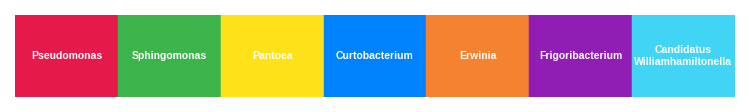

In [8]:
# Define genus palette
palette_genus={'Pseudomonas': '#E6194B',
 'Sphingomonas': '#3CB44B',
 'Pantoea': '#FFE119',
 'Curtobacterium': '#0082FC',
 'Erwinia': '#F58231',
 'Frigoribacterium': '#911EB4',
 'Candidatus Williamhamiltonella': '#42D4F4'}
# Show color palette
plot_palette(palette_genus)

### Lifestyle Palette


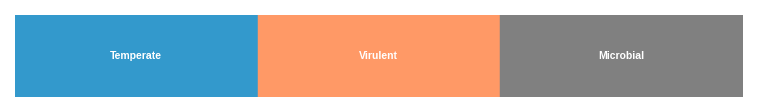

In [9]:
palette_lifestyle = {
    'Temperate': "#3399CC",
    'Virulent': "#FF9966",
    'Microbial': "gray"
}
plot_palette(palette_lifestyle)

### Quality Palette


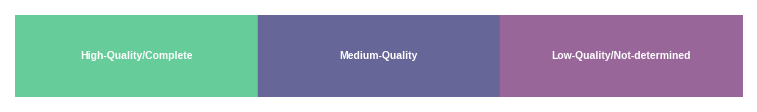

In [10]:
palette_quality = {
    'High-Quality/Complete': "#66CC99",
    'Medium-Quality': "#666699",
    'Low-Quality/Not-determined': "#996699",
}

plot_palette(palette_quality)

## Metadata Assembly


In [11]:
# diamond_df=pd.read_csv("/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/07_ANNOTATION/filtered_95-85_positive_viral_contigs_parsed_diamond_first.txt", sep="\t", header=None)
# diamond_df=diamond_df[[0, 1, 2, 3, 4,5,16]]
# APSE_distance=diamond_df[diamond_df[0].str.contains("APSE_wheat")]
# APSE_distance[3].hist(bins=100, color='skyblue', edgecolor='black')
# APSE_distance_filtered=APSE_distance[APSE_distance[3]>95]
# APSE_distance_grouped=APSE_distance_filtered.groupby([4,5]).count().reset_index()
# APSE_distance_grouped
# APSE_vOTUs=list(APSE_distance_grouped[5])
# APSE_vOTUs
# # for item in APSE_vOTUs:
# #     print(item)

APSE_vOTUs=['APSE_wheat',
 'vF2A_T_10_NODE_4_length_18178_cov_131.458920',
 'vF2B_80_NODE_131_length_16057_cov_327.714411',
 'vFL_amp_40_NODE_110_length_11903_cov_223.391627',
 'vN2_10_NODE_2_length_39732_cov_172.456511',
 'vO3A_70_NODE_154_length_13639_cov_186.811985',
 'vS3C_T_NODE_78_length_14889_cov_89.463665']

In [12]:
# Load input data
# Load Sourmash results
sourmash_microbial = pd.read_csv("/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/07_ANNOTATION/sourmash_combined_microbial_derreplicated_tot.classifications.csv")
sourmash_microbial["length"] = sourmash_microbial["query_name"].str.split("_length_").str[1].str.split("_cov_").str[0].astype(int)
sourmash_microbial = sourmash_microbial[sourmash_microbial["length"] > 5000]  # Keep contigs longer than 5 kb

# Load SpacePharer MINCED results
headers = ["spacer_acc", "phage_acc", "p_bh", "spacer_start", "spacer_end", "phage_start", "phage_end", "putative_5_3'_PAM", "npi"]
spacepharer_df_minced = pd.read_csv("/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/07_ANNOTATION/spacepharer_minced_95-85_positive_viral_contigs.tot.tsv", sep="\t", names=headers)

# Clean spacer accessions
spacepharer_df_minced['spacer_acc'] = spacepharer_df_minced['spacer_acc'].str.replace('#', '').str.replace('>', '')

# Extract spacer and CRISPR fields
spacepharer_df_minced[['acc_temp', 'CRISPR']] = spacepharer_df_minced['spacer_acc'].str.split("_CRISPR_", expand=True)

# Drop unwanted spacer accessions
spacepharer_df_minced = spacepharer_df_minced[spacepharer_df_minced['acc_temp'] != "minced_predicted_spacers_spacers.fa"]

# Compute hit length
spacepharer_df_minced["hit_length"] = np.abs(spacepharer_df_minced["phage_end"] - spacepharer_df_minced["phage_start"])

# Merge microbial lineage data
spacepharer_df_minced = spacepharer_df_minced.merge(sourmash_microbial[["query_name", "lineage"]], left_on="acc_temp", right_on="query_name", how="inner")

# Sort merged hits
spacepharer_df_minced = spacepharer_df_minced.sort_values(by="hit_length", ascending=False)
spacepharer_df_minced = spacepharer_df_minced.groupby("phage_acc").first().reset_index().set_index("phage_acc")
spacepharer_df_minced[desired_ranks + ["strain"]] = spacepharer_df_minced["lineage"].str.split(";", expand=True)

# Load metadata tables
# Load DNA metadata
DNA_metadata_df = pd.read_csv(DNA_metadata_file, sep="\t", index_col=1)

# Load host prevalence categories
host_prevalence = pd.read_csv(
    "/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/FIGURES_AND_TABLES/prevalence_bacterial_genus.csv"
)

# Load sample metadata
metadata_samples = pd.read_csv(work_dir + "/metadata_samples.txt", sep="\t", index_col=0)

# Load vOTU representatives
vOTU_representatives = pd.read_csv(filtered_list, names=["vOTU"])

# Load summary table
summary_df = pd.read_csv(merged_summary, index_col=0)

# Load widespread prophage labels
widespread_names_df = pd.read_csv(
    "/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/peter_phage_names.csv",
    sep="\t"
).rename(columns={"prophage_name": "widespread_name"})
widespread_names_df["widespread_name"] = widespread_names_df["widespread_name"].str.split("_").str[0]
widespread_names_df["widespread_name"] = np.where(
    widespread_names_df["prophage"].str.startswith("E", na=False),
    "Erwinia virus " + widespread_names_df["widespread_name"],
    np.where(
        widespread_names_df["prophage"].str.startswith("P", na=False),
        "Pseudomonas virus " + widespread_names_df["widespread_name"],
        widespread_names_df["widespread_name"]
    )
)

# Load TaxMyPhage annotations
taxmyphage_df = pd.read_csv(
    "/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/07_ANNOTATION/taxmyphage_filtered_95-85_positive_viral_contigs.tot/Summary_taxonomy.tsv",
    sep="	"
).set_index("Genome")
taxmyphage_df = taxmyphage_df.rename(columns={
    "Realm": "taxmyphage_realm",
    "Kingdom": "taxmyphage_kingdom",
    "Phylum": "taxmyphage_phylum",
    "Class": "taxmyphage_class",
    "Order": "taxmyphage_order",
    "Family": "taxmyphage_family",
    "Subfamily": "taxmyphage_subfamily",
    "Genus": "taxmyphage_genus",
    "Species": "taxmyphage_species"
})[[
    "taxmyphage_realm",
    "taxmyphage_kingdom",
    "taxmyphage_phylum",
    "taxmyphage_class",
    "taxmyphage_order",
    "taxmyphage_family",
    "taxmyphage_subfamily",
    "taxmyphage_genus",
    "taxmyphage_species"
]]

# Load filtered BLAST hits
blast_df = pd.read_csv(blast_results, sep="\t", 
                       names=["qseqid", "sseqid", "salltitles", "qstart", "qend", "qlen", "slen", 
                              "qcovs", "evalue", "length", "pident"]
                      ).sort_values(by="qcovs").groupby("qseqid").last().reset_index()

# Load and filter iPHoP hosts
iphop_df = pd.read_csv(iphop_results)
iphop_df["Host genus"] = iphop_df["Host genus"].str.replace("Hamiltonella", "Candidatus Williamhamiltonella")
iphop_df["Host genus"] = iphop_df["Host genus"].str.replace("Acidoferrum", "Candidatus Acidiferrum")
# iphop_df[iphop_df["Virus"]=="vF1A_T_80_NODE_8_length_12745_cov_6.965879"]["Host genus"].to_list()
results = iphop_df["Host genus"].apply(get_full_lineage)
iphop_df[desired_ranks] = results.apply(lambda x: x[0]).to_list()
iphop_df["found_taxid"] = results.apply(lambda x: x[1])

iphop_df = iphop_df[iphop_df["domain"] == "Bacteria"]

hamiltonella_values = ["N/A", "Pseudomonadota", "Gammaproteobacteria", "Enterobacterales", "Enterobacteriaceae", "Candidatus Williamhamiltonella"]
iphop_df.loc[iphop_df["genus"] == "Arsenophonus", desired_ranks] = hamiltonella_values

genera_remove=["", "1-19", "Mixta", "ALPHA2B", "AWTP1-35", "VTOM01", "BACL11", "BK-30", "BOG-930", "CAIUGU01", "CAHJXG01", "CAJFPI01",
						"COE1", "CSK15Z-1", "CAKAKO01", "GCA-003244245", "PD-1", "NBRC-107566", "PKWO01", "QIAS01", "SoCistrobi", "WNDY01"]
iphop_df=iphop_df[~iphop_df["genus"].isin(genera_remove)]

iphop_df = iphop_df.groupby('Virus').apply(select_iphop).reset_index(drop=True).reset_index()

# iphop_grouped=iphop_df.groupby("genus").first()

# Load PhaGCN results
PhaGCN_df = pd.read_csv(PhaGCN_results).rename(columns={"prediction": "PhaGCN_family"})

# Load nucleotide composition
nucleotide_content_df = pd.read_csv(nucleotide_content, sep="\t", index_col=0, 
                                    names=["seq_length", "#A", "#C", "#G", "#T", "#2", "#3", "#4", 
                                           "#CpG", "#tv", "#ts", "#CpG-ts"])

# Load BacPhlIP predictions
bacphliph_df = pd.read_csv("/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/07_ANNOTATION/filtered_95-85_positive_viral_contigs.tot_bacphlip.csv", sep="\t", index_col=0)
bacphliph_df['BACPLHIP_lifestyle'] = bacphliph_df['Virulent'].apply(lambda x: 'Virulent' if x >= 0.5 else 'Temperate')

# Load count and RPKM tables
filtered_counts_norm_df = pd.read_csv(filtered_counts_norm_file, index_col=0)
filtered_RPKM_norm_df = pd.read_csv(filtered_RPKM_norm_file, index_col=0)

# filtered_RPKM_norm_sub_df = pd.read_csv(filtered_RPKM_norm_sub_file, index_col=0)
filtered_75_RPKM_norm_df = pd.read_csv(filtered_75_RPKM_norm_file, index_col=0)

filtered_RPMK_norm_full_df = pd.read_csv(filtered_RPKM_norm_file_full, index_col=0)

# Build metadata table
# Compute relative abundance
relative_norm_df = filtered_RPKM_norm_df * 100 / filtered_RPKM_norm_df.sum()
relative_norm_df_full = filtered_RPMK_norm_full_df * 100 / filtered_RPMK_norm_full_df.sum()

relative_norm_75_df = filtered_75_RPKM_norm_df * 100 / filtered_75_RPKM_norm_df.sum()

# Compute sample richness
richness_per_sample_df = relative_norm_df.apply(lambda col: (col > 0).sum()).to_frame()
richness_per_sample_df.columns = ["richness"]

mean_rpkm = filtered_RPKM_norm_df[SAMPLES].T.mean().to_frame()
mean_rpkm.columns = ["mean_rpkm"]

max_rpkm = filtered_RPKM_norm_df[SAMPLES].T.max().to_frame()
max_rpkm.columns = ["max_rpkm"]

mean_rpkm_full = filtered_RPMK_norm_full_df[PHYLLOSPHERE_ALL].T.mean().to_frame()
mean_rpkm_full.columns = ["mean_rpkm_full"]

max_rpkm_full = filtered_RPMK_norm_full_df[PHYLLOSPHERE_ALL].T.max().to_frame()
max_rpkm_full.columns = ["max_rpkm_full"]

# Compute mean and max abundance
mean_relative_full = relative_norm_df_full[SAMPLES].T.mean().to_frame()
mean_relative_full.columns = ["mean_relative_full"]

max_relative_full = relative_norm_df_full[SAMPLES].T.max().to_frame()
max_relative_full.columns = ["max_relative_full"]

mean_relative = relative_norm_df[SAMPLES].T.mean().to_frame()
mean_relative.columns = ["mean_relative"]

max_relative = relative_norm_df[SAMPLES].T.max().to_frame()
max_relative.columns = ["max_relative"]

# Merge metadata columns
metadata_df = vOTU_representatives.merge(summary_df, how="left", left_on="vOTU", right_on="vOTU_name") \
    .merge(bacphliph_df, left_on="vOTU", right_index=True, how="left")\
    .merge(max_rpkm, how="left", left_on="vOTU", right_index=True) \
    .merge(nucleotide_content_df, how="left", left_on="vOTU", right_index=True) \
    .merge(relative_norm_df, left_on="vOTU", right_index=True, how="left")\
    .merge(PhaGCN_df, how="left", left_on="vOTU_name", right_on="contig_name") \
    .merge(mean_rpkm, how="left", left_on="vOTU", right_index=True) \
    .merge(mean_rpkm_full, how="left", left_on="vOTU", right_index=True) \
    .merge(max_rpkm_full, how="left", left_on="vOTU", right_index=True) \
    .merge(max_relative, how="left", left_on="vOTU", right_index=True) \
    .merge(mean_relative, how="left", left_on="vOTU", right_index=True) \
    .merge(mean_relative_full, how="left", left_on="vOTU", right_index=True) \
    .merge(max_relative_full, how="left", left_on="vOTU", right_index=True) \
    .merge(blast_df, how="left", left_on="vOTU", right_on="qseqid") \
    .merge(iphop_df, how="left", left_on="vOTU", right_on="Virus") \
    .merge(taxmyphage_df, how="left", left_on="vOTU", right_index=True)

# Add GC content
metadata_df["GC"] = (metadata_df["#G"] + metadata_df["#C"]) / metadata_df["seq_length"]

# Drop unused columns
metadata_df = metadata_df.drop(
    ["vOTU_name", "contig_name", "VirSorter2_seqname", "geNomad_seq_name", 
     "geNomad_viral_name", "geNomad_viral_conservative_name"], 
    axis=1
)
metadata_df.set_index('vOTU', inplace=True)

# Add reusable naming columns
metadata_df["vOTU_widespread_key"] = np.where(
    metadata_df.index.to_series().str.contains("cluster", na=False),
    metadata_df.index.to_series().str.split("_cluster").str[0],
    metadata_df.index.to_series()
)
metadata_df = metadata_df.reset_index().merge(
    widespread_names_df[["prophage", "widespread_name"]],
    left_on="vOTU_widespread_key",
    right_on="prophage",
    how="left"
).set_index("vOTU")
metadata_df["vOTU_label_base"] = np.where(
    metadata_df["vOTU_widespread_key"].str.contains("pp", na=False) & metadata_df["widespread_name"].notna(),
    metadata_df["widespread_name"],
    metadata_df["vOTU_widespread_key"]
)

# Add MINCED spacers
# Update spacer metadata
metadata_df.loc[spacepharer_df_minced.index, desired_ranks] = spacepharer_df_minced[desired_ranks]

# Annotate isolates
# Map isolates to vOTUs
metadata_df.loc[metadata_df.index.str.contains("^P_"), desired_ranks] = [
    "N/A", "Pseudomonadota", "Gammaproteobacteria", "Pseudomonadales", 
    "Pseudomonadaceae", "Pseudomonas"
]
metadata_df.loc[metadata_df.index.str.contains("^E_"), desired_ranks] = [
    "N/A", "Pseudomonadota", "Gammaproteobacteria", "Enterobacterales", 
    "Erwiniaceae", "Erwinia"
]

# Add binary metadata flags
metadata_df['geNomad_provirus'] = metadata_df.index.str.contains('provirus').astype(bool)
metadata_df['microbial_fraction'] = metadata_df.index.str.startswith('b').astype(bool)
metadata_df['isolate'] = ~metadata_df.index.str.contains('NODE').astype(bool)

# Update APSE and lifestyle fields
metadata_df.loc[APSE_vOTUs, "BACPLHIP_lifestyle"] = "Temperate"
metadata_df.loc[APSE_vOTUs, desired_ranks] = hamiltonella_values

# Add presence-absence columns
metadata_df['DENMARK'] = filtered_RPKM_norm_df[DENMARK].gt(0).any(axis=1).map({True: 'TRUE'})
metadata_df['LEAF'] = filtered_RPKM_norm_df[LEAF].gt(0).any(axis=1).map({True: 'TRUE'})
metadata_df['DENMARK_LEAF'] = filtered_RPKM_norm_df[DENMARK_LEAF].gt(0).any(axis=1).map({True: 'TRUE'})
metadata_df['DENMARK_PHYLLOSPHERE'] = filtered_RPKM_norm_df[DENMARK_PHYLLOSPHERE].gt(0).any(axis=1).map({True: 'TRUE'})
metadata_df['USA_LEAF'] = filtered_RPKM_norm_df[USA].gt(0).any(axis=1).map({True: 'TRUE'})
metadata_df['INTERESTING'] = filtered_RPKM_norm_df[SAMPLES].gt(0).any(axis=1).map({True: 'TRUE'})
metadata_df['PHYLLOSPHERE'] = filtered_RPKM_norm_df[PHYLLOSPHERE].gt(0).any(axis=1).map({True: 'TRUE'})
metadata_df['COMPARISON'] = filtered_RPMK_norm_full_df[PHYLLOSPHERE_ALL].gt(0).any(axis=1).map({True: 'TRUE'})
metadata_df['all_vOTUs'] = filtered_RPMK_norm_full_df[SAMPLES].gt(0).any(axis=1).map({True: 'TRUE'})

metadata_df = metadata_df.applymap(lambda x: x.strip() if isinstance(x, str) else x)

sample_value_columns = sorted(
    set(filtered_RPKM_norm_df.columns)
    | set(filtered_RPMK_norm_full_df.columns)
    | set(filtered_75_RPKM_norm_df.columns)
    | set(filtered_counts_norm_df.columns)
)
sample_value_columns = [col for col in sample_value_columns if col in metadata_df.columns]
metadata_df[sample_value_columns] = metadata_df[sample_value_columns].fillna(0)

# Fill missing values and save metadata
metadata_df = metadata_df.fillna("N/A")

# Freeze vOTU numbering from full-panel mean RPKM
votu_rank_map = (
    metadata_df[["mean_rpkm_full"]]
    .assign(vOTU_name=lambda data: data.index)
    .sort_values(["mean_rpkm_full", "vOTU_name"], ascending=[False, True], kind="mergesort")
    .reset_index(drop=True)
)
votu_rank_map["vOTU_number"] = "vOTU_" + (votu_rank_map.index + 1).astype(str).str.zfill(4)
votu_rank_map = votu_rank_map.set_index("vOTU_name")["vOTU_number"]

metadata_df["vOTU_number"] = metadata_df.index.to_series().map(votu_rank_map)
metadata_df["vOTU_name"] = metadata_df.index
metadata_df["vOTU_name_final"] = np.where(
    metadata_df["vOTU_label_base"].str.contains("NODE", na=False),
    metadata_df["vOTU_number"],
    metadata_df["vOTU_label_base"]
)

# Build reusable phyllosphere tables
phyllosphere_metadata = metadata_df[(metadata_df["COMPARISON"] == "TRUE")].sort_values(
    "mean_relative_full", ascending=False
)
phyllosphere_active_metadata = metadata_df[(metadata_df["INTERESTING"] == "TRUE")].sort_values(
    "mean_relative", ascending=False
)

# Keep backward-compatible alias
phyllosphere_active_metadata = phyllosphere_active_metadata

# Build comparison display names
comparison_vOTU_names = phyllosphere_metadata[[
    "vOTU_number", "vOTU_name", "vOTU_name_final", "checkV_contig_length", "checkv_quality", "genus", "vOTU_label_base"
]].reset_index().rename(columns={
    "vOTU": "vOTU_representative",
    "vOTU_label_base": "vOTU_widespread"
})

comparison_metadata_names = phyllosphere_metadata.copy()

# Build active display names
vOTU_names = phyllosphere_active_metadata[[
    "vOTU_number", "vOTU_name", "vOTU_name_final", "checkV_contig_length", "checkv_quality", "genus", "vOTU_label_base"
]].reset_index().rename(columns={
    "vOTU": "vOTU_representative",
    "vOTU_label_base": "vOTU_widespread"
})

phyllosphere_active_metadata_names = phyllosphere_active_metadata.copy()


In [13]:

# Export Table S3
s3_metadata_export = metadata_df[metadata_df["COMPARISON"] == "TRUE"].reset_index().copy()
s3_metadata_export["Prophage_isolate_name"] = s3_metadata_export["widespread_name"].where(
    s3_metadata_export["widespread_name"].ne("N/A"), ""
)
s3_metadata_export["contig_assembly_name"] = s3_metadata_export["vOTU_name"]
s3_metadata_export = s3_metadata_export.drop(columns=["vOTU_name"])

s3_front_columns = ["vOTU_number", "Prophage_isolate_name", "contig_assembly_name"]
s3_helper_columns = [
    "vOTU",
    "vOTU_label_base",
    "vOTU_widespread_key",
    "prophage",
    "widespread_name",
    "vOTU_name_final",
]
s3_remaining_columns = [
    col for col in s3_metadata_export.columns
    if col not in s3_front_columns + s3_helper_columns
]
s3_metadata_export = s3_metadata_export[s3_front_columns + s3_remaining_columns]
s3_metadata_export = s3_metadata_export.drop(
    columns=["qseqid", "APSE_wheat", "count_Y", "all_vOTUs", "index", "Virus"],
    errors="ignore"
)

s3_rename_map = {
    "checkv_quality": "CheckV_quality",
    "checkV_miuvig_quality": "CheckV_MIUVIG_quality",
    "Virulent": "BACPHLIP_virulent_score",
    "Temperate": "BACPHLIP_temperate_score",
    "BACPLHIP_lifestyle": "BACPHLIP_lifestyle",
    "idx": "PhaGCN_idx",
    "score": "PhaGCN_score",
    "qseqid": "BLAST_qseqid",
    "sseqid": "BLAST_sseqid",
    "salltitles": "BLAST_salltitles",
    "qstart": "BLAST_qstart",
    "qend": "BLAST_qend",
    "qlen": "BLAST_qlen",
    "slen": "BLAST_slen",
    "qcovs": "BLAST_qcovs",
    "evalue": "BLAST_evalue",
    "length": "BLAST_length",
    "pident": "BLAST_pident",
    "Host genus": "iPHoP_host_genus",
    "AAI to closest RaFAH reference": "iPHoP_AAI_to_closest_RaFAH_reference",
    "Confidence score": "iPHoP_confidence_score",
    "List of methods": "iPHoP_list_of_methods",
    "found_taxid": "iPHoP_found_taxid",
    "domain": "host_domain",
    "phylum": "host_phylum",
    "class": "host_class",
    "order": "host_order",
    "family": "host_family",
    "genus": "host_genus",
    "strain": "host_strain",
    "mean_rpkm": "mean_RPKM_active",
    "max_rpkm": "max_RPKM_active",
    "mean_rpkm_full": "mean_RPKM_full",
    "max_rpkm_full": "max_RPKM_full",
    "mean_relative": "mean_relative_active",
    "max_relative": "max_relative_active",
    "GC": "GC_fraction",
}
s3_metadata_export = s3_metadata_export.rename(columns=s3_rename_map)
s3_metadata_export = s3_metadata_export.rename(columns={"vOTU_number": "vOTU_name"})
s3_metadata_export = s3_metadata_export.rename(
    columns=lambda col: col.replace("checkV_", "CheckV_") if col.startswith("checkV_") else col
)
s3_metadata_export = s3_metadata_export.rename(
    columns=lambda col: col.replace("taxmyphage_", "taxMyPhage_") if col.startswith("taxmyphage_") else col
)
seqtk_rename_map = {
    "seq_length": "seqtk_seq_length",
    "#A": "seqtk_n_A",
    "#C": "seqtk_n_C",
    "#G": "seqtk_n_G",
    "#T": "seqtk_n_T",
    "#2": "seqtk_n_2",
    "#3": "seqtk_n_3",
    "#4": "seqtk_n_4",
    "#CpG": "seqtk_n_CpG",
    "#tv": "seqtk_n_tv",
    "#ts": "seqtk_n_ts",
    "#CpG-ts": "seqtk_n_CpG_ts",
}
s3_metadata_export = s3_metadata_export.rename(columns=seqtk_rename_map)
sample_abundance_rename_map = {
    col: f"relative_abundance_active_{col}"
    for col in SAMPLES
    if col in s3_metadata_export.columns
}
s3_metadata_export = s3_metadata_export.rename(columns=sample_abundance_rename_map)
raw_sample_columns = [
    col for col in sample_value_columns
    if col in s3_metadata_export.columns
]
s3_metadata_export = s3_metadata_export.drop(columns=raw_sample_columns, errors="ignore")
flag_columns = [
    col for col in [
        "geNomad_provirus",
        "microbial_fraction",
        "isolate",
        "DENMARK",
        "LEAF",
        "DENMARK_LEAF",
        "DENMARK_PHYLLOSPHERE",
        "USA_LEAF",
        "INTERESTING",
        "PHYLLOSPHERE",
        "COMPARISON",
    ]
    if col in s3_metadata_export.columns
]
sample_abundance_columns = [
    col for col in s3_metadata_export.columns
    if col.startswith("relative_abundance_active_")
]
summary_abundance_columns = [
    col for col in [
        "mean_relative_active",
        "max_relative_active",
        "mean_relative_full",
        "max_relative_full",
        "mean_RPKM_active",
        "max_RPKM_active",
        "mean_RPKM_full",
        "max_RPKM_full",
    ]
    if col in s3_metadata_export.columns
]
preferred_non_abundance_columns = [
    col for col in [
        "vOTU_name",
        "Prophage_isolate_name",
        "contig_assembly_name",
        "CheckV_contig_length",
        "CheckV_quality",
        "VirSorter2_positive",
        "VIBRANT_positive",
        "geNomad_viral",
        "geNomad_viral_conservative",
        "VirSorter2_dsDNAphage",
        "VirSorter2_NCLDV",
        "VirSorter2_RNA",
        "VirSorter2_ssDNA",
        "VirSorter2_lavidaviridae",
        "VirSorter2_max_score",
        "VirSorter2_max_score_group",
        "VirSorter2_length",
        "VirSorter2_hallmark",
        "VirSorter2_viral",
        "VirSorter2_cellular",
        "VIBRANT_circular",
        "VIBRANT_lifecycle",
        "VIBRANT_quality",
        "VIBRANT_total_genes",
        "VIBRANT_all_KEGG",
        "VIBRANT_KEGG_v-score",
        "VIBRANT_all_Pfam",
        "VIBRANT_Pfam_v-score",
        "VIBRANT_all_VOG",
        "VIBRANT_VOG_v-score",
        "VIBRANT_KEGG_int-rep",
        "VIBRANT_KEGG_zero",
        "VIBRANT_Pfam_int-rep",
        "VIBRANT_Pfam_zero",
        "VIBRANT_VOG_redoxin",
        "VIBRANT_VOG_rec-tran",
        "VIBRANT_VOG_int",
        "VIBRANT_VOG_RnR",
        "VIBRANT_VOG_DNA",
        "VIBRANT_KEGG_restriction_check",
        "VIBRANT_KEGG_toxin_check",
        "VIBRANT_VOG_special",
        "VIBRANT_annotation_check",
        "VIBRANT_p_v_check",
        "VIBRANT_p_k_check",
        "VIBRANT_k_v_check",
        "VIBRANT_k_check",
        "VIBRANT_p_check",
        "VIBRANT_v_check",
        "VIBRANT_h_check",
        "geNomad_length",
        "geNomad_topology",
        "geNomad_coordinates",
        "geNomad_n_genes",
        "geNomad_genetic_code",
        "geNomad_virus_score",
        "geNomad_fdr",
        "geNomad_n_hallmarks",
        "geNomad_marker_enrichment",
        "geNomad_taxonomy",
        "BACPHLIP_virulent_score",
        "BACPHLIP_temperate_score",
        "BACPHLIP_lifestyle",
        "iPHoP_host_genus",
        "iPHoP_AAI_to_closest_RaFAH_reference",
        "iPHoP_confidence_score",
        "iPHoP_list_of_methods",
        "iPHoP_found_taxid",
        "host_domain",
        "host_phylum",
        "host_class",
        "host_order",
        "host_family",
        "host_genus",
        "host_strain",
    ]
    if col in s3_metadata_export.columns
]
non_abundance_columns = [
    col for col in s3_metadata_export.columns
    if col not in sample_abundance_columns
    and col not in summary_abundance_columns
    and col not in flag_columns
]
remaining_non_abundance_columns = [
    col for col in non_abundance_columns if col not in preferred_non_abundance_columns
]
s3_metadata_export = s3_metadata_export[
    preferred_non_abundance_columns
    + remaining_non_abundance_columns
    + sample_abundance_columns
    + summary_abundance_columns
    + flag_columns
]
s3_metadata_export = s3_metadata_export.sort_values("vOTU_name")

s3_metadata_export = s3_metadata_export.replace("N/A", "")
s3_metadata_export.to_csv("/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/FIGURES_AND_TABLES/STable6_vOTU_metadata.csv", index=False)
s3_metadata_export


,vOTU_name,Prophage_isolate_name,contig_assembly_name,CheckV_contig_length,CheckV_quality,VirSorter2_positive,VIBRANT_positive,geNomad_viral,geNomad_viral_conservative,VirSorter2_dsDNAphage,...,microbial_fraction,isolate,DENMARK,LEAF,DENMARK_LEAF,DENMARK_PHYLLOSPHERE,USA_LEAF,INTERESTING,PHYLLOSPHERE,COMPARISON
7901,vOTU_0001,,APSE_wheat,41352,High-quality,Y,Y,Y,Y,0.987,...,False,True,TRUE,TRUE,TRUE,TRUE,TRUE,TRUE,TRUE,TRUE
7914,vOTU_0002,Erwinia virus Trolltunga,E_aphidicola_Z9_3_pp3_cluster_15,41269,High-quality,Y,Y,Y,Y,1.0,...,False,True,TRUE,TRUE,TRUE,TRUE,,TRUE,TRUE,TRUE
4705,vOTU_0003,,vN2_10_NODE_2_length_39732_cov_172.456511,39732,Complete,Y,Y,Y,Y,1.0,...,False,False,TRUE,TRUE,TRUE,TRUE,TRUE,TRUE,TRUE,TRUE
7871,vOTU_0004,,vSWd_T_20_NODE_1_length_42536_cov_22.322332,42536,High-quality,Y,Y,Y,Y,1.0,...,False,False,TRUE,TRUE,TRUE,TRUE,TRUE,TRUE,TRUE,TRUE
3205,vOTU_0005,,vS3C_T_NODE_78_length_14889_cov_89.463665,14889,Low-quality,Y,Y,Y,Y,0.76,...,False,False,TRUE,TRUE,TRUE,TRUE,TRUE,TRUE,TRUE,TRUE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7943,vOTU_7954,,bOL_T_NODE_10_length_69476_cov_48.898575_provi...,44073,High-quality,Y,Y,Y,Y,1.0,...,True,False,,,,,,,,TRUE
5201,vOTU_7955,,vO1C_60_NODE_776_length_19309_cov_114.585541,19309,Low-quality,Y,Y,Y,Y,1.0,...,False,False,,,,,,,,TRUE
5715,vOTU_7956,,vO2A_50_NODE_80_length_22873_cov_64.869270_pro...,19248,Medium-quality,Y,Y,Y,Y,1.0,...,False,False,,,,,,,,TRUE
3269,vOTU_7957,,vBRB_50_NODE_282_length_13799_cov_83.478609,13799,High-quality,Y,Y,Y,Y,1.0,...,False,False,,,,,,,,TRUE


In [14]:
host_prevalence = pd.read_csv("/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/FIGURES_AND_TABLES/prevalence_bacterial_" + "genus" + ".csv")
host_prevalence

,genus,0.0,1.0,5.0,10.0,25.0,50.0,75.0,100.0,mean,std,category,superkingdom,phylum,class,order,family
0,Achromobacter,2.857143,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.001183,0.007001,unique,Bacteria,Pseudomonadota,Betaproteobacteria,Burkholderiales,Alcaligenaceae
1,Acidovorax,2.857143,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000179,0.001057,unique,Bacteria,Pseudomonadota,Betaproteobacteria,Burkholderiales,Comamonadaceae
2,Acinetobacter,5.714286,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.019806,0.115676,unique,Bacteria,Pseudomonadota,Gammaproteobacteria,Moraxellales,Moraxellaceae
3,Aeromicrobium,51.428571,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.007604,0.010555,core,Bacteria,Actinomycetota,Actinomycetes,Propionibacteriales,Nocardioidaceae
4,Agreia,57.142857,2.857143,0.0,0.000000,0.000000,0.0,0.0,0.0,0.190340,0.300508,core,Bacteria,Actinomycetota,Actinomycetes,Micrococcales,Microbacteriaceae
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,Winslowiella,37.142857,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.059760,0.136668,common,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Erwiniaceae
146,Wolbachia,28.571429,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.018592,0.037659,common,Bacteria,Pseudomonadota,Alphaproteobacteria,Rickettsiales,Anaplasmataceae
147,Xanthomonas,31.428571,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.006805,0.018398,common,Bacteria,Pseudomonadota,Gammaproteobacteria,Lysobacterales,Lysobacteraceae
148,Xylophilus,20.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.001565,0.003282,common,Bacteria,Pseudomonadota,Betaproteobacteria,Burkholderiales,Comamonadaceae


## Figure 1. Characterization of Viral Diversity and Genomic Features


### 1a. Expansion of the vOTU Catalogue


7958
7958


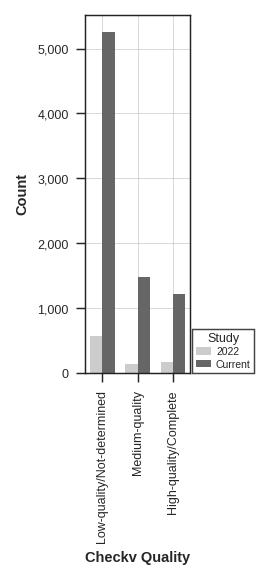

mean length vOTUs 24751.4070


,count_Y,checkV_contig_length,VirSorter2_positive,VIBRANT_positive,geNomad_viral,geNomad_viral_conservative,VIBRANT_circular,VIBRANT_lifecycle,VIBRANT_quality,VIBRANT_total_genes,...,DENMARK_LEAF,DENMARK_PHYLLOSPHERE,USA_LEAF,INTERESTING,PHYLLOSPHERE,COMPARISON,all_vOTUs,vOTU_number,vOTU_name,vOTU_name_final
checkv_quality,,,,,,,,,,,,,,,,,,,,,
Complete,374,374,374,374,374,374,374,374,374,374,...,374,374,374,374,374,374,374,374,374,374
High-quality,837,837,837,837,837,837,837,837,837,837,...,837,837,837,837,837,837,837,837,837,837
Low-quality,5139,5139,5139,5139,5139,5139,5139,5139,5139,5139,...,5139,5139,5139,5139,5139,5139,5139,5139,5139,5139
Medium-quality,1487,1487,1487,1487,1487,1487,1487,1487,1487,1487,...,1487,1487,1487,1487,1487,1487,1487,1487,1487,1487
Not-determined,121,121,121,121,121,121,121,121,121,121,...,121,121,121,121,121,121,121,121,121,121


In [15]:
comparison_metadata = phyllosphere_metadata.copy()
comparison_metadata.replace("N/A", "").to_csv("/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/FIGURES_AND_TABLES/vOTU_metadata_phyllosphere.csv")
print(len(comparison_metadata))


df_quality_phyllovir=comparison_metadata['checkv_quality'].value_counts().to_frame().T[['Not-determined', 'Low-quality', 'Medium-quality', 'High-quality', 'Complete']].T.reset_index()

df_quality_phyllovir.columns=["checkv_quality", "count"]
print(df_quality_phyllovir["count"].sum())
data_roam = {'checkv_quality': ['Not-determined', 'Low-quality', 'Medium-quality', 'High-quality', 'Complete'],
    'count_roam': [17,548, 139,107, 65]}

df_quality_roam = pd.DataFrame(data_roam)
df_quality_roam.columns=["checkv_quality", "count"]

# Merge quality classes for PhylloVir
df_quality_phyllovir['checkv_quality'] = df_quality_phyllovir['checkv_quality'].replace({
    'Not-determined': 'Low-quality',
    'Complete': 'High-quality'
})

# Sum counts by merged class
df_quality_phyllovir_combined = df_quality_phyllovir.groupby('checkv_quality', as_index=False).sum()

# Merge quality classes for Roam
df_quality_roam['checkv_quality'] = df_quality_roam['checkv_quality'].replace({
    'Not-determined': 'Low-quality',
    'Complete': 'High-quality'
})

# Sum counts by merged class
df_quality_roam_combined = df_quality_roam.groupby('checkv_quality', as_index=False).sum()

# Set class order
category_order = ['Low-quality', 'Medium-quality', 'High-quality']

# Reindex to class order
df_quality_phyllovir_combined = df_quality_phyllovir_combined.set_index('checkv_quality').reindex(category_order).reset_index()
df_quality_roam_combined = df_quality_roam_combined.set_index('checkv_quality').reindex(category_order).reset_index()

# Set x labels
category_labels = ['Low-quality/Not-determined', 'Medium-quality', 'High-quality/Complete']

# Set class colors
category_colors = ["#CCCCCC", "#666666"]

# Create bar plot
fig, ax = plt.subplots(figsize=(155*points_to_inches, 275*points_to_inches))

# Set bar width
bar_width = 0.35

# Compute bar positions
index = range(len(df_quality_roam_combined))
index2 = [x + bar_width for x in index]  # Shift the second set of bars to the right

# Plot Roam bars
bar1 = plt.bar(index, df_quality_roam_combined['count'], bar_width, label='2022', color=category_colors[0], edgecolor='none')


# Plot PhylloVir bars
bar2 = plt.bar(index2, df_quality_phyllovir_combined['count'], bar_width, label='Current', color=category_colors[1], edgecolor='none')

# Set x-axis labels
plt.xticks([idx + bar_width / 2 for idx in index], category_labels, rotation=90)

# Set labels and legend
plt.xlabel('Checkv Quality')
plt.ylabel('Count')
format_count_axis(ax, axis="y")

# Add legend
legend = plt.legend(title="Study", title_fontsize=6, fontsize=5, loc='lower left', bbox_to_anchor=(1.02, 0), borderaxespad=0)

# Show plot
tight_layout_with_legend()
plt.savefig("/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/FIGURES_AND_TABLES/1a_results_quality_bars_combined.svg")
plt.show()

print("mean length vOTUs", fmt_num(comparison_metadata["checkV_contig_length"].mean()))

comparison_metadata.groupby("checkv_quality").count()


In [16]:
total_votus = len(metadata_df[metadata_df["COMPARISON"] == "TRUE"])
hq_complete_votus = len(metadata_df[(metadata_df["COMPARISON"] == "TRUE") & metadata_df["checkv_quality"].isin(["Complete", "High-quality"])])
avotus = len(phyllosphere_active_metadata)
print("total", total_votus)
print("hq_complete_votus", hq_complete_votus)
print("avotus", avotus)

print("Percentage vOTUs HQ/C : ", fmt_num(hq_complete_votus * 100 / total_votus,1))
print("Percentage avOTUs : ", fmt_num(avotus * 100 / total_votus,1))


total 7958
hq_complete_votus 1211
avotus 726
Percentage vOTUs HQ/C :  15.2
Percentage avOTUs :  9.1


In [17]:
phyllosphere_active_metadata_stats = phyllosphere_active_metadata.copy()
phyllosphere_comparison_metadata_stats = phyllosphere_metadata.copy()


def print_phyllosphere_summary(label, df, mean_relative_col, max_relative_col):
    print(f"\n=== {label} ===")
    print("Total mean relative abundance", fmt_num(df[mean_relative_col].sum()))

    length_df_all = df[[
        "checkV_contig_length", mean_relative_col, "GC", "VIBRANT_lifecycle",
        "checkv_quality", "BACPLHIP_lifestyle", "genus"
    ]].copy()
    print("Total vOTUs", len(length_df_all))
    print("Length all vOTUs")
    print("mean", fmt_num(length_df_all["checkV_contig_length"].mean()))
    print("min", fmt_num(length_df_all["checkV_contig_length"].min()))
    print("max", fmt_num(length_df_all["checkV_contig_length"].max()))
    print()

    print("Count lifestyle")
    print(df["BACPLHIP_lifestyle"].value_counts().to_frame())
    print()

    print("Count per checkv_quality")
    print(df["checkv_quality"].value_counts().to_frame())
    print()

    length_df_hq = df[
        df["checkv_quality"].isin(["Complete", "High-quality"])
    ][["checkV_contig_length", mean_relative_col, "GC", max_relative_col, "BACPLHIP_lifestyle"]].copy()

    print("Complete/high-quality", len(length_df_hq))
    print("Complete/high-quality Jumbophages (>200kbp)", len(length_df_hq[length_df_hq["checkV_contig_length"] > 200000]))
    print()

    length_df_hq["ponderate_length"] = length_df_hq["checkV_contig_length"] * length_df_hq[mean_relative_col]
    length_df_hq["ponderate_GC"] = length_df_hq["GC"] * length_df_hq[mean_relative_col]

    average_length_ponderated = length_df_hq["ponderate_length"].sum() / length_df_hq[mean_relative_col].sum()
    average_GC_ponderated = length_df_hq["ponderate_GC"].sum() / length_df_hq[mean_relative_col].sum()

    print("Length complete/high-quality")
    print("mean", fmt_num(length_df_hq["checkV_contig_length"].mean()))
    print("median", fmt_num(length_df_hq["checkV_contig_length"].median()))
    print("ponderate", fmt_num(average_length_ponderated))
    print("min", fmt_num(length_df_hq["checkV_contig_length"].min()))
    print("max", fmt_num(length_df_hq["checkV_contig_length"].max()))
    print()

    print("GC complete/high-quality")
    print("mean", fmt_num(length_df_hq["GC"].mean()))
    print("ponderate", fmt_num(average_GC_ponderated))
    print("min", fmt_num(length_df_hq["GC"].min()))
    print("max", fmt_num(length_df_hq["GC"].max()))
    print()

    print("Count lifestyle (complete/high-quality)")
    print(length_df_hq["BACPLHIP_lifestyle"].value_counts().to_frame())
    print()

    print("Percentage lifestyle (complete/high-quality)")
    print(length_df_hq["BACPLHIP_lifestyle"].value_counts().to_frame() / length_df_hq["BACPLHIP_lifestyle"].value_counts().sum())
    print("HQ/complete percentage", fmt_num(len(length_df_hq) * 100 / len(df)))

    return length_df_all, length_df_hq


comparison_average_length_df_all, comparison_average_length_df = print_phyllosphere_summary(
    "Comparison Phyllosphere Metadata",
    phyllosphere_comparison_metadata_stats,
    "mean_relative_full",
    "max_relative_full",
)

average_length_df_all, average_length_df = print_phyllosphere_summary(
    "Active Phyllosphere Metadata",
    phyllosphere_active_metadata_stats,
    "mean_relative",
    "max_relative",
)



=== Comparison Phyllosphere Metadata ===
Total mean relative abundance 100.0000
Total vOTUs 7958
Length all vOTUs
mean 24751.4070
min 4441.0000
max 354857.0000

Count lifestyle
                    count
BACPLHIP_lifestyle       
Virulent             5569
Temperate            2389

Count per checkv_quality
                count
checkv_quality       
Low-quality      5139
Medium-quality   1487
High-quality      837
Complete          374
Not-determined    121

Complete/high-quality 1211
Complete/high-quality Jumbophages (>200kbp) 13

Length complete/high-quality
mean 50464.3353
median 44477.0000
ponderate 57592.4672
min 4441.0000
max 354857.0000

GC complete/high-quality
mean 0.5766
ponderate 0.5111
min 0.2301
max 0.7193

Count lifestyle (complete/high-quality)
                    count
BACPLHIP_lifestyle       
Temperate             653
Virulent              558

Percentage lifestyle (complete/high-quality)
                       count
BACPLHIP_lifestyle          
Temperate           0.

In [18]:
print(round(100*317/726,1))
print(round(100*155/317,1))


43.7
48.9


### 1b. Genome Length and GC Content of High-Quality and Complete avOTUs


In [19]:
metadata_df_high_comparison_phyllosphere = phyllosphere_metadata[
    phyllosphere_metadata["checkv_quality"].isin(["Complete", "High-quality"])
].copy()
metadata_df_high_active_phyllosphere = phyllosphere_active_metadata[
    phyllosphere_active_metadata["checkv_quality"].isin(["Complete", "High-quality"])
].copy()

metadata_df_high_active_phyllosphere


,count_Y,checkV_contig_length,VirSorter2_positive,VIBRANT_positive,geNomad_viral,geNomad_viral_conservative,VIBRANT_circular,VIBRANT_lifecycle,VIBRANT_quality,VIBRANT_total_genes,...,DENMARK_LEAF,DENMARK_PHYLLOSPHERE,USA_LEAF,INTERESTING,PHYLLOSPHERE,COMPARISON,all_vOTUs,vOTU_number,vOTU_name,vOTU_name_final
vOTU,,,,,,,,,,,,,,,,,,,,,
E_aphidicola_Z9_3_pp3_cluster_15,3,41269,Y,Y,Y,Y,N/A,lysogenic,medium quality draft,50.0,...,TRUE,TRUE,N/A,TRUE,TRUE,TRUE,TRUE,vOTU_0002,E_aphidicola_Z9_3_pp3_cluster_15,Erwinia virus Trolltunga
APSE_wheat,3,41352,Y,Y,Y,Y,N/A,lysogenic,high quality draft,36.0,...,TRUE,TRUE,TRUE,TRUE,TRUE,TRUE,TRUE,vOTU_0001,APSE_wheat,APSE_wheat
vS1B_20_NODE_11_length_139468_cov_83.775100,3,139468,Y,Y,Y,Y,Y,lytic,high quality draft,259.0,...,TRUE,TRUE,N/A,TRUE,TRUE,TRUE,TRUE,vOTU_0006,vS1B_20_NODE_11_length_139468_cov_83.775100,vOTU_0006
vF2A_40_NODE_6_length_51705_cov_107.419361,3,51705,Y,Y,Y,Y,N/A,lytic,medium quality draft,77.0,...,TRUE,TRUE,N/A,TRUE,TRUE,TRUE,TRUE,vOTU_0011,vF2A_40_NODE_6_length_51705_cov_107.419361,vOTU_0011
vF2B_NODE_17_length_45478_cov_102.889417,3,45478,Y,Y,Y,Y,Y,lytic,high quality draft,74.0,...,TRUE,TRUE,N/A,TRUE,TRUE,TRUE,TRUE,vOTU_0007,vF2B_NODE_17_length_45478_cov_102.889417,vOTU_0007
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
vF3A_90_NODE_32_length_38552_cov_33.642102,3,38552,Y,Y,Y,Y,N/A,lytic,high quality draft,59.0,...,TRUE,TRUE,N/A,TRUE,TRUE,TRUE,TRUE,vOTU_4192,vF3A_90_NODE_32_length_38552_cov_33.642102,vOTU_4192
vF3A_NODE_31_length_39578_cov_64.458746,3,39578,Y,Y,Y,Y,Y,lysogenic,high quality draft,47.0,...,TRUE,TRUE,N/A,TRUE,TRUE,TRUE,TRUE,vOTU_2374,vF3A_NODE_31_length_39578_cov_64.458746,vOTU_2374
vF3A_NODE_17_length_44188_cov_29.107697,3,44188,Y,Y,Y,Y,Y,lysogenic,high quality draft,71.0,...,TRUE,TRUE,N/A,TRUE,TRUE,TRUE,TRUE,vOTU_4679,vF3A_NODE_17_length_44188_cov_29.107697,vOTU_4679


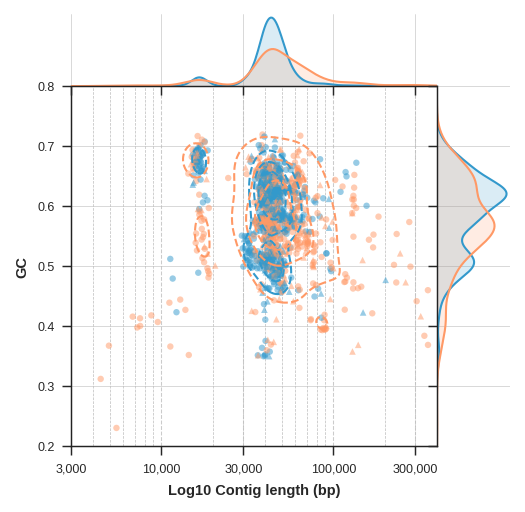

In [20]:
# Keep high-quality comparison vOTUs
metadata_df_high_comparison_phyllosphere = metadata_df_high_comparison_phyllosphere[
    metadata_df_high_comparison_phyllosphere["checkV_contig_length"] > 0
].copy()
metadata_df_high_comparison_phyllosphere["checkV_contig_length_log"] = np.log10(
    metadata_df_high_comparison_phyllosphere["checkV_contig_length"].astype(float)
)

metadata_df_high_comparison_phyllosphere["activity"] = np.where(
    metadata_df_high_comparison_phyllosphere.index.isin(metadata_df_high_active_phyllosphere.index),
    "Active",
    "Other"
)

ax = sns.JointGrid(
    data=metadata_df_high_comparison_phyllosphere,
    x="checkV_contig_length_log",
    y="GC",
    height=240 * points_to_inches,
    ratio=5,
    space=0,
)

ax.fig.set_size_inches(250 * points_to_inches, 243 * points_to_inches)

sns.scatterplot(
    data=metadata_df_high_comparison_phyllosphere[metadata_df_high_comparison_phyllosphere["activity"] == "Other"],
    x="checkV_contig_length_log",
    y="GC",
    hue="BACPLHIP_lifestyle",
    palette=palette_lifestyle,
    marker="o",
    s=9.5,
    alpha=0.5,
    edgecolor="none",
    legend=False,
    ax=ax.ax_joint,
)

sns.scatterplot(
    data=metadata_df_high_comparison_phyllosphere[metadata_df_high_comparison_phyllosphere["activity"] == "Active"],
    x="checkV_contig_length_log",
    y="GC",
    hue="BACPLHIP_lifestyle",
    palette=palette_lifestyle,
    marker="^",
    s=10,
    alpha=0.5,
    edgecolor="none",
    legend=False,
    ax=ax.ax_joint,
)

for lifestyle, color in palette_lifestyle.items():
    subset = metadata_df_high_comparison_phyllosphere[
        metadata_df_high_comparison_phyllosphere["BACPLHIP_lifestyle"] == lifestyle
    ].copy()

    if len(subset) >= 3:
        sns.kdeplot(
            data=subset,
            x="checkV_contig_length_log",
            y="GC",
            ax=ax.ax_joint,
            levels=4,
            fill=False,
            linewidths=1,
            linestyles="--",
            thresh=0.25,
            color=color,
            warn_singular=False,
        )

        sns.kdeplot(
            data=subset,
            x="checkV_contig_length_log",
            ax=ax.ax_marg_x,
            fill=True,
            alpha=0.18,
            linewidth=0,
            color=color,
            warn_singular=False,
        )
        sns.kdeplot(
            data=subset,
            x="checkV_contig_length_log",
            ax=ax.ax_marg_x,
            fill=False,
            linewidth=1,
            color=color,
            warn_singular=False,
        )
        sns.kdeplot(
            data=subset,
            y="GC",
            ax=ax.ax_marg_y,
            fill=True,
            alpha=0.18,
            linewidth=0,
            color=color,
            warn_singular=False,
        )
        sns.kdeplot(
            data=subset,
            y="GC",
            ax=ax.ax_marg_y,
            fill=False,
            linewidth=1,
            color=color,
            warn_singular=False,
        )

ax.ax_joint.set_xlabel("Log10 Contig length (bp)")
ax.ax_joint.set_ylabel("GC")
ax.ax_joint.set_xlim(np.log10(3000), np.log10(400000))
ax.ax_joint.set_ylim(0.2, 0.8)

ticks = [3000, 10000, 30000, 100000, 300000]
tick_pos = np.log10(ticks)
ax.ax_joint.set_xticks(tick_pos)
ax.ax_joint.set_xticklabels([f"{t:,}" for t in ticks])

ax.ax_joint.grid(True, which="major", axis="x", linestyle="--", linewidth=0.5)

xmin, xmax = np.log10(3000), np.log10(400000)

minor_ticks = []
for exp in range(int(np.floor(xmin)), int(np.ceil(xmax)) + 1):
    vals = np.array([2, 3, 4, 5, 6, 7, 8, 9]) * (10 ** exp)
    minor_ticks.extend(np.log10(vals))

minor_ticks = [t for t in minor_ticks if xmin < t < xmax]

for t in minor_ticks:
    ax.ax_joint.axvline(
        t,
        color="gray",
        linestyle="--",
        linewidth=0.35,
        alpha=0.5,
        zorder=0,
    )


ax.fig.savefig(
    "/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/FIGURES_AND_TABLES/1b_gc_vs_contig_length.svg",
    format="svg",
    bbox_inches="tight"
)
plt.show()

### 1c. Cumulative Relative Abundance of avOTUs


In [21]:
# Use precomputed abundance table
# Sort all vOTUs by mean abundance
df_sorted = average_length_df_all.sort_values(by="mean_relative", ascending=False)

# Compute cumulative abundance for all vOTUs
df_sorted['cumulative_relative'] = df_sorted['mean_relative'].cumsum()

# Add rank for all vOTUs
df_sorted['rank'] = range(1, len(df_sorted) + 1)

# Start all-vOTU curve at origin
df_sorted = pd.concat([pd.DataFrame({'rank': [0], 'cumulative_relative': [0]}), df_sorted])

# Sort each lifestyle by mean abundance
df_sorted_lifestyle1 = average_length_df_all[average_length_df_all['BACPLHIP_lifestyle'] == 'Virulent'].sort_values(by="mean_relative", ascending=False)
df_sorted_lifestyle2 = average_length_df_all[average_length_df_all['BACPLHIP_lifestyle'] == 'Temperate'].sort_values(by="mean_relative", ascending=False)

# Compute cumulative abundance by lifestyle
df_sorted_lifestyle1['cumulative_relative'] = df_sorted_lifestyle1['mean_relative'].cumsum()
df_sorted_lifestyle2['cumulative_relative'] = df_sorted_lifestyle2['mean_relative'].cumsum()

# Add rank within lifestyle
df_sorted_lifestyle1['rank'] = range(1, len(df_sorted_lifestyle1) + 1)
df_sorted_lifestyle2['rank'] = range(1, len(df_sorted_lifestyle2) + 1)

# Start lifestyle curves at origin
df_sorted_lifestyle1 = pd.concat([pd.DataFrame({'rank': [0], 'cumulative_relative': [0]}), df_sorted_lifestyle1])
df_sorted_lifestyle2 = pd.concat([pd.DataFrame({'rank': [0], 'cumulative_relative': [0]}), df_sorted_lifestyle2])

# Sort each checkV class by mean abundance
df_sorted_high_quality = average_length_df_all[(average_length_df_all['checkv_quality'] == 'High-quality') |  (average_length_df_all['checkv_quality'] == 'Complete')].sort_values(by="mean_relative", ascending=False)
df_sorted_medium_quality = average_length_df_all[average_length_df_all['checkv_quality'] == 'Medium-quality'].sort_values(by="mean_relative", ascending=False)
df_sorted_low_quality = average_length_df_all[(average_length_df_all['checkv_quality'] == 'Low-quality') |  (average_length_df_all['checkv_quality'] == 'Not-determined')].sort_values(by="mean_relative", ascending=False)

# Compute cumulative abundance by checkV class
df_sorted_high_quality['cumulative_relative'] = df_sorted_high_quality['mean_relative'].cumsum()
df_sorted_medium_quality['cumulative_relative'] = df_sorted_medium_quality['mean_relative'].cumsum()
df_sorted_low_quality['cumulative_relative'] = df_sorted_low_quality['mean_relative'].cumsum()

# Add rank within checkV class
df_sorted_high_quality['rank'] = range(1, len(df_sorted_high_quality) + 1)
df_sorted_medium_quality['rank'] = range(1, len(df_sorted_medium_quality) + 1)
df_sorted_low_quality['rank'] = range(1, len(df_sorted_low_quality) + 1)

# Start checkV curves at origin
df_sorted_high_quality = pd.concat([pd.DataFrame({'rank': [0], 'cumulative_relative': [0]}), df_sorted_high_quality])
df_sorted_medium_quality = pd.concat([pd.DataFrame({'rank': [0], 'cumulative_relative': [0]}), df_sorted_medium_quality])
df_sorted_low_quality = pd.concat([pd.DataFrame({'rank': [0], 'cumulative_relative': [0]}), df_sorted_low_quality])


In [22]:
df_sorted

,rank,cumulative_relative,checkV_contig_length,mean_relative,GC,VIBRANT_lifecycle,checkv_quality,BACPLHIP_lifestyle,genus
0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
E_aphidicola_Z9_3_pp3_cluster_15,1,9.918202,41269.0,9.918202,0.546173,lysogenic,High-quality,Temperate,Erwinia
APSE_wheat,2,17.42564,41352.0,7.507438,0.441212,lysogenic,High-quality,Temperate,Candidatus Williamhamiltonella
vS1B_20_NODE_11_length_139468_cov_83.775100,3,22.748354,139468.0,5.322714,0.368694,lytic,Complete,Virulent,Pantoea
vF2A_40_NODE_6_length_51705_cov_107.419361,4,25.901652,51705.0,3.153298,0.475273,lytic,High-quality,Virulent,N/A
...,...,...,...,...,...,...,...,...,...
vO2C_50_NODE_1075_length_12130_cov_22.014493,722,99.997573,12130.0,0.001413,0.58615,lytic,Low-quality,Virulent,N/A
vF2A_NODE_185_length_17243_cov_19.384571,723,99.998534,17243.0,0.000961,0.555124,lytic,Low-quality,Virulent,N/A
vF2A_NODE_374_length_10113_cov_7.938457,724,99.999237,10113.0,0.000702,0.438446,lysogenic,Low-quality,Temperate,Rosenbergiella
vO2B_90_NODE_353_length_23302_cov_5.848540,725,99.999826,23302.0,0.00059,0.68698,lysogenic,Low-quality,Temperate,Curtobacterium


In [23]:
df_sorted_high_quality_with_host=df_sorted_high_quality[df_sorted_high_quality["genus"]!="N/A"]
high_host_relative=df_sorted_high_quality_with_host[["genus", "mean_relative"]].groupby("genus").sum().sum()["mean_relative"]

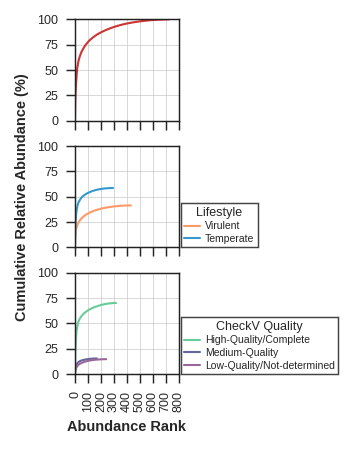

In [24]:
linewidth=1
# Create subplots
fig, axs = plt.subplots(3, 1, figsize=(205*points_to_inches, 212*points_to_inches), sharex=True)  # 3 rows, 1 column
xlim=len(phyllosphere_active_metadata)
xlim=800

# Plot combined data
axs[0].plot(df_sorted['rank'], df_sorted['cumulative_relative'], linestyle='-', lw=linewidth, label='Combined', color="#CC3333")
axs[0].set_ylim(0, 100)
axs[0].set_xlim(0, xlim)  # Tune axis range if needed
axs[0].set_xlabel('')
axs[0].set_ylabel('')
axs[0].grid(True)

# Plot each lifestyle
axs[1].plot(df_sorted_lifestyle1['rank'], df_sorted_lifestyle1['cumulative_relative'], linestyle='-', lw=linewidth, label='Virulent', color=palette_lifestyle["Virulent"])
axs[1].plot(df_sorted_lifestyle2['rank'], df_sorted_lifestyle2['cumulative_relative'], linestyle='-', lw=linewidth, label='Temperate', color=palette_lifestyle["Temperate"])
axs[1].set_ylim(0, 100)
axs[1].set_xlim(0, xlim)  # Tune axis range if needed
axs[1].set_xlabel('')
axs[1].set_ylabel('Cumulative Relative Abundance (%)')
axs[1].grid(True)
leg1=axs[1].legend(title="Lifestyle", title_fontsize=6, loc='lower left', bbox_to_anchor=(1.02, 0), borderaxespad=0)
leg1.set_in_layout(False)

axs[2].plot(df_sorted_high_quality['rank'], df_sorted_high_quality['cumulative_relative'], linestyle='-', lw=linewidth, label='High-Quality/Complete', color=palette_quality["High-Quality/Complete"])
axs[2].plot(df_sorted_medium_quality['rank'], df_sorted_medium_quality['cumulative_relative'], linestyle='-', lw=linewidth, label='Medium-Quality', color=palette_quality["Medium-Quality"])
axs[2].plot(df_sorted_low_quality['rank'], df_sorted_low_quality['cumulative_relative'], linestyle='-', lw=linewidth, label='Low-Quality/Not-determined', color=palette_quality["Low-Quality/Not-determined"])
axs[2].set_ylim(0, 100)
axs[2].set_xlim(0, xlim)  # Tune axis range if needed
axs[2].set_xlabel('Abundance Rank')
axs[2].set_ylabel('')
axs[2].grid(True)
leg2=axs[2].legend(title="CheckV Quality", title_fontsize=6, loc='lower left', bbox_to_anchor=(1.02, 0), borderaxespad=0)

axs[2].set_xticks(range(0, xlim+1, 100))  # 8001 ensures it covers the 8000 x-limit
axs[2].set_xticklabels(axs[2].get_xticklabels(), rotation=90)


tight_layout_with_legend(fig)

# Show plots
plt.savefig("/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/FIGURES_AND_TABLES/1c_cumulative_relative_abundance.svg", bbox_inches='tight')
plt.show()

# plt.subplot_tool(fig)

In [25]:
print(round(float(df_sorted_lifestyle1[-1:]["cumulative_relative"].values[0]),1), "%", "  Virulent")
print(round(float(df_sorted_lifestyle2[-1:]["cumulative_relative"].values[0]),1), "%", "  Temperate")
print()
print(round(float(df_sorted_high_quality[-1:]["cumulative_relative"].values[0]),1), " %", "  High-quality")
print(round(float(df_sorted_medium_quality[-1:]["cumulative_relative"].values[0]),1), "%", "  Medium-quality")
print(round(float(df_sorted_low_quality[-1:]["cumulative_relative"].values[0]),1), "%", "  Low-quality")
print()
print(round(float(high_host_relative),2), "%", "  High-quality w Host")

41.4 %   Virulent
58.6 %   Temperate

70.0  %   High-quality
15.4 %   Medium-quality
14.6 %   Low-quality

50.23 %   High-quality w Host


### 1d. Rarefaction of High-Quality and Complete avOTUs


Progress: 5%
Progress: 10%
Progress: 15%
Progress: 20%
Progress: 25%
Progress: 30%
Progress: 35%
Progress: 40%
Progress: 45%
Progress: 50%
Progress: 55%
Progress: 60%
Progress: 65%
Progress: 70%
Progress: 75%
Progress: 80%
Progress: 85%
Progress: 90%
Progress: 95%
Progress: 100%


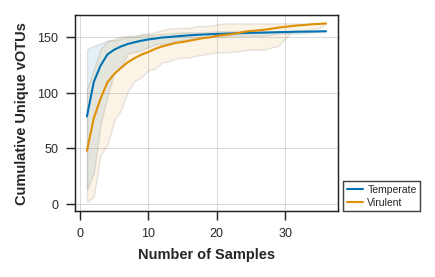

In [26]:
high_quality_active_df = phyllosphere_active_metadata[phyllosphere_active_metadata["checkV_miuvig_quality"] == "High-quality"]

N_ITER = 100  # increase for smoother CI

temp_matrix = []
vir_matrix = []

for i in range(1, N_ITER + 1):
    samples = SAMPLES.copy()
    random.shuffle(samples)

    seen_temp = set()
    seen_vir = set()

    temp_counts = []
    vir_counts = []

    for sample in samples:
        present = high_quality_active_df[high_quality_active_df[sample] > 0]

        for idx, row in present.iterrows():
            lifestyle = row["BACPLHIP_lifestyle"]

            if lifestyle == "Temperate":
                seen_temp.add(idx)
            elif lifestyle == "Virulent":
                seen_vir.add(idx)

        temp_counts.append(len(seen_temp))
        vir_counts.append(len(seen_vir))

    temp_matrix.append(temp_counts)
    vir_matrix.append(vir_counts)

    # Print progress every 5%
    if i % (N_ITER // 20) == 0:  # 20 steps = 5%
        print(f"Progress: {i / N_ITER:.0%}")

# Convert to arrays
temp_matrix = np.array(temp_matrix)
vir_matrix = np.array(vir_matrix)

# Compute mean
temp_mean = temp_matrix.mean(axis=0)
vir_mean = vir_matrix.mean(axis=0)


# Compute 95% CI
temp_low = np.percentile(temp_matrix, 2.5, axis=0)
temp_high = np.percentile(temp_matrix, 97.5, axis=0)

vir_low = np.percentile(vir_matrix, 2.5, axis=0)
vir_high = np.percentile(vir_matrix, 97.5, axis=0)

x = np.arange(1, len(SAMPLES) + 1)

# Plot results
plt.figure(figsize=(3.5, 1.8))
plt.plot(x, temp_mean, label="Temperate")
plt.fill_between(x, temp_low, temp_high, alpha=0.1)

plt.plot(x, vir_mean, label="Virulent")
plt.fill_between(x, vir_low, vir_high, alpha=0.1)

plt.xlabel("Number of Samples")
plt.ylabel("Cumulative Unique vOTUs")
plt.legend(loc='lower left', bbox_to_anchor=(1.02, 0), borderaxespad=0)
tight_layout_with_legend()
plt.savefig("/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/FIGURES_AND_TABLES/1d_cumulative_unique_votus_vs_number_of_samples.svg", bbox_inches='tight')
plt.show()


### 1e. Detected avOTUs per Lifestyle


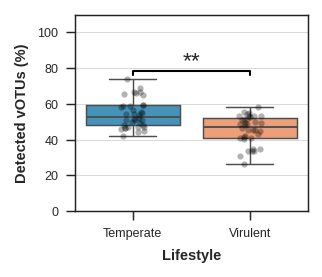

,Group,N,Mean,Median,Std,Shapiro_p,Normal?,Test,Statistic,p_value
0,Temperate,36.0,54.418680,52.752454,7.996680,NaN,NaN,NaN,NaN,NaN
1,Virulent,36.0,45.581320,47.247546,7.996680,NaN,NaN,NaN,NaN,NaN
2,Paired difference,36.0,8.837359,5.504909,15.993361,0.057646,True,NaN,NaN,NaN
3,Comparison,NaN,NaN,NaN,NaN,NaN,True,Paired t-test,3.315385,0.002139
4,Comparison,NaN,NaN,NaN,NaN,NaN,True,Wilcoxon signed-rank,149.000000,0.006548


In [27]:
# Compute lifestyle proportions
prop_data = []

for sample in SAMPLES:
    detected = phyllosphere_active_metadata[sample] > 0
    total_detected = detected.sum()

    temp_count = ((phyllosphere_active_metadata["BACPLHIP_lifestyle"] == "Temperate") & detected).sum()
    vir_count = ((phyllosphere_active_metadata["BACPLHIP_lifestyle"] == "Virulent") & detected).sum()

    temp_prop = (temp_count / total_detected * 100) if total_detected > 0 else np.nan
    vir_prop = (vir_count / total_detected * 100) if total_detected > 0 else np.nan

    prop_data.append({"Sample": sample, "Lifestyle": "Temperate", "Proportion": temp_prop})
    prop_data.append({"Sample": sample, "Lifestyle": "Virulent", "Proportion": vir_prop})

prop_df = pd.DataFrame(prop_data).dropna()

# Keep paired samples aligned
paired_prop = prop_df.pivot(index="Sample", columns="Lifestyle", values="Proportion").dropna()
temp_values = paired_prop["Temperate"]
vir_values = paired_prop["Virulent"]
diff_values = temp_values - vir_values

# Check normality of paired differences
_, p_diff_norm = shapiro(diff_values)
diff_normal = p_diff_norm > 0.05

# Run paired tests
try:
    t_stat, t_p = stats.ttest_rel(temp_values, vir_values, nan_policy="omit")
except ValueError:
    t_stat, t_p = np.nan, np.nan

try:
    w_stat, w_p = wilcoxon(temp_values, vir_values)
except ValueError:
    w_stat, w_p = 0.0, 1.0

results_df = pd.DataFrame([
    {"Group": "Comparison", "Normal?": diff_normal, "Test": "Paired t-test", "Statistic": t_stat, "p_value": t_p},
    {"Group": "Comparison", "Normal?": diff_normal, "Test": "Wilcoxon signed-rank", "Statistic": w_stat, "p_value": w_p},
])

plot_p_value = w_p

# Build summary table
group_summary = pd.DataFrame({
    "Group": ["Temperate", "Virulent", "Paired difference"],
    "N": [len(temp_values), len(vir_values), len(diff_values)],
    "Mean": [temp_values.mean(), vir_values.mean(), diff_values.mean()],
    "Median": [temp_values.median(), vir_values.median(), diff_values.median()],
    "Std": [temp_values.std(), vir_values.std(), diff_values.std()],
    "Shapiro_p": [np.nan, np.nan, p_diff_norm],
    "Normal?": [np.nan, np.nan, diff_normal],
})

summary_df_prop = pd.concat([group_summary, results_df], ignore_index=True)
summary_df_prop.to_csv("/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/FIGURES_AND_TABLES/STable9_lifestyle_proportion_stats_summary.csv", index=False)

# Plot results
plt.figure(figsize=(2.1, 1.8))
ax = sns.boxplot(
    x="Lifestyle", y="Proportion", data=prop_df,
    palette=[palette_lifestyle["Temperate"], palette_lifestyle["Virulent"]],
)

sns.stripplot(
    x="Lifestyle", y="Proportion", data=prop_df,
    color="black", size=3, jitter=True, alpha=0.3
)

ymax = prop_df["Proportion"].max()
bar_y = ymax * 1.03 if ymax > 0 else 0.01
bar_h = ymax * 0.03 if ymax > 0 else 0.01
add_significance_bar(ax, 0, 1, bar_y, bar_h, plot_p_value)

plt.ylabel("Detected vOTUs (%)")
plt.ylim(0, 110)
plt.tight_layout()

plt.savefig(
    "/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/FIGURES_AND_TABLES/1e_detected_votus_per_lifestyle.svg",
    bbox_inches="tight"
)

plt.show()
summary_df_prop


In [28]:
round(0.006548290931648803,4)

0.0065

### 1f. Relative Abundance per Lifestyle


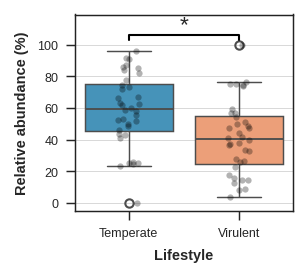

,Group,N,Mean,Median,Std,Shapiro_p,Normal?,Test,Statistic,p_value
0,Temperate,36.0,58.57715,59.474494,23.001146,NaN,NaN,NaN,NaN,NaN
1,Virulent,36.0,41.42285,40.525506,23.001146,NaN,NaN,NaN,NaN,NaN
2,Paired difference,36.0,17.15430,18.948989,46.002292,0.348193,True,NaN,NaN,NaN
3,Comparison,NaN,NaN,NaN,NaN,NaN,True,Paired t-test,2.237406,0.031726
4,Comparison,NaN,NaN,NaN,NaN,NaN,True,Wilcoxon signed-rank,192.000000,0.026031


In [29]:

# Compute abundance by lifestyle
abundance_data = []

for sample in SAMPLES:
    total_abundance = phyllosphere_active_metadata[sample].sum()
    temp_sum = (phyllosphere_active_metadata.loc[phyllosphere_active_metadata["BACPLHIP_lifestyle"] == "Temperate", sample].sum() / total_abundance * 100) if total_abundance > 0 else pd.NA
    vir_sum = (phyllosphere_active_metadata.loc[phyllosphere_active_metadata["BACPLHIP_lifestyle"] == "Virulent", sample].sum() / total_abundance * 100) if total_abundance > 0 else pd.NA

    abundance_data.append({"Sample": sample, "Lifestyle": "Temperate", "RelativeAbundance": temp_sum})
    abundance_data.append({"Sample": sample, "Lifestyle": "Virulent", "RelativeAbundance": vir_sum})

abundance_df = pd.DataFrame(abundance_data).dropna()

# Keep paired samples aligned
paired_abundance = abundance_df.pivot(index="Sample", columns="Lifestyle", values="RelativeAbundance").dropna()
temp_values = paired_abundance["Temperate"]
vir_values = paired_abundance["Virulent"]
diff_values = temp_values - vir_values

# Check normality of paired differences
_, p_diff_norm = shapiro(diff_values)
diff_normal = p_diff_norm > 0.05

# Run paired tests
try:
    t_stat, t_p = stats.ttest_rel(temp_values, vir_values, nan_policy="omit")
except ValueError:
    t_stat, t_p = np.nan, np.nan

try:
    w_stat, w_p = wilcoxon(temp_values, vir_values)
except ValueError:
    w_stat, w_p = 0.0, 1.0

results_df = pd.DataFrame([
    {"Group": "Comparison", "Normal?": diff_normal, "Test": "Paired t-test", "Statistic": t_stat, "p_value": t_p},
    {"Group": "Comparison", "Normal?": diff_normal, "Test": "Wilcoxon signed-rank", "Statistic": w_stat, "p_value": w_p},
])

plot_p_value = w_p

# Build summary table
group_summary = pd.DataFrame({
    "Group": ["Temperate", "Virulent", "Paired difference"],
    "N": [len(temp_values), len(vir_values), len(diff_values)],
    "Mean": [temp_values.mean(), vir_values.mean(), diff_values.mean()],
    "Median": [temp_values.median(), vir_values.median(), diff_values.median()],
    "Std": [temp_values.std(), vir_values.std(), diff_values.std()],
    "Shapiro_p": [np.nan, np.nan, p_diff_norm],
    "Normal?": [np.nan, np.nan, diff_normal],
})

summary_df = pd.concat([group_summary, results_df], ignore_index=True)
summary_df.to_csv("/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/FIGURES_AND_TABLES/STable10_lifestyle_stats_summary.csv", index=False)

# Plot results
plt.figure(figsize=(2.0, 1.8))
ax = sns.boxplot(
    x="Lifestyle", y="RelativeAbundance", data=abundance_df,
    palette=[palette_lifestyle["Temperate"], palette_lifestyle["Virulent"]],
)

sns.stripplot(
    x="Lifestyle", y="RelativeAbundance", data=abundance_df,
    color="black", size=3, jitter=True, alpha=0.3
)

ymax = abundance_df["RelativeAbundance"].max()
bar_y = ymax * 1.03 if ymax > 0 else 0.01
bar_h = ymax * 0.03 if ymax > 0 else 0.01
add_significance_bar(ax, 0, 1, bar_y, bar_h, plot_p_value)

plt.ylabel("Relative abundance (%)")
plt.ylim(-5, 119)
plt.tight_layout()

plt.savefig(
    "/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/FIGURES_AND_TABLES/1f_relative_abundance_per_lifestyle.svg",
    bbox_inches="tight"
)

plt.show()

summary_df


In [30]:
print("p-value",round(plot_p_value,4))

p-value 0.026


## Figure 2. Prevalence Analysis and Genomic Characteristics of avOTUs in the Danish Wheat Phyllosphere


### 2a. Relative Abundance, Quality, Lifestyle, and Prevalence Structure


In [31]:
print(len(SAMPLES_dk_core))
print((SAMPLES_dk_core))


df_abundances_indexed=relative_norm_df[SAMPLES_dk_core].T

df_abundances_core=pd.DataFrame()
df_abundances_core["vOTU"]=df_abundances_indexed[df_abundances_indexed > 0].count().to_frame().reset_index()["vOTU"]
df_abundances_core["sample_count"]=df_abundances_indexed[df_abundances_indexed > 0].count().to_frame().reset_index()[0]
df_abundances_core["max"]=df_abundances_indexed[df_abundances_indexed > 0].max().to_frame().reset_index()[0]
df_abundances_core["sample_percentage"]=round(df_abundances_core["sample_count"]/len(SAMPLES_dk_core),2)*100
df_abundances_core=df_abundances_core.sort_values(by=["sample_count"]).merge(metadata_df, left_on="vOTU", right_on="vOTU", how="left")
df_abundances_core


33
['vFL', 'vOL', 'vF23', 'vN1', 'vN2', 'vN3', 'vZ1', 'vZ2', 'vZ3', 'vF1A', 'vF2A', 'vF3A', 'vF1B', 'vF2B', 'vF3B', 'vF1C', 'vF2C', 'vF3C', 'vO1A', 'vO2A', 'vO3A', 'vO1B', 'vO2B', 'vO3B', 'vO1C', 'vO2C', 'vO3C', 'vS1B', 'vS2B', 'vS3B', 'vS1C', 'vS2C', 'vS3C']


,vOTU,sample_count,max,sample_percentage,count_Y,checkV_contig_length,VirSorter2_positive,VIBRANT_positive,geNomad_viral,geNomad_viral_conservative,...,DENMARK_LEAF,DENMARK_PHYLLOSPHERE,USA_LEAF,INTERESTING,PHYLLOSPHERE,COMPARISON,all_vOTUs,vOTU_number,vOTU_name,vOTU_name_final
0,vSE_T_70_NODE_2_length_44469_cov_162.284820,0,NaN,0.0,3,44469,Y,Y,Y,Y,...,N/A,N/A,TRUE,TRUE,TRUE,TRUE,TRUE,vOTU_0009,vSE_T_70_NODE_2_length_44469_cov_162.284820,vOTU_0009
1,vSE_20_NODE_4_length_47200_cov_83.488111,0,NaN,0.0,3,47200,Y,Y,Y,Y,...,N/A,N/A,TRUE,TRUE,TRUE,TRUE,TRUE,vOTU_0028,vSE_20_NODE_4_length_47200_cov_83.488111,vOTU_0028
2,vSWd_10_NODE_11_length_10310_cov_13.223306,1,0.008468,3.0,3,10310,Y,Y,Y,Y,...,TRUE,TRUE,TRUE,TRUE,TRUE,TRUE,TRUE,vOTU_0122,vSWd_10_NODE_11_length_10310_cov_13.223306,vOTU_0122
3,vF3A_NODE_31_length_39578_cov_64.458746,1,0.139300,3.0,3,39578,Y,Y,Y,Y,...,TRUE,TRUE,N/A,TRUE,TRUE,TRUE,TRUE,vOTU_2374,vF3A_NODE_31_length_39578_cov_64.458746,vOTU_2374
4,vN3_NODE_18_length_24456_cov_100.053973,1,3.712957,3.0,3,24456,Y,Y,Y,Y,...,TRUE,TRUE,N/A,TRUE,TRUE,TRUE,TRUE,vOTU_0138,vN3_NODE_18_length_24456_cov_100.053973,vOTU_0138
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
721,vS3C_T_NODE_78_length_14889_cov_89.463665,33,28.435035,100.0,3,14889,Y,Y,Y,Y,...,TRUE,TRUE,TRUE,TRUE,TRUE,TRUE,TRUE,vOTU_0005,vS3C_T_NODE_78_length_14889_cov_89.463665,vOTU_0005
722,vO2C_NODE_54_length_77920_cov_109.386798,33,3.942370,100.0,3,77920,Y,Y,Y,Y,...,TRUE,TRUE,N/A,TRUE,TRUE,TRUE,TRUE,vOTU_0030,vO2C_NODE_54_length_77920_cov_109.386798,vOTU_0030
723,E_aphidicola_Z9_3_pp3_cluster_15,33,75.662856,100.0,3,41269,Y,Y,Y,Y,...,TRUE,TRUE,N/A,TRUE,TRUE,TRUE,TRUE,vOTU_0002,E_aphidicola_Z9_3_pp3_cluster_15,Erwinia virus Trolltunga
724,E_aphidicola_Z9_3_pp1_cluster_4,33,10.207427,100.0,3,43584,Y,Y,Y,Y,...,TRUE,TRUE,TRUE,TRUE,TRUE,TRUE,TRUE,vOTU_0014,E_aphidicola_Z9_3_pp1_cluster_4,Erwinia virus Skarstind


In [32]:
# Keep INTERESTING vOTUs
df_abundances_core_phyllosphere = df_abundances_core[df_abundances_core["INTERESTING"] == "TRUE"]

# Sum abundance by group
df_abundances_core_grouped = df_abundances_core_phyllosphere.groupby(
    ['sample_count', 'checkv_quality', 'BACPLHIP_lifestyle']
).agg(
    count=('sample_count', 'size'),  # Count the number of occurrences in each group
    **{col: (col, 'sum') for col in SAMPLES_dk_core}  # Sum the values for each column in the list
).reset_index()

# Average abundance across SAMPLES_dk
df_abundances_core_grouped['relative_abundance'] = df_abundances_core_grouped[SAMPLES_dk_core].mean(axis=1)
df_abundances_core_grouped = df_abundances_core_grouped.drop(SAMPLES_dk_core, axis=1)
# Aggregate by sample count
df_abundances_core_counts = df_abundances_core_grouped[["sample_count", "count"]].groupby("sample_count").sum()

# Count total samples
total_samples = len(SAMPLES_dk_core)

# Compute prevalence cutoffs
cutoff_20 = 0.2 * total_samples
cutoff_50 = 0.5 * total_samples
cutoff_100 = total_samples

# Build proportion table
df_abundances_core_counts = df_abundances_core_counts.reset_index()
df_abundances_core_counts = df_abundances_core_counts.sort_values(by="sample_count").reset_index(drop=True)

# Compute cumulative counts
df_abundances_core_counts["sample_count_cummulative"] = df_abundances_core_counts["count"].iloc[::-1].cumsum().iloc[::-1]

# Assign colors by cutoff
df_abundances_core_counts["type"] = "#CCCCCC"
df_abundances_core_counts["type"][df_abundances_core_counts["sample_count"] < cutoff_20] = "#666666"
df_abundances_core_counts["type"][df_abundances_core_counts["sample_count"] >= cutoff_50] = "#33CC99"
df_abundances_core_counts["type"][df_abundances_core_counts["sample_count"] == cutoff_100] = "#FFCC00"

# Log10-transform counts
df_abundances_core_counts["log_sample_count_cummulative"] = np.log10(df_abundances_core_counts["sample_count_cummulative"])


# Summarize counts by quality
df_quality_proportions = df_abundances_core_grouped[['sample_count', 'checkv_quality', 'count']].groupby(['sample_count', 'checkv_quality']).sum().reset_index()
# Merge into three quality classes
# Keep high-quality and complete
df_quality_proportions_hq_complete = df_quality_proportions[df_quality_proportions["checkv_quality"].isin(["High-quality", "Complete"])].groupby("sample_count").sum(numeric_only=True).reset_index()
df_quality_proportions_hq_complete = df_quality_proportions_hq_complete.rename(columns={"count": "count_hq_complete"})
# Keep medium-quality
df_quality_proportions_mq = df_quality_proportions[df_quality_proportions["checkv_quality"] == "Medium-quality"].groupby("sample_count").sum(numeric_only=True).reset_index()
df_quality_proportions_mq = df_quality_proportions_mq.rename(columns={"count": "count_mq"})

# Keep low-quality and undetermined
df_quality_proportions_lq_nd = df_quality_proportions[df_quality_proportions["checkv_quality"].isin(["Low-quality", "Not-determined"])].groupby("sample_count").sum(numeric_only=True).reset_index()
df_quality_proportions_lq_nd = df_quality_proportions_lq_nd.rename(columns={"count": "count_lq_nd"})

# Merge quality classes back
df_quality_proportions = (
    df_abundances_core_counts
    .merge(df_quality_proportions_hq_complete, on="sample_count", how="left")
    .merge(df_quality_proportions_mq, on="sample_count", how="left")
    .merge(df_quality_proportions_lq_nd, on="sample_count", how="left")
    .fillna(0)
)

# Compute reverse cumulative sums
df_quality_proportions["sample_count_cummulative_hq_complete"] = df_quality_proportions["count_hq_complete"].iloc[::-1].cumsum().iloc[::-1]
df_quality_proportions["sample_count_cummulative_mq"] = df_quality_proportions["count_mq"].iloc[::-1].cumsum().iloc[::-1]
df_quality_proportions["sample_count_cummulative_lq_nd"] = df_quality_proportions["count_lq_nd"].iloc[::-1].cumsum().iloc[::-1]

# Compute quality proportions
df_quality_proportions["proportion_hq_complete"] = df_quality_proportions["sample_count_cummulative_hq_complete"] / df_quality_proportions["sample_count_cummulative"]
df_quality_proportions["proportion_mq"] = df_quality_proportions["sample_count_cummulative_mq"] / df_quality_proportions["sample_count_cummulative"]
df_quality_proportions["proportion_lq_nd"] = df_quality_proportions["sample_count_cummulative_lq_nd"] / df_quality_proportions["sample_count_cummulative"]

# Keep final columns and fill missing values
df_quality_proportions = df_quality_proportions[["sample_count", "proportion_hq_complete", "proportion_mq", "proportion_lq_nd"]].fillna(0)



df_bacplhip_proportions=df_abundances_core_grouped[['sample_count', 'BACPLHIP_lifestyle', 'count']].groupby(['sample_count', 'BACPLHIP_lifestyle']).sum().reset_index()
df_bacplhip_proportions_v=df_bacplhip_proportions[df_bacplhip_proportions["BACPLHIP_lifestyle"]=="Virulent"]
df_bacplhip_proportions_v = df_bacplhip_proportions_v.rename(columns={"count": "count_v"})

df_bacplhip_proportions_t=df_bacplhip_proportions[df_bacplhip_proportions["BACPLHIP_lifestyle"]=="Temperate"]
df_bacplhip_proportions_t = df_bacplhip_proportions_t.rename(columns={"count": "count_t"})


df_bacplhip_proportions=df_abundances_core_counts.merge(df_bacplhip_proportions_v, left_on="sample_count", right_on="sample_count", how="left").merge(df_bacplhip_proportions_t, left_on="sample_count", right_on="sample_count",how="left").fillna(0)
df_bacplhip_proportions["sample_count_cummulative_v"] = df_bacplhip_proportions["count_v"].iloc[::-1].cumsum().iloc[::-1]
df_bacplhip_proportions["sample_count_cummulative_t"] = df_bacplhip_proportions["count_t"].iloc[::-1].cumsum().iloc[::-1]

df_bacplhip_proportions["proportion_v"]=df_bacplhip_proportions["sample_count_cummulative_v"]/df_bacplhip_proportions["sample_count_cummulative"]
df_bacplhip_proportions["proportion_t"]=df_bacplhip_proportions["sample_count_cummulative_t"]/df_bacplhip_proportions["sample_count_cummulative"]
df_bacplhip_proportions=df_bacplhip_proportions[["sample_count", "proportion_v", "proportion_t"]].fillna(0)

df_relative_proportions=df_abundances_core_grouped[['sample_count', 'relative_abundance', 'count']].groupby(['sample_count']).sum().reset_index()
df_relative_proportions["sample_relative_cummulative"] = df_relative_proportions["relative_abundance"].iloc[::-1].cumsum().iloc[::-1]



# Use precomputed summary tables
summary_prevalence_df = pd.DataFrame({
    "sample_count": df_relative_proportions["sample_count"],  # X-axis for all subplots
    "cummulative_relative_abundance": df_relative_proportions["sample_relative_cummulative"],  # Plot 1

    # Plot quality proportions
    "proportion_low_quality_not_determined": df_quality_proportions["proportion_lq_nd"],  # Low-quality
    "proportion_medium_quality": df_quality_proportions["proportion_mq"],        # Medium-quality
    "proportion_high_quality_complete": df_quality_proportions["proportion_hq_complete"],  # High-quality or Complete

    # Plot lifestyle proportions
    "proportion_virulent": df_bacplhip_proportions["proportion_v"],  # Virulent
    "proportion_temperate": df_bacplhip_proportions["proportion_t"], # Temperate

    # Plot cumulative counts and classes
    "log_cumulative_counts": df_abundances_core_counts["log_sample_count_cummulative"],  # Y-axis of last plot
    "sample_count_cumulative": df_abundances_core_counts["sample_count_cummulative"],    # Actual cumulative counts
    "type": df_abundances_core_counts["type"]  # Category types in the last plot
})

# Show summary table


summary_prevalence_df[['sample_count', 'cummulative_relative_abundance',
       'proportion_low_quality_not_determined', 'proportion_medium_quality',
       'proportion_high_quality_complete', 'proportion_virulent',
       'proportion_temperate',
       'sample_count_cumulative']].to_csv("/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/FIGURES_AND_TABLES/STable11_summary_prevalence_lifestyle_quality.csv")

summary_prevalence_df[['sample_count', 'cummulative_relative_abundance','proportion_low_quality_not_determined', 'proportion_medium_quality','proportion_high_quality_complete', 'proportion_virulent','proportion_temperate','sample_count_cumulative']]
summary_prevalence_df

,sample_count,cummulative_relative_abundance,proportion_low_quality_not_determined,proportion_medium_quality,proportion_high_quality_complete,proportion_virulent,proportion_temperate,log_cumulative_counts,sample_count_cumulative,type
0,0,100.000000,0.331956,0.231405,0.436639,0.595041,0.404959,2.860937,726,#666666
1,1,100.000000,0.332873,0.232044,0.435083,0.596685,0.403315,2.859739,724,#666666
2,2,98.762022,0.322437,0.233284,0.444279,0.582467,0.417533,2.828015,673,#666666
3,3,97.590165,0.316456,0.240506,0.443038,0.566456,0.433544,2.800717,632,#666666
4,4,96.890960,0.306931,0.245875,0.447195,0.559406,0.440594,2.782473,606,#666666
5,5,96.435440,0.301724,0.243103,0.455172,0.555172,0.444828,2.763428,580,#666666
6,6,95.534224,0.300725,0.237319,0.461957,0.545290,0.454710,2.741939,552,#666666
7,7,95.132224,0.296642,0.242537,0.460821,0.544776,0.455224,2.729165,536,#CCCCCC
8,8,94.377698,0.293103,0.243295,0.463602,0.540230,0.459770,2.717671,522,#CCCCCC
9,9,92.720318,0.296000,0.242000,0.462000,0.536000,0.464000,2.698970,500,#CCCCCC


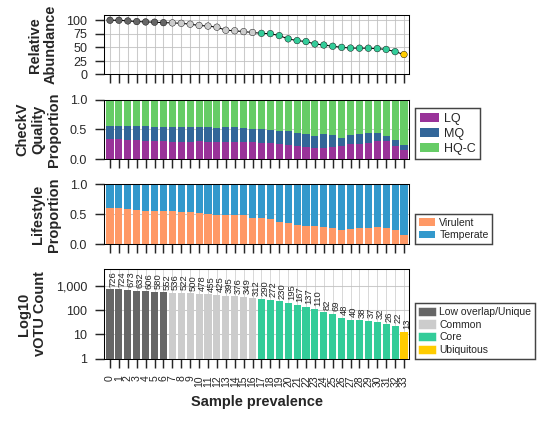

In [33]:

# Build plotting table
merged_df = summary_prevalence_df.rename(columns={
    "cummulative_relative_abundance": "sample_relative_cummulative",
    "proportion_low_quality_not_determined": "proportion_lq_nd",
    "proportion_medium_quality": "proportion_mq",
    "proportion_high_quality_complete": "proportion_hq_complete",
    "proportion_virulent": "proportion_v",
    "proportion_temperate": "proportion_t",
    "log_cumulative_counts": "log_sample_count_cummulative",
    "sample_count_cumulative": "sample_count_cummulative"
}).copy()

# Fill NaN values before plotting
merged_df = merged_df.fillna(0)

# Create four stacked panels
fig, (ax0, ax1, ax2, ax3) = plt.subplots(
    4,
    1,
    figsize=(320 * points_to_inches, 200 * points_to_inches),
    sharex=True,
    gridspec_kw={'height_ratios': [1, 1, 1, 1.5]}  # Fourth plot larger
)

# Apply black panel borders
for ax in [ax0, ax1, ax2, ax3]:
    for spine in ax.spines.values():
        spine.set_edgecolor("black")
        spine.set_linewidth(0.5)

# Plot abundance curve
# Draw black connector line
ax0.plot(
    merged_df["sample_count"],
    merged_df["sample_relative_cummulative"],
    color="black", linestyle='-', linewidth=0.5, zorder=1
)

# Color points by type
ax0.scatter(
    merged_df["sample_count"],
    merged_df["sample_relative_cummulative"],
    c=merged_df["type"],
    s=10,  # marker size
    edgecolor='black',
    linewidth=0.2,
    zorder=2
)

# Format axes
ax0.set_ylabel("Relative\nAbundance")
ax0.set_ylim(0, 110)
ax0.set_yticks([0, 25, 50, 75, 100])
ax0.grid(True, linewidth=0.5)

# Plot quality proportions
ax1.bar(
    merged_df["sample_count"],
    merged_df["proportion_lq_nd"],
    label='LQ', color='#993399', width=0.8, edgecolor='none'
)
ax1.bar(
    merged_df["sample_count"],
    merged_df["proportion_mq"],
    bottom=merged_df["proportion_lq_nd"],
    label='MQ', color='#336699', width=0.8, edgecolor='none'
)
ax1.bar(
    merged_df["sample_count"],
    merged_df["proportion_hq_complete"],
    bottom=merged_df["proportion_lq_nd"] + merged_df["proportion_mq"],
    label='HQ-C', color='#66CC66', width=0.8, edgecolor='none'
)

ax1.set_ylabel("CheckV\nQuality\nProportion")
ax1.legend(fontsize=6, bbox_to_anchor=(1.02, 0), loc='lower left', borderaxespad=0)
ax1.set_ylim(0, 1)
ax1.grid(True, linewidth=0.5)

# Plot lifestyle proportions
ax2.bar(
    merged_df["sample_count"],
    merged_df["proportion_v"],
    label='Virulent', color=palette_lifestyle["Virulent"], width=0.8, edgecolor='none'
)
ax2.bar(
    merged_df["sample_count"],
    merged_df["proportion_t"],
    bottom=merged_df["proportion_v"],
    label='Temperate', color=palette_lifestyle["Temperate"], width=0.8, edgecolor='none'
)

ax2.set_ylabel("Lifestyle\nProportion")
ax2.legend(fontsize=5, bbox_to_anchor=(1.02, 0), loc='lower left', borderaxespad=0)
ax2.set_ylim(0, 1)
ax2.grid(True, linewidth=0.5)

# Plot cumulative counts
ax3.bar(
    merged_df["sample_count"],
    merged_df["log_sample_count_cummulative"],
    color=merged_df["type"],
    width=0.8,
    edgecolor='none'
)

# Label bars with raw counts
for i, p in enumerate(ax3.patches):
    if i < len(merged_df):
        original_value = merged_df.loc[i, "sample_count_cummulative"]
        ax3.annotate(
            f"{int(original_value):,}",
            (p.get_x() + 0.25, p.get_height() + 0.2),
            rotation=90,
            fontsize=4.5
        )

# Format y axis
ax3.yaxis.set_major_locator(MultipleLocator(1))
ax3.yaxis.grid(True, which='major', linewidth=0.5)

ax3.set_ylabel("Log10\nvOTU Count")
ax3.set_xlabel("Sample prevalence")
ax3.set_yticks([0, 1, 2, 3])
ax3.set_yticklabels(['1', '10', '100', '1,000'])
ax3.set_ylim(0,3.7)

ax0.set_xlim(merged_df["sample_count"].min() - 0.7, merged_df["sample_count"].max() + 0.6)

# Build custom legend
blue_patch = mpatches.Patch(color='#666666', label='Low overlap/Unique')
gray_patch = mpatches.Patch(color='#CCCCCC', label='Common')
red_patch = mpatches.Patch(color='#33CC99', label='Core')
green_patch = mpatches.Patch(color="#FFCC00", label='Ubiquitous')

ax3.legend(
    handles=[blue_patch, gray_patch, red_patch, green_patch],
    fontsize=5,
    bbox_to_anchor=(1.02, 0),
    loc='lower left',
    borderaxespad=0
)

xticks = merged_df["sample_count"]
ax3.set_xticks(xticks)
ax3.set_xticklabels(xticks, rotation=90, fontsize=5)
# Finalize layout and save
tight_layout_with_legend(fig)
fig.savefig(
    "/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/FIGURES_AND_TABLES/2a_core_abundant_phages_with_quality_lifestyle.svg",
    format="svg"
)
plt.show()


In [34]:
merged_df

,sample_count,sample_relative_cummulative,proportion_lq_nd,proportion_mq,proportion_hq_complete,proportion_v,proportion_t,log_sample_count_cummulative,sample_count_cummulative,type
0,0,100.000000,0.331956,0.231405,0.436639,0.595041,0.404959,2.860937,726,#666666
1,1,100.000000,0.332873,0.232044,0.435083,0.596685,0.403315,2.859739,724,#666666
2,2,98.762022,0.322437,0.233284,0.444279,0.582467,0.417533,2.828015,673,#666666
3,3,97.590165,0.316456,0.240506,0.443038,0.566456,0.433544,2.800717,632,#666666
4,4,96.890960,0.306931,0.245875,0.447195,0.559406,0.440594,2.782473,606,#666666
5,5,96.435440,0.301724,0.243103,0.455172,0.555172,0.444828,2.763428,580,#666666
6,6,95.534224,0.300725,0.237319,0.461957,0.545290,0.454710,2.741939,552,#666666
7,7,95.132224,0.296642,0.242537,0.460821,0.544776,0.455224,2.729165,536,#CCCCCC
8,8,94.377698,0.293103,0.243295,0.463602,0.540230,0.459770,2.717671,522,#CCCCCC
9,9,92.720318,0.296000,0.242000,0.462000,0.536000,0.464000,2.698970,500,#CCCCCC


In [35]:
round(100-95.53422430667416,1)

4.5

In [36]:
# Note that core is a subset of common
unique_phages=df_abundances_core_phyllosphere[df_abundances_core_phyllosphere["sample_percentage"]<20]["vOTU"].to_list()
common_phages=df_abundances_core_phyllosphere[df_abundances_core_phyllosphere["sample_percentage"]>=20]["vOTU"].to_list()
core_phages=df_abundances_core_phyllosphere[df_abundances_core_phyllosphere["sample_percentage"]>=50]["vOTU"].to_list()
ubiquitous_phages=df_abundances_core_phyllosphere[(df_abundances_core_phyllosphere["sample_percentage"]==100)]["vOTU"].to_list()

with open(work_dir + "unique_list.txt", 'w') as fp:
    for item in unique_phages:
        # Write one item per line
        fp.write("%s\n" % item)

with open(work_dir + "common_list.txt", 'w') as fp:
    for item in common_phages:
        # Write one item per line
        fp.write("%s\n" % item)

with open(work_dir + "core_list.txt", 'w') as fp:
    for item in core_phages:
        # Write one item per line
        fp.write("%s\n" % item)

with open(work_dir + "ubiquitous_list.txt", 'w') as fp:
    for item in ubiquitous_phages:
        # Write one item per line
        fp.write("%s\n" % item)

print(len(unique_phages), round(100*len(unique_phages)/len(df_abundances_core_phyllosphere),1))    
print(len(common_phages), round(100*len(common_phages)/len(df_abundances_core_phyllosphere),1))    
print(len(core_phages), round(100*len(core_phages)/len(df_abundances_core_phyllosphere),1))    
print(len(ubiquitous_phages), round(100*len(ubiquitous_phages)/len(df_abundances_core_phyllosphere),1))    


190 26.2
536 73.8
290 39.9
13 1.8


In [37]:
df_abundances_core_phyllosphere

,vOTU,sample_count,max,sample_percentage,count_Y,checkV_contig_length,VirSorter2_positive,VIBRANT_positive,geNomad_viral,geNomad_viral_conservative,...,DENMARK_LEAF,DENMARK_PHYLLOSPHERE,USA_LEAF,INTERESTING,PHYLLOSPHERE,COMPARISON,all_vOTUs,vOTU_number,vOTU_name,vOTU_name_final
0,vSE_T_70_NODE_2_length_44469_cov_162.284820,0,NaN,0.0,3,44469,Y,Y,Y,Y,...,N/A,N/A,TRUE,TRUE,TRUE,TRUE,TRUE,vOTU_0009,vSE_T_70_NODE_2_length_44469_cov_162.284820,vOTU_0009
1,vSE_20_NODE_4_length_47200_cov_83.488111,0,NaN,0.0,3,47200,Y,Y,Y,Y,...,N/A,N/A,TRUE,TRUE,TRUE,TRUE,TRUE,vOTU_0028,vSE_20_NODE_4_length_47200_cov_83.488111,vOTU_0028
2,vSWd_10_NODE_11_length_10310_cov_13.223306,1,0.008468,3.0,3,10310,Y,Y,Y,Y,...,TRUE,TRUE,TRUE,TRUE,TRUE,TRUE,TRUE,vOTU_0122,vSWd_10_NODE_11_length_10310_cov_13.223306,vOTU_0122
3,vF3A_NODE_31_length_39578_cov_64.458746,1,0.139300,3.0,3,39578,Y,Y,Y,Y,...,TRUE,TRUE,N/A,TRUE,TRUE,TRUE,TRUE,vOTU_2374,vF3A_NODE_31_length_39578_cov_64.458746,vOTU_2374
4,vN3_NODE_18_length_24456_cov_100.053973,1,3.712957,3.0,3,24456,Y,Y,Y,Y,...,TRUE,TRUE,N/A,TRUE,TRUE,TRUE,TRUE,vOTU_0138,vN3_NODE_18_length_24456_cov_100.053973,vOTU_0138
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
721,vS3C_T_NODE_78_length_14889_cov_89.463665,33,28.435035,100.0,3,14889,Y,Y,Y,Y,...,TRUE,TRUE,TRUE,TRUE,TRUE,TRUE,TRUE,vOTU_0005,vS3C_T_NODE_78_length_14889_cov_89.463665,vOTU_0005
722,vO2C_NODE_54_length_77920_cov_109.386798,33,3.942370,100.0,3,77920,Y,Y,Y,Y,...,TRUE,TRUE,N/A,TRUE,TRUE,TRUE,TRUE,vOTU_0030,vO2C_NODE_54_length_77920_cov_109.386798,vOTU_0030
723,E_aphidicola_Z9_3_pp3_cluster_15,33,75.662856,100.0,3,41269,Y,Y,Y,Y,...,TRUE,TRUE,N/A,TRUE,TRUE,TRUE,TRUE,vOTU_0002,E_aphidicola_Z9_3_pp3_cluster_15,Erwinia virus Trolltunga
724,E_aphidicola_Z9_3_pp1_cluster_4,33,10.207427,100.0,3,43584,Y,Y,Y,Y,...,TRUE,TRUE,TRUE,TRUE,TRUE,TRUE,TRUE,vOTU_0014,E_aphidicola_Z9_3_pp1_cluster_4,Erwinia virus Skarstind


In [38]:
# Start with vOTU index
df_prevalence = df_abundances_core_phyllosphere[["vOTU"]].set_index("vOTU")

# Initialize prevalence as unique
df_prevalence["category"] = "unique"

# Update prevalence groups
df_prevalence.loc[common_phages, "category"] = "common"
df_prevalence.loc[core_phages, "category"] = "core"
df_prevalence.loc[ubiquitous_phages, "category"] = "ubiquitous"

df_prevalence.to_csv("/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/FIGURES_AND_TABLES/prevalence_metadata.csv")
df_prevalence


,category
vOTU,
vSE_T_70_NODE_2_length_44469_cov_162.284820,unique
vSE_20_NODE_4_length_47200_cov_83.488111,unique
vSWd_10_NODE_11_length_10310_cov_13.223306,unique
vF3A_NODE_31_length_39578_cov_64.458746,unique
vN3_NODE_18_length_24456_cov_100.053973,unique
...,...
vS3C_T_NODE_78_length_14889_cov_89.463665,ubiquitous
vO2C_NODE_54_length_77920_cov_109.386798,ubiquitous
E_aphidicola_Z9_3_pp3_cluster_15,ubiquitous


In [39]:
hex_colors_9=["#0000FF", "#006400", "#FF0000", "#800080", "#FFA500", "#FFFF00", "#FF00FF", "#00FFFF"]
# colors <- c("blue", "darkgreen", "red", "purple", "orange", "yellow", "magenta", "cyan")

metadata_phageome=phyllosphere_active_metadata.copy()
metadata_phageome['phageome'] = ""

metadata_phageome.loc[common_phages, "phageome_color"] = "#4682b4"
metadata_phageome.loc[core_phages, "phageome_color"] = "#9acd32"
metadata_phageome.loc[ubiquitous_phages, "phageome_color"] = "#FF0000"
metadata_phageome=metadata_phageome[metadata_phageome['phageome_color']!=""]


metadata_phageome["phageome"]="unique"
metadata_phageome.loc[common_phages, "phageome"] = "common"
metadata_phageome.loc[core_phages, "phageome"] = "core"
metadata_phageome.loc[ubiquitous_phages, "phageome"] = "ubiquitous"


metadata_phageome['host_family_color'] = "#4682b4"
# Assign colors to the 'family_color' column for each family
metadata_phageome.loc[metadata_phageome["family"] == "Sphingomonadaceae", 'host_family_color'] = hex_colors_9[0] # blue
metadata_phageome.loc[metadata_phageome["family"] == "Pseudomonadaceae", 'host_family_color'] = hex_colors_9[1] # darkgreen
metadata_phageome.loc[metadata_phageome["family"] == "Erwiniaceae", 'host_family_color'] = hex_colors_9[2] # red
metadata_phageome.loc[metadata_phageome["family"] == "Microbacteriaceae", 'host_family_color'] = hex_colors_9[3] # purple
metadata_phageome.loc[metadata_phageome["family"] == "Morganellaceae", 'host_family_color'] = hex_colors_9[4] # orange


metadata_phageome['viral_family_color'] = "#4682b4"
# Assign colors to the 'family_color' column for each family
metadata_phageome['prediction'] = ""

metadata_phageome.loc[metadata_phageome["prediction"] == "Peduoviridae", 'viral_family_color'] = hex_colors_9[0] # blue
metadata_phageome.loc[metadata_phageome["prediction"] == "Vilmaviridae", 'viral_family_color'] = hex_colors_9[1] # darkgreen
metadata_phageome.loc[metadata_phageome["prediction"] == "Mesyanzhinovviridae", 'viral_family_color'] = hex_colors_9[2] # red
metadata_phageome.loc[metadata_phageome["prediction"] == "Orlajensenviridae", 'viral_family_color'] = hex_colors_9[3] # purple
metadata_phageome.loc[metadata_phageome["prediction"] == "Drexlerviridae", 'viral_family_color'] = hex_colors_9[4] # orange
metadata_phageome.loc[metadata_phageome["prediction"] == "Zierdtviridae", 'viral_family_color'] = hex_colors_9[5] # yellow
metadata_phageome.loc[metadata_phageome["prediction"] == "Casjensviridae", 'viral_family_color'] = hex_colors_9[6] # magenta


metadata_phageome.to_csv("metadata_phageome.txt", sep="\t")

metadata_phageome["host_family_color"]

vOTU
E_aphidicola_Z9_3_pp3_cluster_15                #FF0000
APSE_wheat                                      #4682b4
vS1B_20_NODE_11_length_139468_cov_83.775100     #FF0000
vF2A_40_NODE_6_length_51705_cov_107.419361      #4682b4
vSWd_30_NODE_3_length_42737_cov_105.646080      #FF0000
                                                 ...   
vO2C_50_NODE_1075_length_12130_cov_22.014493    #4682b4
vF2A_NODE_185_length_17243_cov_19.384571        #4682b4
vF2A_NODE_374_length_10113_cov_7.938457         #FF0000
vO2B_90_NODE_353_length_23302_cov_5.848540      #800080
vF3C_60_NODE_234_length_29103_cov_149.607374    #4682b4
Name: host_family_color, Length: 726, dtype: object

In [40]:
metadata_phageome.loc[ubiquitous_phages]

,count_Y,checkV_contig_length,VirSorter2_positive,VIBRANT_positive,geNomad_viral,geNomad_viral_conservative,VIBRANT_circular,VIBRANT_lifecycle,VIBRANT_quality,VIBRANT_total_genes,...,COMPARISON,all_vOTUs,vOTU_number,vOTU_name,vOTU_name_final,phageome,phageome_color,host_family_color,viral_family_color,prediction
vOTU,,,,,,,,,,,,,,,,,,,,,
vO3A_70_NODE_154_length_13639_cov_186.811985,3,13639,Y,Y,Y,Y,N/A,lytic,low quality draft,18.0,...,TRUE,TRUE,vOTU_0008,vO3A_70_NODE_154_length_13639_cov_186.811985,vOTU_0008,ubiquitous,#FF0000,#4682b4,#4682b4,
vS1B_20_NODE_11_length_139468_cov_83.775100,3,139468,Y,Y,Y,Y,Y,lytic,high quality draft,259.0,...,TRUE,TRUE,vOTU_0006,vS1B_20_NODE_11_length_139468_cov_83.775100,vOTU_0006,ubiquitous,#FF0000,#FF0000,#4682b4,
vN2_10_NODE_2_length_39732_cov_172.456511,3,39732,Y,Y,Y,Y,N/A,lysogenic,high quality draft,45.0,...,TRUE,TRUE,vOTU_0003,vN2_10_NODE_2_length_39732_cov_172.456511,vOTU_0003,ubiquitous,#FF0000,#4682b4,#4682b4,
E_aphidicola_B01_10_pp1_cluster_1,3,40535,Y,Y,Y,Y,N/A,lysogenic,high quality draft,60.0,...,TRUE,TRUE,vOTU_0013,E_aphidicola_B01_10_pp1_cluster_1,Erwinia virus Galdhoepiggen,ubiquitous,#FF0000,#FF0000,#4682b4,
E_aphidicola_B01_5_pp1_cluster_3,3,46453,Y,Y,Y,Y,N/A,lysogenic,high quality draft,80.0,...,TRUE,TRUE,vOTU_0551,E_aphidicola_B01_5_pp1_cluster_3,Erwinia virus Glittertind,ubiquitous,#FF0000,#FF0000,#4682b4,
E_aphidicola_W04_1_pp2_cluster_8,3,48079,Y,Y,Y,Y,N/A,lysogenic,high quality draft,82.0,...,TRUE,TRUE,vOTU_0068,E_aphidicola_W04_1_pp2_cluster_8,Erwinia virus Jervasstind,ubiquitous,#FF0000,#FF0000,#4682b4,
E_aphidicola_W09_2_pp1_cluster_11,3,47422,Y,Y,Y,Y,N/A,lysogenic,medium quality draft,76.0,...,TRUE,TRUE,vOTU_0103,E_aphidicola_W09_2_pp1_cluster_11,Erwinia virus Rondeslottet,ubiquitous,#FF0000,#FF0000,#4682b4,
APSE_wheat,3,41352,Y,Y,Y,Y,N/A,lysogenic,high quality draft,36.0,...,TRUE,TRUE,vOTU_0001,APSE_wheat,APSE_wheat,ubiquitous,#FF0000,#4682b4,#4682b4,
vS3C_T_NODE_78_length_14889_cov_89.463665,3,14889,Y,Y,Y,Y,N/A,lytic,medium quality draft,17.0,...,TRUE,TRUE,vOTU_0005,vS3C_T_NODE_78_length_14889_cov_89.463665,vOTU_0005,ubiquitous,#FF0000,#4682b4,#4682b4,


### 2b. Ubiquitous avOTUs


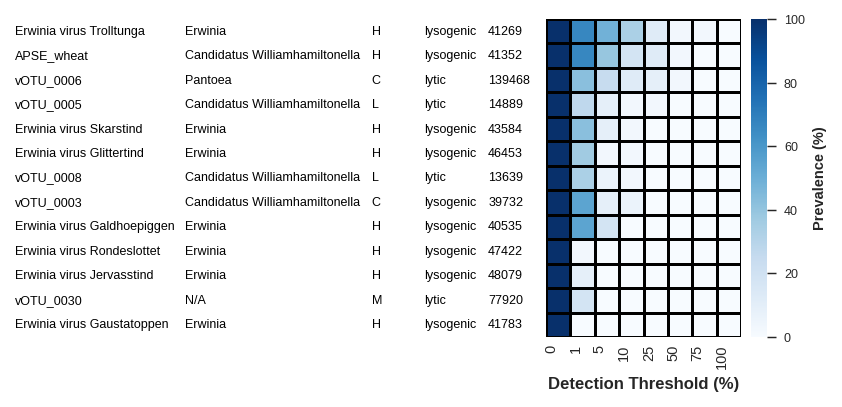

In [41]:
# Compute prevalence heatmap
thresholds = [0, 1, 5, 10, 25, 50, 75, 100]
abundances_df = relative_norm_df[SAMPLES_dk_core].T

core_phages_heatmap = pd.DataFrame(
    {thr: (abundances_df > thr).mean() * 100 for thr in thresholds},
    index=abundances_df.columns
)

# Keep vOTUs present in all samples
core_phages_heatmap = core_phages_heatmap[core_phages_heatmap[0] >= 100]
core_phages_heatmap["counts"] = (core_phages_heatmap.T > 0).sum()
core_phages_heatmap = core_phages_heatmap.sort_values(by=[0, "counts"], ascending=[True, True])
core_phages_heatmap = core_phages_heatmap.drop("counts", axis=1)

# Extract annotation metadata
meta = phyllosphere_active_metadata_names.loc[core_phages_heatmap.index, [
    "vOTU_name_final", "genus", "checkv_quality", "VIBRANT_lifecycle", "geNomad_length"
]].copy()
meta["checkv_quality_short"]=meta["checkv_quality"].str[0]
meta = meta.fillna({"genus": "", "checkv_quality": "", "VIBRANT_lifecycle": "", "geNomad_length": 0})
meta["geNomad_length"] = meta["geNomad_length"].astype(int)

# Reverse order for plotting
core_phages_heatmap = core_phages_heatmap.iloc[::-1]
meta = meta.loc[core_phages_heatmap.index]

# Scale figure size
n_rows = len(core_phages_heatmap)
row_height = 0.2  # height per vOTU row
fig_height = (n_rows * row_height)

# Set up figure and GridSpec
fig = plt.figure(figsize=(5.5, fig_height), constrained_layout=True)
gs = gridspec.GridSpec(
    1, 6, width_ratios=[2.0, 1.5, 1.2, 1.0, 0.8, 6], wspace=0.05, figure=fig
)

ax_name = fig.add_subplot(gs[0])
ax_genus = fig.add_subplot(gs[1])
ax_quality = fig.add_subplot(gs[2])
ax_life = fig.add_subplot(gs[3])
ax_len = fig.add_subplot(gs[4])
ax_heat = fig.add_subplot(gs[5])

# Plot heatmap
sns.heatmap(
    core_phages_heatmap,
    cmap="Blues",
    ax=ax_heat,
    linewidths=0.5,
    linecolor="black",        
    cbar_kws={"label": "Prevalence (%)"},
    square=True,
    yticklabels=False,
    norm=colors.PowerNorm(gamma=1)
)


ax_heat.set_xlabel("Detection Threshold (%)", fontsize=8)
ax_heat.set_ylabel("")
ax_heat.set_xticklabels(thresholds, rotation=90, ha='right', fontsize=7)
ax_heat.tick_params(axis='x', length=0)
ax_heat.tick_params(axis='y', length=0)

# Plot annotation columns
text_column(ax_name, meta["vOTU_name_final"], "vOTU", fontsize=6)
text_column(ax_genus, meta["genus"], "Host Genus", fontsize=6)
text_column(ax_quality, meta["checkv_quality_short"], "Q", fontsize=6)
text_column(ax_life, meta["VIBRANT_lifecycle"], "Lifecycle", fontsize=6)
text_column(ax_len, meta["geNomad_length"], "Length (bp)", fontsize=6)

# Finalize and save
plt.savefig(
    "/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/FIGURES_AND_TABLES/2b_core_phages_heatmap.svg",
    bbox_inches="tight", dpi=300
)
plt.show()


In [42]:
relative_norm_df

,vBRB,vBRB_T,vF1A,vF1A_T,vF1B,vF1B_T,vF1C,vF1C_T,vF1aB,vF1aB_T,...,vSWd,vSWd_T,vWRB,vWRB_T,vZ1,vZ1_T,vZ2,vZ2_T,vZ3,vZ3_T
vOTU,,,,,,,,,,,,,,,,,,,,,
vF1A_NODE_15_length_55414_cov_117.738272,0.0,NaN,1.969303,0.785428,0.035996,0.000000,0.045529,0.000000,0.009549,0.008997,...,0.0,0.0,0.0,NaN,0.028120,0.000000,0.000000,0.000000,0.043862,0.000000
vF1A_NODE_21_length_50268_cov_25.127975,0.0,NaN,0.132447,0.047494,0.000000,0.000000,0.000000,0.000000,0.000821,0.000000,...,0.0,0.0,0.0,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
vF1A_NODE_25_length_46176_cov_137.405238,0.0,NaN,2.781544,1.004443,0.031496,0.000000,0.000000,0.000000,0.006041,0.000000,...,0.0,0.0,0.0,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
vF1A_NODE_27_length_45010_cov_117.886509,0.0,NaN,1.830557,0.917972,0.025019,0.000000,0.011154,0.000000,0.000438,0.000000,...,0.0,0.0,0.0,NaN,0.018017,0.000000,0.000000,0.000000,0.014704,0.000000
vF1A_NODE_41_length_38092_cov_133.464600,0.0,NaN,0.187973,0.166012,0.467179,0.534786,0.018018,0.000000,0.856794,1.269903,...,0.0,0.0,0.0,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
E_aphidicola_W09_5_pp2_cluster_12,0.0,NaN,0.025785,0.025693,0.583028,0.982952,0.783649,1.719599,0.526510,0.786740,...,0.0,0.0,0.0,NaN,0.191480,0.000000,0.439982,1.123041,0.391907,0.741334
E_aphidicola_Z9_3_pp1_cluster_4,0.0,NaN,0.273621,0.115437,3.848822,2.657381,0.378623,0.345874,3.781218,4.226094,...,0.0,0.0,0.0,NaN,1.674480,1.696544,10.207427,6.258068,5.282758,5.041793
E_aphidicola_Z9_3_pp3_cluster_15,0.0,NaN,1.903786,0.620176,2.536506,1.882908,26.145091,23.808449,1.730667,1.378749,...,0.0,0.0,0.0,NaN,36.558950,26.916607,11.107847,7.137755,15.441298,9.819190


In [43]:
metadata_df_high_comparison_phyllosphere = phyllosphere_metadata[
    phyllosphere_metadata["checkv_quality"].isin(["Complete", "High-quality"])
].copy()

taxmyphage_export_columns = [
    "Realm", "Kingdom", "Phylum", "Class", "Order", "Family", "Subfamily", "Genus", "Species"
]
taxmyphage_export_df = taxmyphage_df.reset_index()[[
    "Genome",
    "taxmyphage_realm",
    "taxmyphage_kingdom",
    "taxmyphage_phylum",
    "taxmyphage_class",
    "taxmyphage_order",
    "taxmyphage_family",
    "taxmyphage_subfamily",
    "taxmyphage_genus",
    "taxmyphage_species",
]].rename(columns={
    "taxmyphage_realm": "Realm",
    "taxmyphage_kingdom": "Kingdom",
    "taxmyphage_phylum": "Phylum",
    "taxmyphage_class": "Class",
    "taxmyphage_order": "Order",
    "taxmyphage_family": "Family",
    "taxmyphage_subfamily": "Subfamily",
    "taxmyphage_genus": "Genus",
    "taxmyphage_species": "Species",
})

taxmyphage_assigned = (
    metadata_df_high_comparison_phyllosphere.loc[
        metadata_df_high_comparison_phyllosphere["taxmyphage_realm"] != "Unknown"
    ]
    .reset_index()
    .merge(taxmyphage_export_df, left_on="vOTU", right_on="Genome", how="left")
    .assign(
        vOTU_representative=lambda data: data["vOTU"],
        vOTU_number=lambda data: data["vOTU_number"].fillna("N/A"),
    )
    [["vOTU_number", "vOTU_representative", *taxmyphage_export_columns]]
    .fillna("Unknown")
    .sort_values(["Genus", "vOTU_number", "vOTU_representative"])
)
taxmyphage_assigned.to_csv(
    "/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/FIGURES_AND_TABLES/STable8_taxmyphage_assigned.csv",
    index=False
)
print(len(taxmyphage_assigned))
taxmyphage_assigned.value_counts("Genus")
taxmyphage_assigned.sort_values("vOTU_number")


15


,vOTU_number,vOTU_representative,Realm,Kingdom,Phylum,Class,Order,Family,Subfamily,Genus,Species
0,vOTU_0001,APSE_wheat,Duplodnaviria,Heunggongvirae,Uroviricota,Caudoviricetes,Not Defined Yet,Not Defined Yet,Not Defined Yet,Sendosyvirus,Sendosyvirus new_name
1,vOTU_0003,vN2_10_NODE_2_length_39732_cov_172.456511,Duplodnaviria,Heunggongvirae,Uroviricota,Caudoviricetes,Not Defined Yet,Not Defined Yet,Not Defined Yet,Sendosyvirus,Sendosyvirus new_name
2,vOTU_0070,vFL_amp_NODE_36_length_45369_cov_114.839586,Duplodnaviria,Heunggongvirae,Uroviricota,Caudoviricetes,Not Defined Yet,Autographiviridae,Molineuxvirinae,Eracentumvirus,Eracentumvirus new_name
8,vOTU_0075,vN1_50_NODE_7_length_39066_cov_17.158545,Duplodnaviria,Heunggongvirae,Uroviricota,Caudoviricetes,Not Defined Yet,Autographiviridae,Studiervirinae,Kayfunavirus,Kayfunavirus new_name
4,vOTU_0118,vOL_amp_NODE_19_length_58567_cov_14.129700,Duplodnaviria,Heunggongvirae,Uroviricota,Caudoviricetes,Not Defined Yet,Chaseviridae,Cleopatravirinae,Loessnervirus,Loessnervirus new_name
5,vOTU_0120,vZ3_NODE_11_length_41515_cov_96.067270,Duplodnaviria,Heunggongvirae,Uroviricota,Caudoviricetes,Not Defined Yet,Not Defined Yet,Not Defined Yet,Murrayvirus,Murrayvirus new_name
7,vOTU_0144,vFL_amp_10_NODE_5_length_52465_cov_80.849685,Duplodnaviria,Heunggongvirae,Uroviricota,Caudoviricetes,Not Defined Yet,Drexlerviridae,Not Defined Yet,Sauletekiovirus,Sauletekiovirus new_name
3,vOTU_0153,vS3C_T_40_NODE_1_length_244554_cov_47.395948,Duplodnaviria,Heunggongvirae,Uroviricota,Caudoviricetes,Not Defined Yet,Chimalliviridae,Not Defined Yet,Wellingtonvirus,Wellingtonvirus wellington
9,vOTU_0368,vOL_NODE_107_length_39844_cov_140.561462,Duplodnaviria,Heunggongvirae,Uroviricota,Caudoviricetes,Not Defined Yet,Autographiviridae,Studiervirinae,Elunavirus,Elunavirus new_name
6,vOTU_0395,vFL_90_NODE_53_length_47334_cov_154.181391,Duplodnaviria,Heunggongvirae,Uroviricota,Caudoviricetes,Not Defined Yet,Autographiviridae,Colwellvirinae,Uliginvirus,Uliginvirus new_name


In [44]:
erwinia_associated_avotu_df = pd.DataFrame({
    "mean_relative_abundance": relative_norm_df[SAMPLES].mean(axis=1),
}).join(metadata_df[["widespread_name"]])

erwinia_associated_avotu_df = erwinia_associated_avotu_df[
    metadata_phageome["phageome"].eq("ubiquitous")
    & erwinia_associated_avotu_df["widespread_name"].notna()
    & erwinia_associated_avotu_df["widespread_name"].ne("N/A")
]

erwinia_relative_abundance_pct = erwinia_associated_avotu_df["mean_relative_abundance"].sum()
print(f"Erwinia-associated avOTUs account for {erwinia_relative_abundance_pct:.1f}% of total relative abundance")
erwinia_associated_avotu_df


Erwinia-associated avOTUs account for 15.2% of total relative abundance


,mean_relative_abundance,widespread_name
vOTU,,
E_aphidicola_B01_10_pp1_cluster_1,2.211379,Erwinia virus Galdhoepiggen
E_aphidicola_B01_5_pp1_cluster_3,1.018025,Erwinia virus Glittertind
E_aphidicola_W04_1_pp2_cluster_8,0.228484,Erwinia virus Jervasstind
E_aphidicola_W09_2_pp1_cluster_11,0.158626,Erwinia virus Rondeslottet
E_aphidicola_W09_5_pp2_cluster_12,0.147935,Erwinia virus Gaustatoppen
E_aphidicola_Z9_3_pp1_cluster_4,1.501652,Erwinia virus Skarstind
E_aphidicola_Z9_3_pp3_cluster_15,9.918202,Erwinia virus Trolltunga


### 2c. Prevalence by Predicted Lifestyle


Shapiro p-values:
Temperate: 1.75e-05
Virulent: 8.93e-11


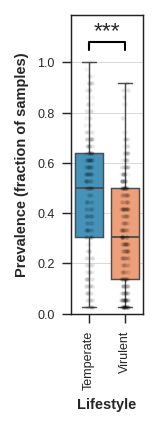

,Group,N,Mean_prevalence,Median_prevalence,Std_prevalence,Shapiro_p,Normal?,Test,Statistic,p_value
0,Temperate,294.0,0.472222,0.500000,0.239713,1.751834e-05,False,NaN,NaN,NaN
1,Virulent,432.0,0.322274,0.305556,0.214430,8.931646e-11,False,NaN,NaN,NaN
2,Comparison,NaN,NaN,NaN,NaN,NaN,False,Mann-Whitney U,86835.500000,3.833200e-17
3,Comparison,NaN,NaN,NaN,NaN,NaN,False,Welch t-test,8.630205,5.857612e-17


In [45]:
active_phyllosphere_df = phyllosphere_active_metadata.copy()

# Convert to presence-absence
presence_df = active_phyllosphere_df[SAMPLES] > 0
presence_df = presence_df.astype(int)

# Compute vOTU prevalence
active_phyllosphere_df['prevalence'] = presence_df.sum(axis=1) / len(SAMPLES)

# Add lifestyle labels
active_phyllosphere_df['Lifestyle'] = active_phyllosphere_df['BACPLHIP_lifestyle']

# Split values by lifestyle
temp_values = active_phyllosphere_df.loc[active_phyllosphere_df['Lifestyle']=='Temperate', 'prevalence']
vir_values = active_phyllosphere_df.loc[active_phyllosphere_df['Lifestyle']=='Virulent', 'prevalence']

# Run Shapiro tests
_, p_temp_norm = shapiro(temp_values)
_, p_vir_norm = shapiro(vir_values)

temp_normal = p_temp_norm > 0.05
vir_normal = p_vir_norm > 0.05
both_normal = temp_normal and vir_normal

print("Shapiro p-values:")
print("Temperate:", fmt_pvalue(p_temp_norm))
print("Virulent:", fmt_pvalue(p_vir_norm))

# Run statistical tests
results = []

mw_stat, mw_p = mannwhitneyu(temp_values, vir_values, alternative='two-sided')
results.append({
    "Group": "Comparison",
    "Normal?": both_normal,
    "Test": "Mann-Whitney U",
    "Statistic": mw_stat,
    "p_value": mw_p
})

t_stat, t_p = ttest_ind(temp_values, vir_values, equal_var=False)
results.append({
    "Group": "Comparison",
    "Normal?": both_normal,
    "Test": "Welch t-test",
    "Statistic": t_stat,
    "p_value": t_p
})

results_df = pd.DataFrame(results)

# Choose test for display
if both_normal:
    display_test = "Welch t-test"
    display_p = t_p
else:
    display_test = "Mann-Whitney U"
    display_p = mw_p

# Build summary table
group_summary = pd.DataFrame({
    "Group": ["Temperate", "Virulent"],
    "N": [len(temp_values), len(vir_values)],
    "Mean_prevalence": [temp_values.mean(), vir_values.mean()],
    "Median_prevalence": [temp_values.median(), vir_values.median()],
    "Std_prevalence": [temp_values.std(), vir_values.std()],
    "Shapiro_p": [p_temp_norm, p_vir_norm],
    "Normal?": [temp_normal, vir_normal]
})

summary_df = pd.concat([group_summary, results_df], ignore_index=True)


# Save summary
summary_df.to_csv(
    "/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/FIGURES_AND_TABLES/STable12_lifestyle_comparison_prevalence_stats.csv",
    index=False
)

# Plot results
plt.figure(figsize=(1,2.8))

order = ["Temperate", "Virulent"]

ax = sns.boxplot(
    x='Lifestyle',
    y='prevalence',
    data=active_phyllosphere_df,
    order=order,
    palette=palette_lifestyle
)

sns.stripplot(
    x='Lifestyle',
    y='prevalence',
    data=active_phyllosphere_df,
    order=order,
    color='black',
    size=2,
    jitter=True,
    alpha=0.05
)

plt.ylabel("Prevalence (fraction of samples)")
# plt.title("vOTU Prevalence by Lifestyle")

# Add significance bar
y_max = active_phyllosphere_df['prevalence'].max()
add_significance_bar(
    ax,
    x1=0,
    x2=1,
    y=y_max*1.05,
    h=y_max*0.03,
    p_value=display_p
)

plt.ylim(0, 1.19)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

plt.tight_layout()

plt.savefig(
    "/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/FIGURES_AND_TABLES/2c_lifestyle_comparison_prevalence.svg",
    bbox_inches='tight'
)

plt.show()

summary_df


## Figure 4. Host Interactions in the Wheat Phyllosphere


### 4a. Predicted Host Genera of High-Quality and Complete avOTUs


In [46]:
# Build vOTU list
vOTU_list = metadata_df_high_active_phyllosphere.index.to_list()
vOTU_list=comparison_metadata[comparison_metadata["checkV_miuvig_quality"]=="High-quality"].index.to_list()
# Load input files
vcontact_data = pd.read_csv(
    "/home/lmf/apps/MOSAIC/mosaic/db/vcontact2/6Nov2024_data.tsv",
    sep="\t"
)

vcontact_df = pd.read_csv(
    "/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/07_ANNOTATION/filtered_95-85_positive_viral_contigs_vContact.tot/genome_by_genome_overview.csv"
)

# Merge taxonomy into vContact output
vcontact_df = vcontact_df.merge(
    vcontact_data,
    left_on="Genome",
    right_on="Accession",
    how="left"
)

# Normalize VC names
vcontact_df["VC_base"] = (
    vcontact_df["VC"]
    .astype(str)
    .str.rsplit("_", n=1)
    .str[0]
)

# Flag reference genomes
# Treat vContact accessions as references
reference_set = set(vcontact_data["Accession"].dropna())

# Add reference flags
vcontact_df["is_vOTU"] = vcontact_df["Genome"].isin(vOTU_list)
vcontact_df["is_reference"] = vcontact_df["Genome"].isin(reference_set)

# Build VC summary
vc_summary = (
    vcontact_df
    .groupby("VC_base")
    .agg(
        total_contigs_in_VC=("Genome", "size"),

        genomes_in_VC=("Genome", list),

        vOTUs_in_list=("Genome", lambda x: [g for g in x if g in vOTU_list]),

        reference_accessions=("Genome", lambda x: [
            g for g in x if g in reference_set
        ]),

        reference_genus=("Genus", lambda x: [
            g for g in x if pd.notna(g)
        ])
    )
    .reset_index()
)

# Count vOTUs per VC
vc_summary["vOTUs_in_VC"] = vc_summary["vOTUs_in_list"].apply(len)

# Keep unique reference genera
vc_summary["reference_genus_unique"] = vc_summary["reference_genus"].apply(
    lambda x: sorted(set(x))
)

# Keep VCs with target vOTUs
vc_summary_filtered = vc_summary[
    vc_summary["vOTUs_in_VC"] > 0
].copy()

# Rename VC column
vc_summary_filtered = vc_summary_filtered.rename(
    columns={"VC_base": "VC"}
)

# Explode to one row per vOTU
final_df = (
    vc_summary_filtered[[
        "VC",
        "vOTUs_in_list",
        "vOTUs_in_VC",
        "total_contigs_in_VC",
        "reference_accessions",
        "reference_genus",
        "reference_genus_unique"
    ]]
    .explode("vOTUs_in_list")
    .rename(columns={"vOTUs_in_list": "vOTU"})
    .set_index("vOTU")
)

# Show result

first_cluster_df=final_df.reset_index().groupby("VC").first()
filtered_df = final_df[final_df["reference_genus_unique"].apply(lambda x: isinstance(x, list) and len(x) == 1 and x[0] != "Unclassified")].reset_index()

filtered_df

,vOTU,VC,vOTUs_in_VC,total_contigs_in_VC,reference_accessions,reference_genus,reference_genus_unique
0,bF2B_NODE_168_length_38119_cov_10.319803,VC_1,15,25,"[AB008550, BK061475, MK034952, MK511066, OR683...","[Citexvirus, Citexvirus, Citexvirus, Citexviru...",[Citexvirus]
1,bF2B_NODE_176_length_37038_cov_8.635697,VC_1,15,25,"[AB008550, BK061475, MK034952, MK511066, OR683...","[Citexvirus, Citexvirus, Citexvirus, Citexviru...",[Citexvirus]
2,bS2C_NODE_199_length_37517_cov_42.913699,VC_1,15,25,"[AB008550, BK061475, MK034952, MK511066, OR683...","[Citexvirus, Citexvirus, Citexvirus, Citexviru...",[Citexvirus]
3,bS2C_NODE_67_length_72710_cov_15.112807_provir...,VC_1,15,25,"[AB008550, BK061475, MK034952, MK511066, OR683...","[Citexvirus, Citexvirus, Citexvirus, Citexviru...",[Citexvirus]
4,bSWd_NODE_153_length_40238_cov_22.572058,VC_1,15,25,"[AB008550, BK061475, MK034952, MK511066, OR683...","[Citexvirus, Citexvirus, Citexvirus, Citexviru...",[Citexvirus]
5,vF3C_NODE_154_length_41090_cov_62.358913,VC_1,15,25,"[AB008550, BK061475, MK034952, MK511066, OR683...","[Citexvirus, Citexvirus, Citexvirus, Citexviru...",[Citexvirus]
6,vO2B_NODE_191_length_36989_cov_11.540992,VC_1,15,25,"[AB008550, BK061475, MK034952, MK511066, OR683...","[Citexvirus, Citexvirus, Citexvirus, Citexviru...",[Citexvirus]
7,vO3C_60_NODE_154_length_38461_cov_33.450581,VC_1,15,25,"[AB008550, BK061475, MK034952, MK511066, OR683...","[Citexvirus, Citexvirus, Citexvirus, Citexviru...",[Citexvirus]
8,vO3C_80_NODE_197_length_38076_cov_22.458720,VC_1,15,25,"[AB008550, BK061475, MK034952, MK511066, OR683...","[Citexvirus, Citexvirus, Citexvirus, Citexviru...",[Citexvirus]
9,vS1B_60_NODE_149_length_38468_cov_20.485617,VC_1,15,25,"[AB008550, BK061475, MK034952, MK511066, OR683...","[Citexvirus, Citexvirus, Citexvirus, Citexviru...",[Citexvirus]


In [47]:
# vOTU_list=vOTU_df["vOTU"].to_list()
vOTU_list=metadata_df_high_active_phyllosphere.index.to_list()

vcontact_data=pd.read_csv("/home/lmf/apps/MOSAIC/mosaic/db/vcontact2/6Nov2024_data.tsv", sep="\t")
vcontact_df=pd.read_csv("/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/07_ANNOTATION/filtered_95-85_positive_viral_contigs_vContact.tot/genome_by_genome_overview.csv")
vcontact_df=vcontact_df.merge(vcontact_data, left_on="Genome", right_on="Accession", how="left")
vcontact_VC = vcontact_df.groupby("VC")[["Genome","Description", 'Genus', 'Sub-family', 'Family', 'Order', 'Class', 'Phylum',]].agg(list).reset_index()
vcontact_VC["group_size"] = vcontact_df.groupby("VC")["Genome"].size().values
vcontact_VC["vOTU_count"] = vcontact_VC["Genome"].apply(
    lambda genomes: sum(genome in vOTU_list for genome in genomes)
)
vcontact_VC["vOTUs_in_list"] = vcontact_VC["Genome"].apply(
    lambda genomes: [genome for genome in genomes if genome in vOTU_list]
)

# vcontact_VC
vcontact_VC_includes_avOTU = vcontact_VC[vcontact_VC["vOTU_count"]>0]
vcontact_VC_exploded_df = vcontact_VC[["VC", "vOTUs_in_list"]].explode("vOTUs_in_list").dropna(subset=["vOTUs_in_list"]).set_index("vOTUs_in_list")
vcontact_VC_exploded_df["VC"]=vcontact_VC_exploded_df["VC"].str.rsplit("_",n=1).str[0]
vcontact_VC_exploded_df



,VC
vOTUs_in_list,
vOL_amp_NODE_19_length_58567_cov_14.129700,VC_1010
vF3B_NODE_8_length_56291_cov_28.457856,VC_1030
vFL_NODE_15_length_76526_cov_88.825960,VC_1030
vOL_amp_70_NODE_11_length_67173_cov_80.155294,VC_1030
vO2B_10_NODE_3_length_68756_cov_16.898822,VC_1030
...,...
vO2C_T_70_NODE_138_length_16327_cov_7.223574,VC_934
vOL_20_NODE_114_length_20552_cov_18.536761,VC_934
vOL_amp_NODE_132_length_17094_cov_12.509654,VC_934


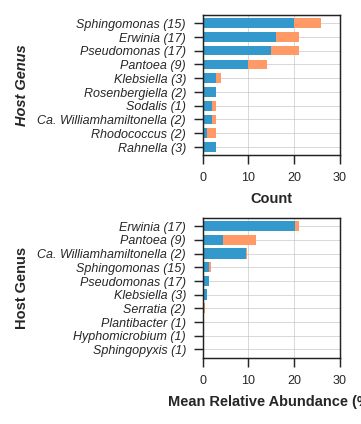

In [48]:
host_df=metadata_df_high_active_phyllosphere[desired_ranks + ["BACPLHIP_lifestyle"]]
# host_df=phyllosphere_active_metadata[desired_ranks + ["BACPLHIP_lifestyle"]]

host_df["mean_relative"]=metadata_df_high_active_phyllosphere[SAMPLES].T.mean()
# host_df["mean_relative"]=phyllosphere_active_metadata[SAMPLES].T.mean()


cluster_df=host_df.merge(vcontact_VC_exploded_df,left_index=True,right_index=True, how="left")
mask = cluster_df["VC"].isna()
cluster_df.loc[mask, "VC"] = [f"unclustered_{i}" for i in range(1, mask.sum() + 1)]

cluster_df.groupby(["VC"]).first().groupby(['genus']).size().to_frame()#.unstack(fill_value=0).drop("N/A")
cluster_sizes = (
    cluster_df.groupby("VC").first()     # one representative genome per VC
    .groupby("genus").size()             # count number of clusters per genus
)


grouped_df = host_df.groupby(['genus', 'BACPLHIP_lifestyle']).size().unstack(fill_value=0).drop("N/A")
# Add cluster counts to genus labels
grouped_df.index = [
    f"{genus.replace('Candidatus ', 'Ca. ')} ({cluster_sizes.get(genus, 0)})"
    for genus in grouped_df.index
]

genus_counts = grouped_df.sum(axis=1)

# Create figure and subplots
fig, (ax1, ax2) = plt.subplots(nrows=2, figsize=(170 * points_to_inches, 200 * points_to_inches))

# Plot genus counts
grouped_df_sorted = grouped_df.loc[genus_counts.sort_values(ascending=False).index]
grouped_df_sorted = grouped_df_sorted[:10]
grouped_df_sorted = grouped_df_sorted.iloc[::-1]
# Draw count plot
grouped_df_sorted.plot(
    kind='barh',
    stacked=True,
    edgecolor='none',
    color=palette_lifestyle,
    ax=ax1,
	width=0.7
)

ax1.set_ylabel('Host Genus', fontstyle='italic')
ax1.set_xlabel('Count')
ax1.set_xlim(0,30)
for label in ax1.get_yticklabels():
    label.set_fontstyle('italic')

# Remove first legend
ax1.get_legend().set_visible(False)

# Plot mean relative abundance
grouped_df_abundance = host_df.groupby(['genus', 'BACPLHIP_lifestyle'])[["mean_relative"]].sum().unstack(fill_value=0).drop("N/A")
grouped_df_abundance.index = [
    f"{genus.replace('Candidatus ', 'Ca. ')} ({cluster_sizes.get(genus, 0)})"
    for genus in grouped_df_abundance.index
]

# Sort by total count
genus_counts_abundance = grouped_df_abundance.sum(axis=1)
grouped_df_sorted_abundance = grouped_df_abundance.loc[genus_counts_abundance.sort_values(ascending=False).index]
grouped_df_sorted_abundance = grouped_df_sorted_abundance[:10]
grouped_df_sorted_abundance = grouped_df_sorted_abundance.iloc[::-1]

grouped_df_sorted_abundance.columns=grouped_df_sorted_abundance.columns.get_level_values(level=1)
# Draw abundance plot
grouped_df_sorted_abundance.plot(
    kind='barh',
    stacked=True,
    edgecolor='none',
    color=palette_lifestyle,
    ax=ax2,
	width=0.75
)

ax2.set_ylabel('Host Genus')
ax2.set_xlabel('Mean Relative Abundance (%)')
ax2.set_xlim(0,30)
for label in ax2.get_yticklabels():
    label.set_fontstyle('italic')

# Remove second legend
ax2.get_legend().set_visible(False)


# Save figure
plt.savefig("/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/FIGURES_AND_TABLES/4a_combined_lifestyle_host.svg")

plt.tight_layout()
# Display the plot
plt.show()


In [49]:
grouped_df_abundance = host_df.groupby(['genus', 'BACPLHIP_lifestyle'])[["mean_relative"]].sum().unstack(fill_value=0).drop("N/A")
grouped_df_abundance

mean_relative          
BACPLHIP_lifestyle                 Temperate  Virulent
genus                                                 
Agrobacterium                       0.013409  0.000000
Aureimonas                          0.044437  0.000000
Brevundimonas                       0.020226  0.000000
Candidatus Williamhamiltonella      9.551181  0.086998
Clavibacter                         0.103602  0.000000
Collimonas                          0.000000  0.042304
Curtobacterium                      0.034807  0.000000
Duganella                           0.000000  0.193197
Enterococcus                        0.161662  0.000000
Erwinia                            20.291313  0.736566
Escherichia                         0.000000  0.159993
Frigoribacterium                    0.000000  0.067941
Hafnia                              0.028912  0.000000
Hymenobacter                        0.168603  0.062381
Hyphomicrobium                      0.000000  0.283956
Klebsiella                          0.875035  0.041566
Leclercia                           0.066041  0.000000
Methylobacterium                    0.011319  0.000000
Microbacterium                      0.107118  0.000000
Mycobacterium                       0.000000  0.038867
Nocardia                            0.000000  0.007735
Pantoea                             4.410756  7.362125
Plantibacter                        0.320336  0.000000
Providencia                         0.103022  0.000000
Pseudomonas                         1.294436  0.145310
Rahnella                            0.232145  0.000000
Rathayibacter                       0.071349  0.000000
Rhodococcus                         0.017735  0.103997
Rosenbergiella                      0.114939  0.000000
Serratia                            0.003869  0.492993
Sodalis                             0.089153  0.006767
Sphingomonas                        1.487491  0.387057
Sphingopyxis                        0.250869  0.000000
Telluria                            0.007911  0.000000
Variovorax                          0.044556  0.071472
Vibrio                              0.000000  0.012470

### 4b. Concordance of Presence-Absence and Abundance-Based Distance Metrics


In [50]:
bacterial_relative_species_sample_df=pd.read_csv("/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/FIGURES_AND_TABLES/bacterial_" + "species"  + "_relative.csv").set_index("species")


viral_samples = flatten_sample_dict(viral_group_samples_dict)
bacterial_samples = flatten_sample_dict(bacterial_group_samples_dict)

matched_samples_df = matched_sample_pairs(viral_samples, bacterial_samples)

matched_viral_samples = matched_samples_df["viral_sample"].tolist()
matched_bacterial_samples = matched_samples_df["bacterial_sample"].tolist()
matched_ids = matched_samples_df["match_id"].tolist()


viral_votu_matched_df = relative_norm_df[matched_viral_samples].copy()
bacterial_strain_matched_df = bacterial_relative_species_sample_df[matched_bacterial_samples].copy()

viral_votu_matched_df.columns = matched_ids
bacterial_strain_matched_df.columns = matched_ids

viral_hellinger_distance_matrix = hellinger_distance_matrix(viral_votu_matched_df)
viral_jaccard_distance_matrix = jaccard_distance_matrix(viral_votu_matched_df)

bacterial_hellinger_distance_matrix = hellinger_distance_matrix(bacterial_strain_matched_df)
bacterial_jaccard_distance_matrix = jaccard_distance_matrix(bacterial_strain_matched_df)

viral_hellinger_distance_matrix


,F1A,F1B,F1C,F2A,F2B,F2C,F3A,F3B,F3C,FL,...,S1C,S2B,S2C,S3B,S3C,SEd,SWd,Z1,Z2,Z3
F1A,0.000000,0.734209,0.774970,0.709974,0.706963,0.791778,0.854113,0.723146,0.828554,0.767949,...,0.990882,0.837825,0.882822,0.804567,0.875254,0.993441,0.966621,0.788236,0.736446,0.636097
F1B,0.734209,0.000000,0.776425,0.812891,0.807697,0.795003,0.851250,0.796375,0.829660,0.856086,...,0.987956,0.822468,0.851120,0.762974,0.867162,0.981027,0.972945,0.804075,0.761193,0.740597
F1C,0.774970,0.776425,0.000000,0.793083,0.811070,0.729854,0.552506,0.813798,0.592648,0.861688,...,0.978732,0.719712,0.584821,0.539923,0.648280,0.991630,0.982874,0.613600,0.690055,0.638198
F2A,0.709974,0.812891,0.793083,0.000000,0.803885,0.831941,0.832989,0.820080,0.817594,0.864116,...,0.965577,0.852312,0.858253,0.814154,0.871357,0.995571,0.977556,0.807449,0.785486,0.758327
F2B,0.706963,0.807697,0.811070,0.803885,0.000000,0.856051,0.828572,0.605851,0.664352,0.873619,...,0.946803,0.875462,0.897483,0.843803,0.911194,0.995476,0.976413,0.822892,0.820212,0.770620
F2C,0.791778,0.795003,0.729854,0.831941,0.856051,0.000000,0.840300,0.842539,0.798223,0.869342,...,0.981993,0.753659,0.775479,0.700468,0.833484,0.990553,0.982176,0.754367,0.703699,0.744319
F3A,0.854113,0.851250,0.552506,0.832989,0.828572,0.840300,0.000000,0.888289,0.712131,0.940680,...,0.990008,0.773965,0.650982,0.641485,0.797388,0.999003,0.993769,0.581599,0.739252,0.679012
F3B,0.723146,0.796375,0.813798,0.820080,0.605851,0.842539,0.888289,0.000000,0.738720,0.856107,...,0.990458,0.871259,0.899329,0.863432,0.906275,0.988170,0.974399,0.874290,0.850102,0.819522
F3C,0.828554,0.829660,0.592648,0.817594,0.664352,0.798223,0.712131,0.738720,0.000000,0.907059,...,0.980975,0.798338,0.684396,0.647158,0.728713,0.990482,0.985132,0.743446,0.764073,0.719407
FL,0.767949,0.856086,0.861688,0.864116,0.873619,0.869342,0.940680,0.856107,0.907059,0.000000,...,0.993899,0.810601,0.883509,0.837950,0.910156,0.978303,0.972007,0.881485,0.855187,0.841169


35


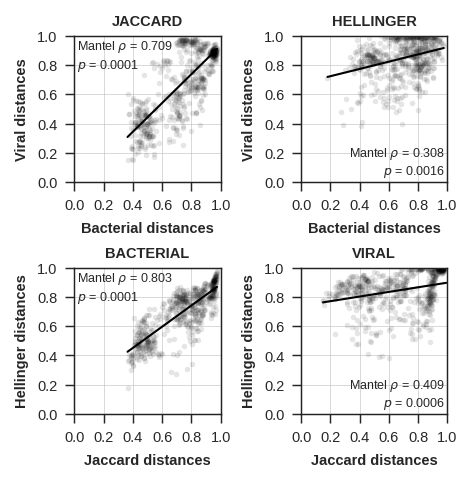

In [88]:
# Make sure all distance matrices use the same matched sample order
common_ids = (
    viral_hellinger_distance_matrix.index
    .intersection(viral_jaccard_distance_matrix.index)
    .intersection(bacterial_hellinger_distance_matrix.index)
    .intersection(bacterial_jaccard_distance_matrix.index)
)
print(len(common_ids))
viral_hellinger_distance_matrix = viral_hellinger_distance_matrix.loc[common_ids, common_ids]
viral_jaccard_distance_matrix = viral_jaccard_distance_matrix.loc[common_ids, common_ids]
bacterial_hellinger_distance_matrix = bacterial_hellinger_distance_matrix.loc[common_ids, common_ids]
bacterial_jaccard_distance_matrix = bacterial_jaccard_distance_matrix.loc[common_ids, common_ids]

# Build plotting vectors
x_jac = upper_triangle_vector(bacterial_jaccard_distance_matrix)
y_jac = upper_triangle_vector(viral_jaccard_distance_matrix)

x_hel = upper_triangle_vector(bacterial_hellinger_distance_matrix)
y_hel = upper_triangle_vector(viral_hellinger_distance_matrix)

xb = upper_triangle_vector(bacterial_jaccard_distance_matrix)
yb = upper_triangle_vector(bacterial_hellinger_distance_matrix)

xv = upper_triangle_vector(viral_jaccard_distance_matrix)
yv = upper_triangle_vector(viral_hellinger_distance_matrix)

# Mantel-style permutation tests
mantel_jac_r, mantel_jac_p = run_mantel_if_possible(
    bacterial_jaccard_distance_matrix,
    viral_jaccard_distance_matrix,
)

mantel_hel_r, mantel_hel_p = run_mantel_if_possible(
    bacterial_hellinger_distance_matrix,
    viral_hellinger_distance_matrix,
)

mantel_bact_r, mantel_bact_p = run_mantel_if_possible(
    bacterial_jaccard_distance_matrix,
    bacterial_hellinger_distance_matrix,
)

mantel_viral_r, mantel_viral_p = run_mantel_if_possible(
    viral_jaccard_distance_matrix,
    viral_hellinger_distance_matrix,
)

# Plot
fig_width, fig_height = 3.1, 3.3
fig, axes = plt.subplots(2, 2, figsize=(fig_width, fig_height), sharex=True, sharey=True)

plot_scatter_with_fit(
    axes[0, 0], x_jac, y_jac,
    title="JACCARD",
    xlabel="Bacterial distances",
    ylabel="Viral distances",
    mantel_r=mantel_jac_r,
    mantel_p=mantel_jac_p,
)

plot_scatter_with_fit(
    axes[0, 1], x_hel, y_hel,
    title="HELLINGER",
    xlabel="Bacterial distances",
    ylabel="Viral distances",
    mantel_r=mantel_hel_r,
    mantel_p=mantel_hel_p,
)

plot_scatter_with_fit(
    axes[1, 0], xb, yb,
    title="BACTERIAL",
    xlabel="Jaccard distances",
    ylabel="Hellinger distances",
    mantel_r=mantel_bact_r,
    mantel_p=mantel_bact_p,
)

plot_scatter_with_fit(
    axes[1, 1], xv, yv,
    title="VIRAL",
    xlabel="Jaccard distances",
    ylabel="Hellinger distances",
    mantel_r=mantel_viral_r,
    mantel_p=mantel_viral_p,
)

for ax in [axes[0, 1], axes[1, 1]]:
    if ax.texts:
        ax.texts[0].set_position((0.98, 0.02))
        ax.texts[0].set_ha("right")
        ax.texts[0].set_va("bottom")

for ax in axes.flat:
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xticks(np.arange(0, 1.01, 0.2))
    ax.set_yticks(np.arange(0, 1.01, 0.2))
    ax.tick_params(labelbottom=True, labelleft=True, labelsize=7)

plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.savefig("/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/FIGURES_AND_TABLES/4b_distance_concordance_2x2.svg", bbox_inches="tight")

plt.show()


## Supplementary and Exploratory Analyses


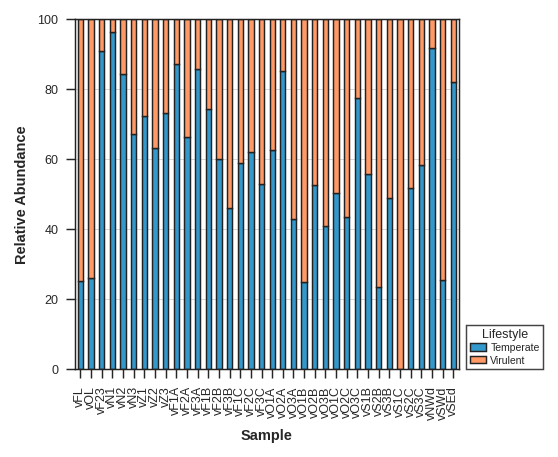

In [52]:
active_phyllosphere_df = phyllosphere_active_metadata.copy()

# Sum abundance by lifestyle
abundance_by_lifestyle = pd.DataFrame(index=["Temperate", "Virulent"], columns=SAMPLES)

for sample in SAMPLES:
    total_abundance = active_phyllosphere_df[sample].sum()
    temp_sum = (active_phyllosphere_df.loc[active_phyllosphere_df["BACPLHIP_lifestyle"] == "Temperate", sample].sum() / total_abundance * 100) if total_abundance > 0 else pd.NA
    vir_sum = (active_phyllosphere_df.loc[active_phyllosphere_df["BACPLHIP_lifestyle"] == "Virulent", sample].sum() / total_abundance * 100) if total_abundance > 0 else pd.NA
    abundance_by_lifestyle[sample] = [temp_sum, vir_sum]

# Plot stacked bars
abundance_by_lifestyle.T.plot(
    kind="bar",
    stacked=True,
    figsize=(4.5,3),
    color=[palette_lifestyle["Temperate"], palette_lifestyle["Virulent"]]
)

plt.ylabel("Relative Abundance")
plt.xlabel("Sample")
plt.ylim(0,100)
plt.legend(title="Lifestyle", loc='lower left', bbox_to_anchor=(1.02, 0), borderaxespad=0)
tight_layout_with_legend()
plt.show()


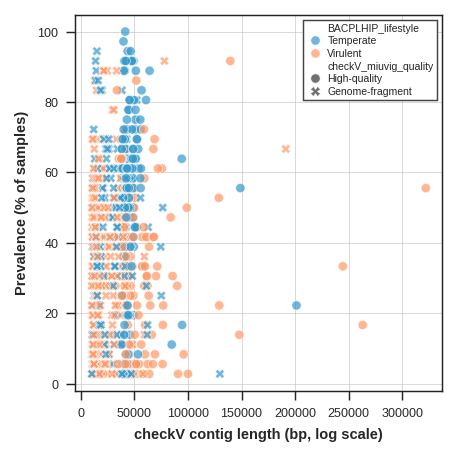

In [53]:
plot_df = phyllosphere_active_metadata.copy()
plot_df = plot_df[plot_df["BACPLHIP_lifestyle"].isin(["Temperate", "Virulent"])].copy()

# Ensure prevalence is a percentage
presence_df = plot_df[SAMPLES] > 0
presence_df = presence_df.astype(int)
plot_df["prevalence"] = presence_df.sum(axis=1) / len(SAMPLES) * 100

plt.figure(figsize=(3, 3))

sns.scatterplot(
    data=plot_df,
    x="checkV_contig_length",
    y="prevalence",
    hue="BACPLHIP_lifestyle",
    style="checkV_miuvig_quality",
    palette={k: palette_lifestyle[k] for k in ["Temperate", "Virulent"]},
    s=20,
    alpha=0.7
)

# plt.xscale("log")
plt.xlabel("checkV contig length (bp, log scale)")
plt.ylabel("Prevalence (% of samples)")
plt.tight_layout()
plt.show()


In [54]:
vOTU_metadata = metadata_df[(metadata_df["COMPARISON"] == "TRUE")].copy()
vOTU_metadata = vOTU_metadata.sort_values("mean_rpkm_full", ascending=False).reset_index()
vOTU_metadata["Prophage_isolate_name"] = vOTU_metadata["widespread_name"].where(
    vOTU_metadata["widespread_name"].ne("N/A"), ""
)
vOTU_metadata["contig_assembly_name"] = vOTU_metadata["vOTU_name"]
vOTU_metadata = vOTU_metadata.rename(columns={"vOTU_number": "vOTU_name"})
vOTU_metadata[["vOTU_name", "Prophage_isolate_name", "contig_assembly_name", "checkV_contig_length", "VirSorter2_positive", "VIBRANT_positive", "geNomad_viral", "geNomad_viral_conservative", "VIBRANT_circular", "VIBRANT_lifecycle", "VIBRANT_quality", "VIBRANT_total_genes", "VIBRANT_all_KEGG", "VIBRANT_KEGG_v-score", "VIBRANT_all_Pfam", "VIBRANT_Pfam_v-score", "VIBRANT_all_VOG", "VIBRANT_VOG_v-score", "VIBRANT_KEGG_int-rep", "VIBRANT_KEGG_zero", "VIBRANT_Pfam_int-rep", "VIBRANT_Pfam_zero", "VIBRANT_VOG_redoxin", "VIBRANT_VOG_rec-tran", "VIBRANT_VOG_int", "VIBRANT_VOG_RnR", "VIBRANT_VOG_DNA", "VIBRANT_KEGG_restriction_check", "VIBRANT_KEGG_toxin_check", "VIBRANT_VOG_special", "VIBRANT_annotation_check", "VIBRANT_p_v_check", "VIBRANT_p_k_check", "VIBRANT_k_v_check", "VIBRANT_k_check", "VIBRANT_p_check", "VIBRANT_v_check", "VIBRANT_h_check", "VirSorter2_dsDNAphage", "VirSorter2_NCLDV", "VirSorter2_RNA", "VirSorter2_ssDNA", "VirSorter2_lavidaviridae", "VirSorter2_max_score", "VirSorter2_max_score_group", "VirSorter2_length", "VirSorter2_hallmark", "VirSorter2_viral", "VirSorter2_cellular", "geNomad_length", "geNomad_topology", "geNomad_coordinates", "geNomad_n_genes", "geNomad_genetic_code", "geNomad_virus_score", "geNomad_fdr", "geNomad_n_hallmarks", "geNomad_marker_enrichment", "geNomad_taxonomy", "checkV_provirus", "checkV_proviral_length", "checkV_gene_count", "checkV_viral_genes", "checkV_host_genes", "checkv_quality", "checkV_miuvig_quality", "checkV_completeness", "checkV_completeness_method", "checkV_contamination", "checkV_kmer_freq", "checkV_warnings", "Virulent", "Temperate", "BACPLHIP_lifestyle", "seq_length", "#A", "#C", "#G", "#T", "#2", "#3", "#4", "#CpG", "#tv", "#ts", "#CpG-ts", "idx", "PhaGCN_family", "score", "sseqid", "salltitles", "qstart", "qend", "qlen", "slen", "qcovs", "evalue", "length", "pident", "index", "AAI to closest RaFAH reference", "Confidence score", "List of methods", "domain", "phylum", "class", "order", "family", "genus", "GC", "mean_rpkm", "mean_rpkm_full", "max_rpkm", "max_rpkm_full", "max_relative", "mean_relative", "mean_relative_full"]].replace("N/A", "").to_csv("/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/vOTU_metadata_phyllosphere.csv", index=False)
metadata_df[(metadata_df["COMPARISON"]=="TRUE")].index.to_frame().to_csv("/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/vOTU_7958_list.csv", index=False, header=False)


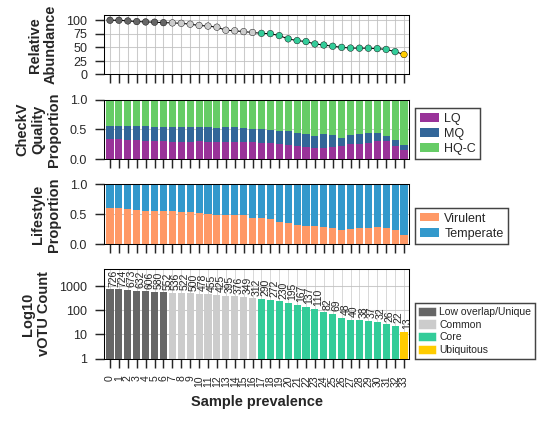

In [55]:

# Build plotting table
merged_df = summary_prevalence_df.rename(columns={
    "cummulative_relative_abundance": "sample_relative_cummulative",
    "proportion_low_quality_not_determined": "proportion_lq_nd",
    "proportion_medium_quality": "proportion_mq",
    "proportion_high_quality_complete": "proportion_hq_complete",
    "proportion_virulent": "proportion_v",
    "proportion_temperate": "proportion_t",
    "log_cumulative_counts": "log_sample_count_cummulative",
    "sample_count_cumulative": "sample_count_cummulative"
}).copy()

# Fill NaN values before plotting
merged_df = merged_df.fillna(0)

# Create four stacked panels
fig, (ax0, ax1, ax2, ax3) = plt.subplots(
    4,
    1,
    figsize=(320 * points_to_inches, 200 * points_to_inches),
    sharex=True,
    gridspec_kw={'height_ratios': [1, 1, 1, 1.5]}  # Fourth plot larger
)

# Apply black panel borders
for ax in [ax0, ax1, ax2, ax3]:
    for spine in ax.spines.values():
        spine.set_edgecolor("black")
        spine.set_linewidth(0.5)

# Plot abundance curve
# Draw black connector line
ax0.plot(
    merged_df["sample_count"],
    merged_df["sample_relative_cummulative"],
    color="black", linestyle='-', linewidth=0.5, zorder=1
)

# Color points by type
ax0.scatter(
    merged_df["sample_count"],
    merged_df["sample_relative_cummulative"],
    c=merged_df["type"],
    s=10,  # marker size
    edgecolor='black',
    linewidth=0.2,
    zorder=2
)

# Format axes
ax0.set_ylabel("Relative\nAbundance")
ax0.set_ylim(0, 110)
ax0.set_yticks([0, 25, 50, 75, 100])
ax0.grid(True, linewidth=0.5)

# Plot quality proportions
ax1.bar(
    merged_df["sample_count"],
    merged_df["proportion_lq_nd"],
    label='LQ', color='#993399', width=0.8, edgecolor='none'
)
ax1.bar(
    merged_df["sample_count"],
    merged_df["proportion_mq"],
    bottom=merged_df["proportion_lq_nd"],
    label='MQ', color='#336699', width=0.8, edgecolor='none'
)
ax1.bar(
    merged_df["sample_count"],
    merged_df["proportion_hq_complete"],
    bottom=merged_df["proportion_lq_nd"] + merged_df["proportion_mq"],
    label='HQ-C', color='#66CC66', width=0.8, edgecolor='none'
)

ax1.set_ylabel("CheckV\nQuality\nProportion")
ax1.legend(fontsize=6, bbox_to_anchor=(1.02, 0), loc='lower left', borderaxespad=0)
ax1.set_ylim(0, 1)
ax1.grid(True, linewidth=0.5)

# Plot lifestyle proportions
ax2.bar(
    merged_df["sample_count"],
    merged_df["proportion_v"],
    label='Virulent', color=palette_lifestyle["Virulent"], width=0.8, edgecolor='none'
)
ax2.bar(
    merged_df["sample_count"],
    merged_df["proportion_t"],
    bottom=merged_df["proportion_v"],
    label='Temperate', color=palette_lifestyle["Temperate"], width=0.8, edgecolor='none'
)

ax2.set_ylabel("Lifestyle\nProportion")
ax2.legend(fontsize=6, bbox_to_anchor=(1.02, 0), loc='lower left', borderaxespad=0)
ax2.set_ylim(0, 1)
ax2.grid(True, linewidth=0.5)

# Plot cumulative counts
ax3.bar(
    merged_df["sample_count"],
    merged_df["log_sample_count_cummulative"],
    color=merged_df["type"],
    width=0.8,
    edgecolor='none'
)

# Label bars with raw counts
for i, p in enumerate(ax3.patches):
    if i < len(merged_df):
        original_value = merged_df.loc[i, "sample_count_cummulative"]
        ax3.annotate(
            int(original_value),
            (p.get_x() + 0.25, p.get_height() + 0.2),
            rotation=90,
            fontsize=5
        )

# Format y axis
ax3.yaxis.set_major_locator(MultipleLocator(1))
ax3.yaxis.grid(True, which='major', linewidth=0.5)

ax3.set_ylabel("Log10\nvOTU Count")
ax3.set_xlabel("Sample prevalence")
ax3.set_yticks([0, 1, 2, 3])
ax3.set_yticklabels([1, 10, 100, 1000,])
ax3.set_ylim(0,3.7)

ax0.set_xlim(merged_df["sample_count"].min() - 0.7, merged_df["sample_count"].max() + 0.6)

# Build custom legend
blue_patch = mpatches.Patch(color='#666666', label='Low overlap/Unique')
gray_patch = mpatches.Patch(color='#CCCCCC', label='Common')
red_patch = mpatches.Patch(color='#33CC99', label='Core')
green_patch = mpatches.Patch(color="#FFCC00", label='Ubiquitous')

ax3.legend(
    handles=[blue_patch, gray_patch, red_patch, green_patch],
    fontsize=5,
    bbox_to_anchor=(1.02, 0),
    loc='lower left',
    borderaxespad=0
)

xticks = merged_df["sample_count"]
ax3.set_xticks(xticks)
ax3.set_xticklabels(xticks, rotation=90, fontsize=5)
# Finalize layout and save
tight_layout_with_legend(fig)
fig.savefig(
    "/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/FIGURES_AND_TABLES/2a_core_abundant_phages_with_quality_lifestyle.svg",
    format="svg"
)
plt.show()


In [56]:
len_df=pd.read_csv("/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/05_vOTUs/checkV_merged_quality_summary.tot.txt",sep="\t", header=None)[[0,1]]
len_df.columns=["ident", "len"]
len_df=len_df.set_index("ident")

clusters_df=pd.read_csv("/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/05_vOTUs/new_references_clusters.tot.csv",sep="\t")
clusters_df_vOTUs=clusters_df[clusters_df["rep"].isin(metadata_df.index.to_list())]

clusters_df_vOTUs=clusters_df_vOTUs.merge(len_df, left_on="rep", right_index=True, how="left")#.drop("vOTU", axis=1)
clusters_df_vOTUs=clusters_df_vOTUs.merge(len_df, left_on="mem_d", right_index=True, how="left")#.drop("vOTU", axis=1)
clusters_df_vOTUs.columns=["rep", "mem_d", "len_rep", "len_mem_d"]
clusters_df_vOTUs_prophages=clusters_df_vOTUs[(~clusters_df_vOTUs["rep"].str.contains("_NODE_")) & (~clusters_df_vOTUs["rep"].str.contains("APSE"))]#.groupby("rep").first()
clusters_df_vOTUs_prophages_clust_NODES=clusters_df_vOTUs_prophages[(clusters_df_vOTUs_prophages["mem_d"].str.contains("_NODE_"))]#.groupby("rep").first()
clusters_df_vOTUs_prophages_clust_NODES.sort_values("len_mem_d").groupby("rep").last()



,mem_d,len_rep,len_mem_d
rep,,,
E_aphidicola_B01_10_pp1_cluster_1,vO2B_40_NODE_73_length_40791_cov_107.257880,40535,40791
E_aphidicola_B01_5_pp1_cluster_3,vF2aA_T_NODE_5_length_44435_cov_19.044322,46453,44435
E_aphidicola_B01_5_pp3_cluster_2,vZ2_T_50_NODE_3_length_20186_cov_31.933386,41005,20186
E_aphidicola_B03_6_pp2_cluster_7,vF2A_NODE_78_length_31246_cov_10.800167,31626,31246
E_aphidicola_N2_1_pp1_cluster_13,vF1C_30_NODE_43_length_86456_cov_117.101689,40010,86456
E_aphidicola_N2_3_pp2_cluster_14,vS2B_70_NODE_207_length_31500_cov_14.121355,31405,31500
E_aphidicola_W04_1_pp2_cluster_8,vF3A_50_NODE_16_length_43253_cov_112.837492,48079,43253
E_aphidicola_W06_8_pp1_cluster_9,vS1B_60_NODE_186_length_32123_cov_72.213234,16026,32123
E_aphidicola_W09_2_pp1_cluster_11,vF1aB_60_NODE_447_length_12328_cov_81.232787,47422,12328


In [57]:
clusters_df_vOTUs_prophages

,rep,mem_d,len_rep,len_mem_d
2367,E_aphidicola_W06_8_pp1_cluster_9,vF2A_80_NODE_1583_length_3087_cov_8.393140,16026,3087
2368,E_aphidicola_W06_8_pp1_cluster_9,vF2A_50_NODE_1328_length_2961_cov_5.762560,16026,2961
2369,E_aphidicola_W06_8_pp1_cluster_9,vF2A_60_NODE_1459_length_2961_cov_7.310736,16026,2961
2370,E_aphidicola_W06_8_pp1_cluster_9,vF2A_70_NODE_1550_length_2961_cov_7.935650,16026,2961
2371,E_aphidicola_W06_8_pp1_cluster_9,vF2A_90_NODE_1701_length_3087_cov_9.673483,16026,3087
...,...,...,...,...
1872069,E_aphidicola_N2_1_pp1_cluster_13,vO2B_20_NODE_981_length_5616_cov_140.005395,40010,5616
1872070,E_aphidicola_N2_1_pp1_cluster_13,vO2B_30_NODE_1302_length_5616_cov_143.267578,40010,5616
1872154,P_trivialis_B08_3_pp2_cluster_28,vO2B_20_NODE_2949_length_2721_cov_7.557764,33988,2721
1872527,E_aphidicola_N2_1_pp1_cluster_13,vO2B_30_NODE_1876_length_4404_cov_30.932858,40010,4404


In [58]:
bacterial_relative_genus_sample_df=pd.read_csv("/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/FIGURES_AND_TABLES/bacterial_" + "genus"  + "_relative.csv").set_index("genus")
bacterial_relative_genus_sample_df

,bNWd,bSEd,bSWd,bFL,bOL,bN1,bN2,bN3,bZ1,bZ2,...,bF3B,bF1C,bF2C,bF3C,bS1B,bS2B,bS3B,bS1C,bS2C,bS3C
genus,,,,,,,,,,,,,,,,,,,,,
Achromobacter,0.000000,0.000000,0.000000,0.041433,0.000000,0.0,0.0,0.0,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0
Acidovorax,0.000000,0.000000,0.000000,0.000000,0.006253,0.0,0.0,0.0,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0
Acinetobacter,0.008680,0.000000,0.000000,0.684820,0.000000,0.0,0.0,0.0,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0
Aeromicrobium,0.016235,0.005545,0.013003,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,...,0.009632,0.006551,0.014421,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0
Agreia,0.000000,0.000000,0.000000,0.047642,0.020567,0.0,0.0,0.0,0.0,0.000000,...,0.730080,0.369156,0.474854,0.712103,0.0,0.0,0.0,0.000000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Williamsia,0.003306,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.072969,...,0.028904,0.008040,0.017469,0.011240,0.0,0.0,0.0,0.000000,0.0,0.0
Winslowiella,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,...,0.140309,0.444350,0.113887,0.601015,0.0,0.0,0.0,0.000000,0.0,0.0
Wolbachia,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,...,0.034211,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0


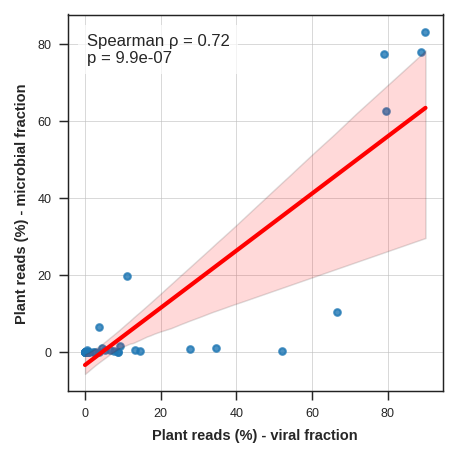

,sample_trimmed,plant_percentage_viral,plant_percentage_microbial
0,F1A,0.521604,0.585169
1,F1B,27.868126,0.852911
2,F1C,0.159885,0.073537
3,F2A,6.715519,0.573169
4,F2B,14.668002,0.354157
5,F2C,1.049571,0.068309
6,F3A,9.262302,1.501920
7,F3B,34.580753,1.180477
8,F3C,0.856265,0.044160
9,FL,7.688664,0.185294


In [59]:
df_counts_paired = pd.read_csv(qc_read_counts, index_col=0)
plant_reads_df=pd.read_csv("/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/02_CLEAN_DATA/plant_assignments.csv", sep=" ", names=["sample", "plant_reads"], index_col=0)
plant_reads_df=plant_reads_df.merge(df_counts_paired, left_index=True, right_on="sample", how="left").set_index("sample")
plant_reads_df["plant_reads_p"]=plant_reads_df["plant_reads"]*100/plant_reads_df["trimmomatic"]
metazoa_reads_df=pd.read_csv("/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/02_CLEAN_DATA/metazoa_assignments.csv", sep=" ", names=["sample", "metazoa_reads"])
eukarya_reads_df=pd.read_csv("/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/02_CLEAN_DATA/eukarya_assignments.csv", sep=" ", names=["sample", "eukarya_reads"])
plant_reads_df=plant_reads_df.merge(metazoa_reads_df, left_index=True, right_on="sample", how="left").set_index("sample").merge(eukarya_reads_df, left_index=True, right_on="sample", how="left").set_index("sample")
plant_reads_df["metazoa_reads_p"]=plant_reads_df["metazoa_reads"]*100/plant_reads_df["trimmomatic"]
microbial_plant_percentage_df= pd.read_csv("/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/plant_percentage_microbial.csv")
microbial_plant_percentage_df=microbial_plant_percentage_df[["Sample", "plant"]]


# Make sure sample is a column in both
plant_reads_df = plant_reads_df.reset_index()

# Remove first character from sample names
plant_reads_df["sample_trimmed"] = plant_reads_df["sample"].str[1:]
microbial_plant_percentage_df["sample_trimmed"] = microbial_plant_percentage_df["Sample"].str[1:]
# Merge on trimmed sample
merged_df = plant_reads_df[["sample_trimmed", "plant_reads_p"]].merge(
    microbial_plant_percentage_df,
    on="sample_trimmed",
    how="inner"  # or "outer" if you want all
).drop("Sample", axis=1)


merged_df = merged_df.rename(
    columns={
        "plant_reads_p": "plant_percentage_viral",
        "plant": "plant_percentage_microbial"
    }
)

plt.figure(figsize=(3,3))

# Scatter + regression line
ax = sns.regplot(
    data=merged_df,
    x="plant_percentage_viral",
    y="plant_percentage_microbial",
    scatter_kws={"s":10, "color": "#1f77b4"},
    line_kws={"color": "red", "lw": 2}
)

# Labels & title
ax.set_xlabel("Plant reads (%) - viral fraction")
ax.set_ylabel("Plant reads (%) - microbial fraction")

rho, pval = spearmanr(
    merged_df["plant_percentage_viral"],
    merged_df["plant_percentage_microbial"],
)

# Annotate Spearman correlation
ax.text(
    0.05, 0.95,
    f"Spearman ρ = {rho:.2f}\np = {pval:.1e}",  # plain decimals, 4 digits
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=8,
    bbox=dict(facecolor="white", alpha=0.7, edgecolor="none",)
)

plt.tight_layout()
plt.show()
merged_df

### Contamination and Non-viral Signal


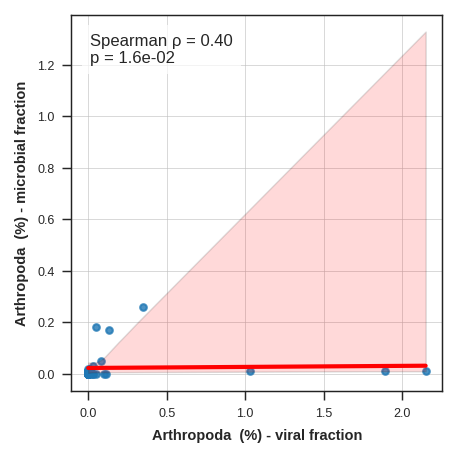

,sample_trimmed,arthropoda_p_viral,arthropoda_p_microbial
0,FL,0.03,0.00
1,OL,0.02,0.00
2,N1,0.00,0.00
3,N2,0.05,0.18
4,N3,0.35,0.26
5,Z1,0.13,0.17
6,Z2,0.08,0.05
7,Z3,0.11,0.00
8,F1A,0.01,0.02
9,F2A,0.01,0.01


In [60]:
# ls *_forward_paired_clean.tot.fastq.gz | sed 's/_forward_paired_clean.tot.fastq.gz//' | parallel -j 8 "/home/lmf/scripts/process_reads_sourmash.sh -1 {}_forward_paired_clean.tot.fastq.gz -2 {}_reverse_paired_clean.tot.fastq.gz -g other -t 16"
# cd /home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/02_CLEAN_DATA/SOURMASH_RESULTS
# cd /home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/02_CLEAN_DATA/SOURMASH_RESULTS
# grep "Arthro" *kreport* | cut -f1 | sed "s/_forward_paired_clean.tot_other_k31_s1000_3000bp_sourmash.kreport.txt:/\t/g" > arthropoda_percentage.txt
# grep "Aphididae" *kreport* | cut -f1 | sed "s/_forward_paired_clean.tot_other_k31_s1000_3000bp_sourmash.kreport.txt:/\t/g" > Aphididae_percentage.txt
# grep "Sitobion avenae" *kreport* | cut -f1 | sed "s/_forward_paired_clean.tot_other_k31_s1000_3000bp_sourmash.kreport.txt:/\t/g" > Sitobion_avenae_percentage.txt
# grep "Rhopalosiphum padi" *kreport* | cut -f1 | sed "s/_forward_paired_clean.tot_other_k31_s1000_3000bp_sourmash.kreport.txt:/\t/g" > Rhopalosiphum_padi_percentage.txt

SAMPLES_no23 = [s for s in SAMPLES if s != "vF23"]

arthropoda_percentage_viral_df=pd.read_csv("/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/02_CLEAN_DATA/SOURMASH_RESULTS/Sitobion_avenae_percentage.txt", sep="\t", names=["sample", "arthropoda_p_viral"])
arthropoda_percentage_viral_df=arthropoda_percentage_viral_df.set_index("sample").reindex(SAMPLES_no23,fill_value=0).reset_index()


arthropoda_percentage_microbial_df=pd.read_csv("/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/02_CLEAN_DATA/SOURMASH_RESULTS/Sitobion_avenae_percentage.txt", sep="\t", names=["sample", "arthropoda_p_microbial"])

# Remove first character from sample names
arthropoda_percentage_viral_df["sample_trimmed"] = arthropoda_percentage_viral_df["sample"].str[1:]
arthropoda_percentage_microbial_df["sample_trimmed"] = arthropoda_percentage_microbial_df["sample"].str[1:]

# Merge on trimmed sample
merged_df = arthropoda_percentage_viral_df[["sample_trimmed", "arthropoda_p_viral"]].merge(
    arthropoda_percentage_microbial_df,
    on="sample_trimmed",
    how="left"  # or "outer" if you want all
).drop("sample", axis=1).fillna(0)


plt.figure(figsize=(3,3))

# Scatter + regression line
ax = sns.regplot(
    data=merged_df,
    x="arthropoda_p_viral",
    y="arthropoda_p_microbial",
    scatter_kws={"s":10, "color": "#1f77b4"},
    line_kws={"color": "red", "lw": 2}
)

# Labels & title
ax.set_xlabel("Arthropoda  (%) - viral fraction")
ax.set_ylabel("Arthropoda  (%) - microbial fraction")

rho, pval = spearmanr(
    merged_df["arthropoda_p_viral"],
    merged_df["arthropoda_p_microbial"],
)

# Annotate Spearman correlation
ax.text(
    0.05, 0.95,
    f"Spearman ρ = {rho:.2f}\np = {pval:.1e}",  # plain decimals, 4 digits
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=8,
    bbox=dict(facecolor="white", alpha=0.7, edgecolor="none",)
)

plt.tight_layout()
plt.show()
merged_df

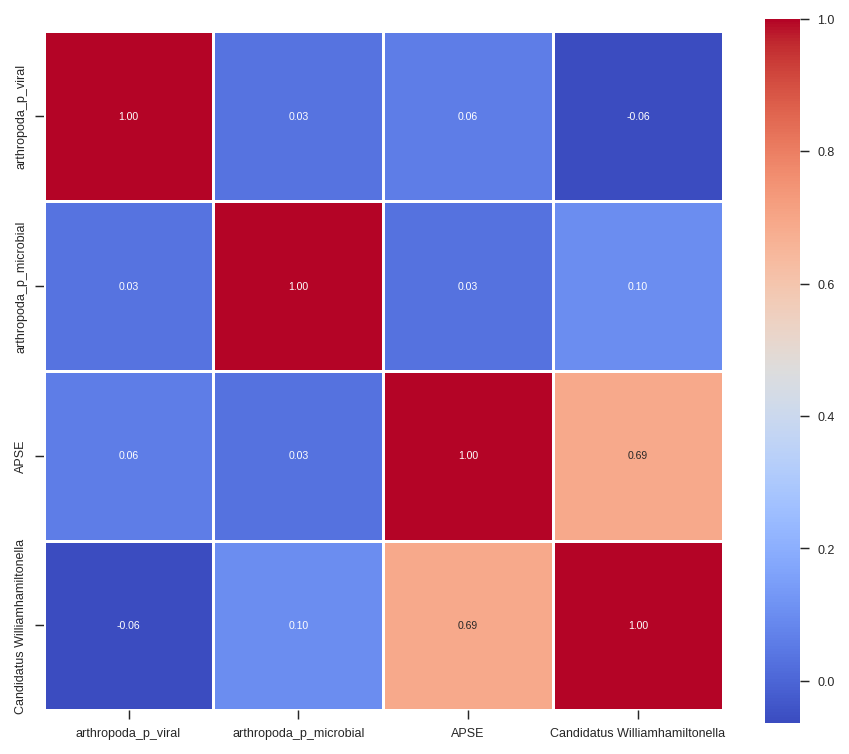

,sample_trimmed,arthropoda_p_viral,arthropoda_p_microbial,APSE,Candidatus Williamhamiltonella
0,FL,0.03,0.00,16.013469,0.013051
1,OL,0.02,0.00,2.041804,0.011972
2,N1,0.00,0.00,80.381425,80.818016
3,N2,0.05,0.18,22.866911,19.692449
4,N3,0.35,0.26,5.202865,4.286079
5,Z1,0.13,0.17,8.816667,6.856126
6,Z2,0.08,0.05,22.281929,4.779823
7,Z3,0.11,0.00,27.643242,1.753667
8,F1A,0.01,0.02,72.266574,11.753347
9,F2A,0.01,0.01,21.341987,8.572107


In [61]:
relative_norm_df_APSE=relative_norm_df.loc[APSE_vOTUs].sum().to_frame().loc[SAMPLES].rename(columns={0: "APSE"})
relative_norm_df_APSE["sample_trimmed"] = relative_norm_df_APSE.index.str[1:]
hamiltonella_abundance_df=bacterial_relative_genus_sample_df.loc["Candidatus Williamhamiltonella"].to_frame()#.loc[SAMPLES]
hamiltonella_abundance_df["sample_trimmed"] = hamiltonella_abundance_df.index.str[1:]
# arthropoda_percentage_viral_df
merged_df_multi=merged_df.merge(relative_norm_df_APSE,left_on="sample_trimmed", right_on="sample_trimmed").merge(hamiltonella_abundance_df,left_on="sample_trimmed", right_on="sample_trimmed")

# Select only the relevant columns for correlation
cols = ['arthropoda_p_viral', 'arthropoda_p_microbial', 'APSE', 'Candidatus Williamhamiltonella']

# Subset and compute correlation matrix
corr = merged_df_multi[cols].corr(method='pearson')

# Create the heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(
    corr,
    annot=True,          # show correlation values
    cmap='coolwarm',     # color map
    fmt=".2f",           # two decimal places
    linewidths=0.5,      # thin borders
    square=True
)
plt.tight_layout()
plt.show()
merged_df_multi

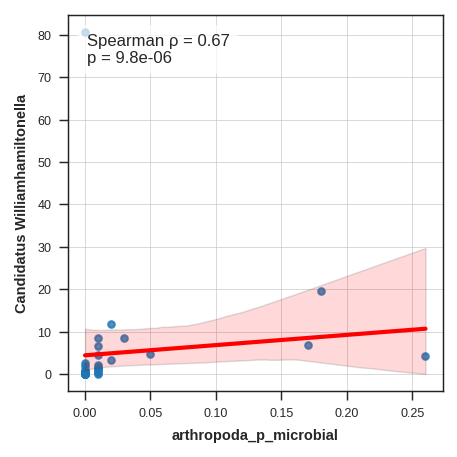

In [62]:

plt.figure(figsize=(3,3))

# Scatter + regression line
ax = sns.regplot(
    data=merged_df_multi,
    x="arthropoda_p_microbial",
    y="Candidatus Williamhamiltonella",
    scatter_kws={"s":10, "color": "#1f77b4"},
    line_kws={"color": "red", "lw": 2}
)

# Labels & title
ax.set_xlabel("arthropoda_p_microbial")
ax.set_ylabel("Candidatus Williamhamiltonella")

rho, pval = spearmanr(
    merged_df_multi["arthropoda_p_microbial"],
    merged_df_multi["Candidatus Williamhamiltonella"],
)

# Annotate Spearman correlation
ax.text(
    0.05, 0.95,
    f"Spearman ρ = {rho:.2f}\np = {pval:.1e}",  # plain decimals, 4 digits
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=8,
    bbox=dict(facecolor="white", alpha=0.7, edgecolor="none",)
)

plt.tight_layout()
plt.show()


In [63]:
# df_counts_paired
print("Phyllovir 1.0 reads", df_counts_paired[df_counts_paired["sample"].isin(["vFL", "vOL","vFL_amp", "vOL_amp"])].set_index("sample")[["raw"]].sum())
print("Phyllovir 2.0 reads", df_counts_paired[~df_counts_paired["sample"].isin(["vFL", "vOL","vFL_amp", "vOL_amp"])].set_index("sample")[["raw"]].sum())

Phyllovir 1.0 reads raw    203851035
dtype: int64
Phyllovir 2.0 reads raw    2506241748
dtype: int64


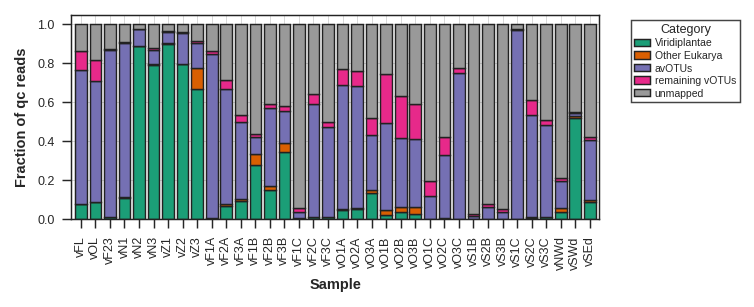

Mean plant contamination: 17.4
Median plant contamination: 4.1
Std plant contamination: 28.1

Mean vOTUs mapping: 52.4
Median vOTUs mapping: 58.6
Std vOTUs mapping: 28.3

Mean avOTUs mapping: 46.6
Median avOTUs mapping: 47.2
Std avOTUs mapping: 27.6


,trimmomatic,bbduk,Viridiplantae,Other Eukarya,vOTUs,avOTUs,remaining vOTUs,unmapped
sample,,,,,,,,
vFL,100.0,92.13,7.69,0.18,78.49,68.78,9.71,13.64
vOL,100.0,91.08,8.77,0.16,72.60,62.16,10.44,18.47
vF23,100.0,99.01,0.94,0.05,86.52,85.83,0.69,12.48
vN1,100.0,88.60,11.03,0.37,79.58,79.14,0.44,9.02
vN2,100.0,11.00,88.70,0.30,8.66,8.32,0.34,2.34
vN3,100.0,20.17,78.95,0.87,8.17,6.95,1.22,12.00
vZ1,100.0,9.58,89.92,0.49,5.97,5.57,0.41,3.61
vZ2,100.0,20.17,79.45,0.37,16.00,15.44,0.55,4.18
vZ3,100.0,22.64,66.63,10.73,13.79,12.91,0.88,8.85


In [64]:
# Load data
mapped_reads_active_df = pd.read_csv(
    "/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/FIGURES_AND_TABLES/mapped_reads_active.csv"
)
plant_reads_df = pd.read_csv(
    "/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/02_CLEAN_DATA/plant_assignments.csv",
    sep=" ", names=["sample", "Viridiplantae"], index_col=0
).merge(df_counts_paired, left_index=True, right_on="sample", how="left").set_index("sample")

# Merge and calculate categories
mapped_reads_active_df = mapped_reads_active_df.merge(plant_reads_df, on="sample")
# mapped_reads_active_df["low_qc"] = mapped_reads_active_df["raw"] - mapped_reads_active_df["trimmomatic"]
mapped_reads_active_df["Other Eukarya"] = mapped_reads_active_df["trimmomatic"] - mapped_reads_active_df["kraken"] - mapped_reads_active_df["Viridiplantae"]
mapped_reads_active_df["avOTUs"] = mapped_reads_active_df["mapped_p"]
mapped_reads_active_df["vOTUs"] = mapped_reads_active_df["mapped_f"]

mapped_reads_active_df["remaining vOTUs"] = mapped_reads_active_df["mapped_f"] - mapped_reads_active_df["mapped_p"]

mapped_reads_active_df["sum"] = mapped_reads_active_df[["Viridiplantae","Other Eukarya","mapped_f"]].sum(axis=1)
mapped_reads_active_df["unmapped"] = mapped_reads_active_df["trimmomatic"] - mapped_reads_active_df["sum"]

# Final view
final_df = mapped_reads_active_df[["sample", "trimmomatic", "bbduk", "Viridiplantae","Other Eukarya","vOTUs", "avOTUs","remaining vOTUs", "unmapped"]].set_index("sample").loc[SAMPLES]

# Make fractions relative to raw
fractions = final_df.div(final_df["trimmomatic"], axis=0)
fractions_clean = final_df.div(final_df["bbduk"], axis=0)

# Order of components in the stack
components = ["Viridiplantae", "Other Eukarya", "avOTUs", "remaining vOTUs", "unmapped"]
colors_dict = {
    "Viridiplantae": "#1b9e77",     # green
    "Other Eukarya": "#d95f02",     # orange
    "avOTUs": "#7570b3",           # purple
    "remaining vOTUs": "#e7298a",   # pink
    "unmapped": "#999999"           # olive green
}

# Plot stacked bar chart with custom colors
ax = fractions[components].plot(
    kind="bar",
    stacked=True,
    figsize=(5, 2),
    color=[colors_dict[c] for c in components],
    width=0.8   # wider bars (default is 0.5–0.7 depending on version)
)

plt.ylabel("Fraction of qc reads")
plt.xlabel("Sample")
plt.legend(
    title="Category",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()


mean_val = fractions["Viridiplantae"].mean()*100
median_val = fractions["Viridiplantae"].median()*100
std_val = fractions["Viridiplantae"].std()*100

print(f"Mean plant contamination: {mean_val:.1f}")
print(f"Median plant contamination: {median_val:.1f}")
print(f"Std plant contamination: {std_val:.1f}")
print()

mean_val = fractions_clean["vOTUs"].mean()*100
median_val = fractions_clean["vOTUs"].median()*100
std_val = fractions_clean["vOTUs"].std()*100

print(f"Mean vOTUs mapping: {mean_val:.1f}")
print(f"Median vOTUs mapping: {median_val:.1f}")
print(f"Std vOTUs mapping: {std_val:.1f}")
print()

mean_val = fractions_clean["avOTUs"].mean()*100
median_val = fractions_clean["avOTUs"].median()*100
std_val = fractions_clean["avOTUs"].std()*100

print(f"Mean avOTUs mapping: {mean_val:.1f}")
print(f"Median avOTUs mapping: {median_val:.1f}")
print(f"Std avOTUs mapping: {std_val:.1f}")

(fractions*100).round(2)

In [65]:
fractions["Viridiplantae"].mean()

np.float64(0.1739846743549213)

### Summary Statistics


### APSE and Length Summaries


In [66]:
APSE_lengths = [36085, 38726, 38559, 40284, 39422, 39445, 38687, 36094, 35191, 33476, 38420, 36931, 41343, 39867, 37264, 36524, 41356, 40108]
average_length_APSE = statistics.mean(APSE_lengths)
average_length_APSE


38210.11111111111

In [67]:
phyllosphere_active_metadata

,count_Y,checkV_contig_length,VirSorter2_positive,VIBRANT_positive,geNomad_viral,geNomad_viral_conservative,VIBRANT_circular,VIBRANT_lifecycle,VIBRANT_quality,VIBRANT_total_genes,...,DENMARK_LEAF,DENMARK_PHYLLOSPHERE,USA_LEAF,INTERESTING,PHYLLOSPHERE,COMPARISON,all_vOTUs,vOTU_number,vOTU_name,vOTU_name_final
vOTU,,,,,,,,,,,,,,,,,,,,,
E_aphidicola_Z9_3_pp3_cluster_15,3,41269,Y,Y,Y,Y,N/A,lysogenic,medium quality draft,50.0,...,TRUE,TRUE,N/A,TRUE,TRUE,TRUE,TRUE,vOTU_0002,E_aphidicola_Z9_3_pp3_cluster_15,Erwinia virus Trolltunga
APSE_wheat,3,41352,Y,Y,Y,Y,N/A,lysogenic,high quality draft,36.0,...,TRUE,TRUE,TRUE,TRUE,TRUE,TRUE,TRUE,vOTU_0001,APSE_wheat,APSE_wheat
vS1B_20_NODE_11_length_139468_cov_83.775100,3,139468,Y,Y,Y,Y,Y,lytic,high quality draft,259.0,...,TRUE,TRUE,N/A,TRUE,TRUE,TRUE,TRUE,vOTU_0006,vS1B_20_NODE_11_length_139468_cov_83.775100,vOTU_0006
vF2A_40_NODE_6_length_51705_cov_107.419361,3,51705,Y,Y,Y,Y,N/A,lytic,medium quality draft,77.0,...,TRUE,TRUE,N/A,TRUE,TRUE,TRUE,TRUE,vOTU_0011,vF2A_40_NODE_6_length_51705_cov_107.419361,vOTU_0011
vSWd_30_NODE_3_length_42737_cov_105.646080,3,42737,Y,Y,Y,Y,N/A,lysogenic,high quality draft,67.0,...,TRUE,TRUE,TRUE,TRUE,TRUE,TRUE,TRUE,vOTU_0010,vSWd_30_NODE_3_length_42737_cov_105.646080,vOTU_0010
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
vO2C_50_NODE_1075_length_12130_cov_22.014493,3,12130,Y,Y,Y,Y,N/A,lytic,low quality draft,16.0,...,TRUE,TRUE,N/A,TRUE,TRUE,TRUE,TRUE,vOTU_4984,vO2C_50_NODE_1075_length_12130_cov_22.014493,vOTU_4984
vF2A_NODE_185_length_17243_cov_19.384571,3,17243,Y,Y,Y,Y,N/A,lytic,low quality draft,23.0,...,TRUE,TRUE,N/A,TRUE,TRUE,TRUE,TRUE,vOTU_4555,vF2A_NODE_185_length_17243_cov_19.384571,vOTU_4555
vF2A_NODE_374_length_10113_cov_7.938457,3,10113,Y,Y,Y,Y,N/A,lysogenic,low quality draft,22.0,...,TRUE,TRUE,N/A,TRUE,TRUE,TRUE,TRUE,vOTU_5685,vF2A_NODE_374_length_10113_cov_7.938457,vOTU_5685


### Metadata Statistics


In [68]:
phyllosphere_metadata_stats = phyllosphere_metadata.copy()

print(fmt_num(phyllosphere_metadata_stats["mean_relative_full"].sum()))


average_length_df_all=phyllosphere_metadata_stats[["checkV_contig_length", "mean_relative_full", "GC","VIBRANT_lifecycle", "checkv_quality",'BACPLHIP_lifestyle', "genus"]]
print("total vOTUs phyllovir 2.0:", len(average_length_df_all))
print("Length all vOTUs phyllovir2.0")
print("mean", fmt_num(average_length_df_all["checkV_contig_length"].mean()))

print("count lifestyle")
print(phyllosphere_metadata_stats["BACPLHIP_lifestyle"].value_counts().to_frame())


print("count per checkv_quality")
print(phyllosphere_metadata_stats["checkv_quality"].value_counts().to_frame())


# average_length_df=phyllosphere_metadata_stats[((phyllosphere_metadata_stats['checkv_quality']=="Complete") | (phyllosphere_metadata_stats['checkv_quality']=="High-quality")) & (phyllosphere_metadata_stats['checkV_warnings'].isna() )][["checkV_contig_length", "mean_relative", "GC", "max_relative"]]
average_length_df=phyllosphere_metadata_stats[((phyllosphere_metadata_stats['checkv_quality']=="Complete") | (phyllosphere_metadata_stats['checkv_quality']=="High-quality")) ][["checkV_contig_length", "mean_relative_full", "GC", "max_relative_full",'BACPLHIP_lifestyle']]
# average_length_df=phyllosphere_metadata_stats[((phyllosphere_metadata_stats['checkv_quality']=="Complete") ) ][["checkV_contig_length", "mean_relative_full", "GC", "max_relative_full",'BACPLHIP_lifestyle']]

# print("high-quality" , len(average_length_df))
# print()

print("complete/high-quality" , len(average_length_df))
print("complete/high-quality Jumbophages(>200kbp)" , len(average_length_df[average_length_df["checkV_contig_length"]>200000]))
print()


average_length_df["ponderate_length"]=average_length_df['checkV_contig_length']*average_length_df['mean_relative_full']
average_length_df["ponderate_GC"]=average_length_df['GC']*average_length_df['mean_relative_full']

average_length_ponderated=average_length_df["ponderate_length"].sum()/average_length_df['mean_relative_full'].sum()
average_GC_ponderated=average_length_df["ponderate_GC"].sum()/average_length_df['mean_relative_full'].sum()

print("Length complete/high-quality ")
print("mean", fmt_num(average_length_df["checkV_contig_length"].mean()))
print("median", fmt_num(average_length_df["checkV_contig_length"].median()))
print("ponderate", fmt_num(average_length_ponderated))
print("min", fmt_num(average_length_df["checkV_contig_length"].min()))
print("max", fmt_num(average_length_df["checkV_contig_length"].max()))
print()

print("GC complete/high-quality")
print("mean", fmt_num(average_length_df["GC"].mean()))
print("ponderate", fmt_num(average_GC_ponderated))
print("min", fmt_num(average_length_df["GC"].min()))
print("max", fmt_num(average_length_df["GC"].max()))
print()


# print("Relative Abundance complete/high-quality")
# relative_full_phyllosphere=relative_norm_df.loc[phyllosphere_active_metadata.index][SAMPLES].T.max()

# print("mean", relative_full_phyllosphere.mean())
# print("min", relative_full_phyllosphere.min())
# print("max", relative_full_phyllosphere.max())

print("count lifestyle")
print(average_length_df["BACPLHIP_lifestyle"].value_counts().to_frame())

print("percentage lifestyle")
print(average_length_df["BACPLHIP_lifestyle"].value_counts().to_frame()/average_length_df["BACPLHIP_lifestyle"].value_counts().sum())
print(fmt_num(len(average_length_df) * 100 / len(phyllosphere_metadata_stats)))

100.0000
total vOTUs phyllovir 2.0: 7958
Length all vOTUs phyllovir2.0
mean 24751.4070
count lifestyle
                    count
BACPLHIP_lifestyle       
Virulent             5569
Temperate            2389
count per checkv_quality
                count
checkv_quality       
Low-quality      5139
Medium-quality   1487
High-quality      837
Complete          374
Not-determined    121
complete/high-quality 1211
complete/high-quality Jumbophages(>200kbp) 13

Length complete/high-quality 
mean 50464.3353
median 44477.0000
ponderate 57592.4672
min 4441.0000
max 354857.0000

GC complete/high-quality
mean 0.5766
ponderate 0.5111
min 0.2301
max 0.7193

count lifestyle
                    count
BACPLHIP_lifestyle       
Temperate             653
Virulent              558
percentage lifestyle
                       count
BACPLHIP_lifestyle          
Temperate           0.539224
Virulent            0.460776
15.2174


In [69]:
hq_complete_metadata = metadata_df[(metadata_df["COMPARISON"] == "TRUE") & metadata_df["checkv_quality"].isin(["Complete", "High-quality"])].copy()
lifestyle_counts = hq_complete_metadata["BACPLHIP_lifestyle"].value_counts()

print(fmt_num(lifestyle_counts.get("Temperate", 0) * 100 / len(hq_complete_metadata)))
print(fmt_num(lifestyle_counts.get("Virulent", 0) * 100 / len(hq_complete_metadata)))


53.9224
46.0776


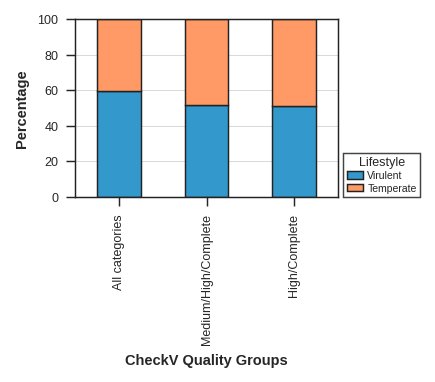

In [70]:


active_phyllosphere_df = phyllosphere_active_metadata.copy()

# groups
all_group = active_phyllosphere_df

medium_plus = active_phyllosphere_df[
    active_phyllosphere_df["checkv_quality"].isin(
        ["Medium-quality", "High-quality", "Complete"]
    )
]

high_plus = active_phyllosphere_df[
    active_phyllosphere_df["checkv_quality"].isin(
        ["High-quality", "Complete"]
    )
]

# compute percentages
p_all = lifestyle_percent(all_group)
p_medium = lifestyle_percent(medium_plus)
p_high = lifestyle_percent(high_plus)

# combine into one dataframe
plot_df = pd.DataFrame({
    "All categories": p_all,
    "Medium/High/Complete": p_medium,
    "High/Complete": p_high
}).T.fillna(0)

# Plot results
ax = plot_df.plot(
    kind="bar",
    stacked=True,
    figsize=(3.5, 2.5),
    color=[palette_lifestyle["Temperate"], palette_lifestyle["Virulent"]],
)

ax.set_ylabel("Percentage")
ax.set_ylim(0, 100)
ax.set_xlabel("CheckV Quality Groups")
plt.legend(title="Lifestyle", loc='lower left', bbox_to_anchor=(1.02, 0), borderaxespad=0)
tight_layout_with_legend()
plt.show()


In [71]:
upset_metadata=metadata_samples[(~metadata_samples["UPSET"].isna()) & (metadata_samples["UPSET"]!="RIZOSPHERE_DK")].reset_index()
grouped_columns = upset_metadata.groupby('UPSET')['SAMPLE'].apply(list).to_dict()

# Aggregate columns by group
result_dict_ubiquitous = {}
result_dict_common = {}
result_dict_core = {}
result_dict_one = {}
for group, columns in grouped_columns.items():
    print(group)
    threshold_ubiquitous = 1 * len(relative_norm_df[columns].T)
    threshold_core = 0.5 * len(relative_norm_df[columns].T)
    threshold_common = 0.2 * len(relative_norm_df[columns].T)
    threshold_one = 1
    result_dict_ubiquitous[group] = (relative_norm_df[columns] > 0).sum(axis=1) >= threshold_ubiquitous
    result_dict_common[group] = (relative_norm_df[columns] > 0).sum(axis=1) >= threshold_common
    result_dict_core[group] = (relative_norm_df[columns] > 0).sum(axis=1) >= threshold_core
    result_dict_one[group] = (relative_norm_df[columns] > 0).sum(axis=1) >= threshold_one

FLAG_DK
FLAG_USA
PENNULTIMATE_DK
SPIKE_DK


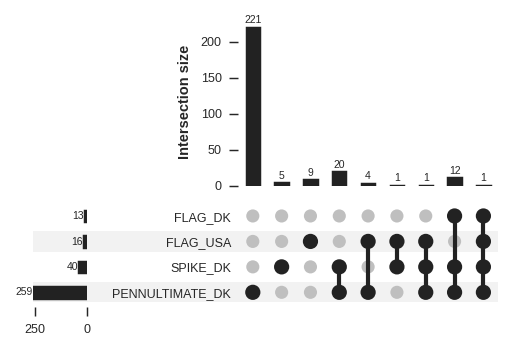

In [72]:
binary_df = pd.DataFrame(result_dict_ubiquitous).astype(bool)
binary_df = binary_df.loc[binary_df.any(axis=1)]

upset_data = from_indicators(binary_df.columns.tolist(), binary_df)
upset = UpSet(
    upset_data,
    subset_size="count",
    show_counts=True,
    element_size=18,
    facecolor="#222222",
    other_dots_color="#BFBFBF",
    shading_color="#F2F2F2",
)

fig = plt.figure(figsize=(2.5, 2))
upset.plot(fig=fig)
style_upset_figure(fig)
fig.savefig("/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/FIGURES_AND_TABLES/SFigure1_upset_ubiquitous.svg")
plt.show()


### Additional Genome Feature Plots


In [73]:
phyllosphere_active_metadata["max_relative"].sort_values()

vOTU
vF3C_60_NODE_234_length_29103_cov_149.607374     0.006259
vO2B_90_NODE_353_length_23302_cov_5.848540        0.01445
vS1C_NODE_4_length_33703_cov_7.680308            0.024925
vF2A_NODE_374_length_10113_cov_7.938457          0.025286
vS1C_NODE_19_length_12051_cov_5.370707           0.029611
                                                  ...    
vSWd_T_20_NODE_1_length_42536_cov_22.322332     66.923365
vO3C_40_NODE_64_length_43208_cov_330.076982       70.4214
E_aphidicola_Z9_3_pp3_cluster_15                75.662856
vZ1_60_NODE_1_length_148906_cov_105.666727      85.636548
vF2B_NODE_17_length_45478_cov_102.889417        99.794634
Name: max_relative, Length: 726, dtype: object

726


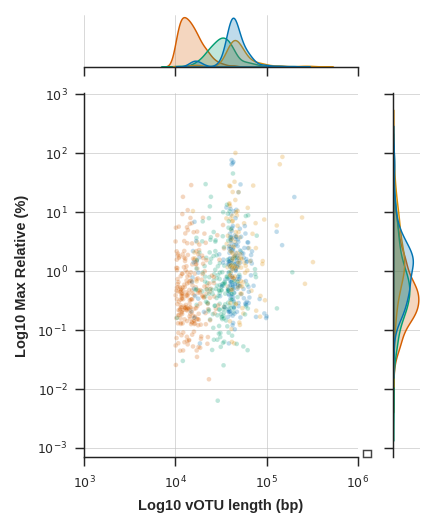

In [74]:
category_colors = ["red", "blue", "green", "orange", "purple"]

phyllosphere_active_metadata["checkV_contig_length_log"]=np.log10(phyllosphere_active_metadata["checkV_contig_length"])
phyllosphere_active_metadata["max_relative"] = pd.to_numeric(
    phyllosphere_active_metadata["max_relative"], errors="coerce"
)
phyllosphere_active_metadata["max_relative_log"]=np.log10(phyllosphere_active_metadata["max_relative"])
# phyllosphere_active_metadata['topology_marker'] = phyllosphere_active_metadata['topology'].apply(lambda x: 'o' if x == 'circular' else 'x')

print(len(phyllosphere_active_metadata))
# Plot the data as a distribution plot
ax = sns.jointplot(data=phyllosphere_active_metadata,x="checkV_contig_length_log",y="max_relative_log", hue="checkv_quality", 
                   s=5, alpha=0.25, legend=False, height=250*points_to_inches,)#,palette=category_colors, marker="o")

# Set x- and y-axis labels
ax.ax_joint.set_xlabel('Log10 vOTU length (bp)')
ax.ax_joint.set_ylabel('Log10 Max Relative (%)')

# ax.ax_joint.set_ylim(-3, 2.1)

# Set the x-ticks and y-ticks to powers of 10
# x-ticks
custom_x_ticks = [3, 4, 5, 6]

ax.ax_joint.set_xticks(custom_x_ticks)
ax.ax_joint.set_xticklabels([r'$10^{{{}}}$'.format(x) for x in custom_x_ticks])

# y-ticks
yticks = ax.ax_joint.get_yticks()
yticklabels = [r'$10^{{{}}}$'.format(int(y)) for y in yticks]
ax.ax_joint.set_yticklabels(yticklabels)

# Set legend
legend = ax.ax_joint.legend(markerscale=1, loc='lower left', bbox_to_anchor=(1.02, 0), borderaxespad=0, labelspacing=0.2, handletextpad=0.01)

tight_layout_with_legend(ax.fig)
plt.savefig("/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/FIGURES_AND_TABLES/max_relative_vs_length.svg")

plt.show()


In [75]:
phyllosphere_active_metadata.groupby("genus").count()

,count_Y,checkV_contig_length,VirSorter2_positive,VIBRANT_positive,geNomad_viral,geNomad_viral_conservative,VIBRANT_circular,VIBRANT_lifecycle,VIBRANT_quality,VIBRANT_total_genes,...,USA_LEAF,INTERESTING,PHYLLOSPHERE,COMPARISON,all_vOTUs,vOTU_number,vOTU_name,vOTU_name_final,checkV_contig_length_log,max_relative_log
genus,,,,,,,,,,,,,,,,,,,,,
Agrobacterium,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2
Atlantibacter,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
Aureimonas,3,3,3,3,3,3,3,3,3,3,...,3,3,3,3,3,3,3,3,3,3
Bacteroides,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
Brevundimonas,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
Candidatus Regiella,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
Candidatus Williamhamiltonella,9,9,9,9,9,9,9,9,9,9,...,9,9,9,9,9,9,9,9,9,9
Citrobacter,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
Clavibacter,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1


Temperate Local Maxima (checkV_contig_length_log values): [16249, 43492, 91069, 151124, 198229]
Virulent Local Maxima (checkV_contig_length_log values): [16872, 43816, 268597]
Temperate Local Maxima (GC values): [0.3517, 0.5082, 0.6179]
Virulent Local Maxima (GC values): [0.5705]


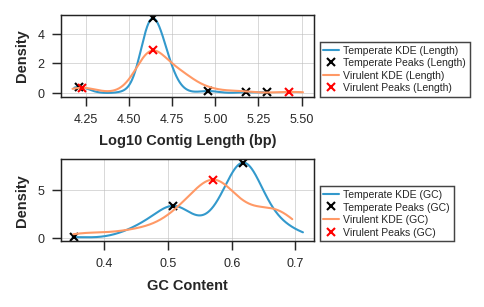

In [76]:
# Split high-quality phages by lifestyle
temperate_data = metadata_df_high_active_phyllosphere[metadata_df_high_active_phyllosphere['BACPLHIP_lifestyle'] == 'Temperate']
virulent_data = metadata_df_high_active_phyllosphere[metadata_df_high_active_phyllosphere['BACPLHIP_lifestyle'] == 'Virulent']

temperate_data = temperate_data.copy()
virulent_data = virulent_data.copy()
temperate_data["checkV_contig_length_log"] = np.log10(pd.to_numeric(temperate_data["checkV_contig_length"], errors="coerce"))
virulent_data["checkV_contig_length_log"] = np.log10(pd.to_numeric(virulent_data["checkV_contig_length"], errors="coerce"))
temperate_data['GC'] = pd.to_numeric(temperate_data['GC'], errors='coerce')
virulent_data['GC'] = pd.to_numeric(virulent_data['GC'], errors='coerce')
temperate_data = temperate_data.replace([np.inf, -np.inf], np.nan).dropna(subset=['checkV_contig_length_log', 'GC'])
virulent_data = virulent_data.replace([np.inf, -np.inf], np.nan).dropna(subset=['checkV_contig_length_log', 'GC'])

# Compute temperate length KDE
kde_temperate_x = gaussian_kde(temperate_data['checkV_contig_length_log'])
x_temperate = np.linspace(temperate_data['checkV_contig_length_log'].min(), 
                          temperate_data['checkV_contig_length_log'].max(), 1000)
kde_temperate_values_x = kde_temperate_x(x_temperate)

# Compute virulent length KDE
kde_virulent_x = gaussian_kde(virulent_data['checkV_contig_length_log'])
x_virulent = np.linspace(virulent_data['checkV_contig_length_log'].min(), 
                         virulent_data['checkV_contig_length_log'].max(), 1000)
kde_virulent_values_x = kde_virulent_x(x_virulent)

# Detect dominant length peaks
peaks_temperate_x, _ = find_peaks(kde_temperate_values_x)
peaks_virulent_x, _ = find_peaks(kde_virulent_values_x)

# --- Do the same for the Y-axis (GC) ---

# Compute temperate GC KDE
kde_temperate_y = gaussian_kde(temperate_data['GC'])
y_temperate = np.linspace(temperate_data['GC'].min(), temperate_data['GC'].max(), 1000)
kde_temperate_values_y = kde_temperate_y(y_temperate)

# Compute virulent GC KDE
kde_virulent_y = gaussian_kde(virulent_data['GC'])
y_virulent = np.linspace(virulent_data['GC'].min(), virulent_data['GC'].max(), 1000)
kde_virulent_values_y = kde_virulent_y(y_virulent)

# Find GC KDE peaks
peaks_temperate_y, _ = find_peaks(kde_temperate_values_y)
peaks_virulent_y, _ = find_peaks(kde_virulent_values_y)

# Report peaks in original units
print("Temperate Local Maxima (checkV_contig_length_log values):", 
      [int(10**val) for val in x_temperate[peaks_temperate_x]])
print("Virulent Local Maxima (checkV_contig_length_log values):", 
      [int(10**val) for val in x_virulent[peaks_virulent_x]])

print("Temperate Local Maxima (GC values):", 
      [round(float(val), 4) for val in y_temperate[peaks_temperate_y]])
print("Virulent Local Maxima (GC values):", 
      [round(float(val), 4) for val in y_virulent[peaks_virulent_y]])


# Plot KDEs and peak calls

plt.figure(figsize=(4, 2))

# --- X-axis (Log10 Contig Length) KDE Plot ---

# Plot temperate length KDE
plt.subplot(2, 1, 1)  # 2 rows, 2 columns, plot 1
plt.plot(x_temperate, kde_temperate_values_x, label='Temperate KDE (Length)', color=palette_lifestyle["Temperate"])
plt.plot(x_temperate[peaks_temperate_x], kde_temperate_values_x[peaks_temperate_x], "x", 
         label='Temperate Peaks (Length)', color='black')

# Plot virulent length KDE
plt.plot(x_virulent, kde_virulent_values_x, label='Virulent KDE (Length)', color=palette_lifestyle["Virulent"])
plt.plot(x_virulent[peaks_virulent_x], kde_virulent_values_x[peaks_virulent_x], "x", 
         label='Virulent Peaks (Length)', color='red')

plt.xlabel('Log10 Contig Length (bp)')
plt.ylabel('Density')
plt.legend(loc='lower left', bbox_to_anchor=(1.02, 0), borderaxespad=0)

# --- Y-axis (GC) KDE Plot ---

# Plot temperate GC KDE
plt.subplot(2, 1, 2)  # 2 rows, 2 columns, plot 2
plt.plot(y_temperate, kde_temperate_values_y, label='Temperate KDE (GC)', color=palette_lifestyle["Temperate"])
plt.plot(y_temperate[peaks_temperate_y], kde_temperate_values_y[peaks_temperate_y], "x", 
         label='Temperate Peaks (GC)', color='black')

# Plot virulent GC KDE
plt.plot(y_virulent, kde_virulent_values_y, label='Virulent KDE (GC)', color=palette_lifestyle["Virulent"])
plt.plot(y_virulent[peaks_virulent_y], kde_virulent_values_y[peaks_virulent_y], "x", 
         label='Virulent Peaks (GC)', color='red')

plt.xlabel('GC Content')
plt.ylabel('Density')
plt.legend(loc='lower left', bbox_to_anchor=(1.02, 0), borderaxespad=0)

tight_layout_with_legend()
plt.show()

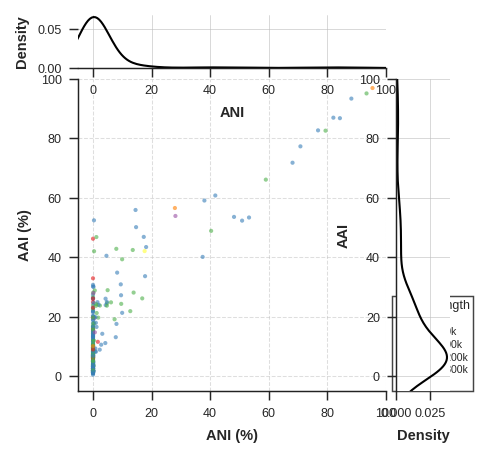

In [77]:
# Load and filter data
distance_df = pd.read_csv(
    "/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/07_ANNOTATION/active_and_refseq_distance.tsv", 
    sep="\t"
)

# Keep phyllosphere queries and NC targets
distance_df = distance_df[distance_df["qname"].isin(metadata_df_high_active_phyllosphere.index.to_list())]
distance_df = distance_df[distance_df["tname"].str.startswith("NC")]

# Keep top AAI hit per query
best_hits = distance_df.sort_values("AAI").groupby("qname").last()

# Merge contig lengths
df_plot = best_hits.merge(
    metadata_df_high_active_phyllosphere[["checkV_contig_length"]],
    left_index=True, right_index=True
)

# Define bins and labels
bins = [0, 20000, 50000, 100000, 200000, 300000, float("inf")]
labels = ["<20k", "20k–50k", "50k–100k", "100k–200k", "200k–300k", ">300k"]

# Create category column
df_plot["contig_length_cat"] = pd.cut(
    df_plot["checkV_contig_length"], bins=bins, labels=labels, right=False
)

# Create scatter-only jointplot
ax = sns.jointplot(
    data=df_plot,
    x="ANI",
    y="AAI",
    hue="contig_length_cat",
    palette="Set1",
    alpha=0.6,
    height=3,
    edgecolor="none",
    marker="."
)

# Clear default marginals
ax.ax_marg_x.cla()
ax.ax_marg_y.cla()

# Draw overall marginal KDEs
sns.kdeplot(data=df_plot, x="ANI", ax=ax.ax_marg_x, color="black")
sns.kdeplot(data=df_plot, y="AAI", ax=ax.ax_marg_y, color="black")

# Set axis limits
ax.ax_joint.set_xlim(-5, 100)
ax.ax_joint.set_ylim(-5, 100)

# Set labels
ax.ax_joint.set_xlabel("ANI (%)")
ax.ax_joint.set_ylabel("AAI (%)")

# Add grid
ax.ax_joint.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.5)

# Add legend
ax.ax_joint.legend(title="Contig length", loc='lower left', bbox_to_anchor=(1.02, 0), borderaxespad=0)

tight_layout_with_legend(ax.fig)
plt.savefig("/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/FIGURES_AND_TABLES/ani_aai_refseq_hits.svg")
plt.show()


### Host GC Content


### Calculate Host GC Content


In [78]:
# (base) lmf@thoth:~/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/SOURMASH/sketch/fasta_phyllovir_sketch_strain$ for fasta in *fna; do seqtk comp $fasta >> ../nucleotide_composition.tsv ; done
# for f in *.fasta *.fna; do     [ -e "$f" ] || continue;     grep "^>" "$f" | sed 's/^>//' | while read contig; do         echo -e "$f\t$contig" >> ../mapping_files.csv ;     done; done

contig_gc=pd.read_csv("/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/SOURMASH/sketch/nucleotide_composition.tsv", sep="\t", 
                         names=["contig","seq_length", "A", "C", "G", "T", "#2", "#3", "#4", 
                                          "#CpG", "#tv", "#ts", "#CpG-ts"])[["contig", "seq_length", "C", "G"]].set_index("contig")

mapping_df=pd.read_csv("/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/SOURMASH/sketch/mapping_files.csv", sep="\t", names= ["file", "contig"])
mapping_df["contig"]=mapping_df["contig"].str.split().str[0]
mapping_df["file"]=mapping_df["file"].str.split("_genomic").str[0]

contig_gc=mapping_df.merge(contig_gc, left_on="contig", right_index=True)
microbial_gc=contig_gc.groupby("file").sum().reset_index()
microbial_gc["GC_c"]=microbial_gc["G"]+microbial_gc["C"]
microbial_gc["GC"]=microbial_gc["GC_c"]/microbial_gc["seq_length"]

bacterial_taxonomy=pd.read_csv("/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/SOURMASH/taxonomy/taxonomy_all.csv")


strains_microbial_gc=microbial_gc.merge(bacterial_taxonomy, left_on="file", right_on="ident", how="left").set_index("file").sort_values("species")
strains_microbial_gc = strains_microbial_gc.applymap(
    lambda x: x.strip() if isinstance(x, str) else x)


### Lifestyle GC Boxplots


Percentage difference (Bacterial - Temperate) for Pseudomonas: 2.05%
95% CI: [1.15%, 2.78%]
Percentage difference (Bacterial - Virulent) for Pseudomonas: 7.59%
95% CI: [1.96%, 16.41%]
--------------------------------------------------
Percentage difference (Bacterial - Temperate) for Sphingomonas: 5.47%
95% CI: [4.71%, 6.23%]
Percentage difference (Bacterial - Virulent) for Sphingomonas: 7.69%
95% CI: [5.03%, 10.81%]
--------------------------------------------------
Percentage difference (Bacterial - Temperate) for Pantoea: 6.52%
95% CI: [5.29%, 7.63%]
Percentage difference (Bacterial - Virulent) for Pantoea: 13.57%
95% CI: [4.15%, 34.89%]
--------------------------------------------------
Percentage difference (Bacterial - Temperate) for Erwinia: 9.57%
95% CI: [7.19%, 12.84%]
Percentage difference (Bacterial - Virulent) for Erwinia: 7.73%
95% CI: [2.84%, 13.20%]
--------------------------------------------------


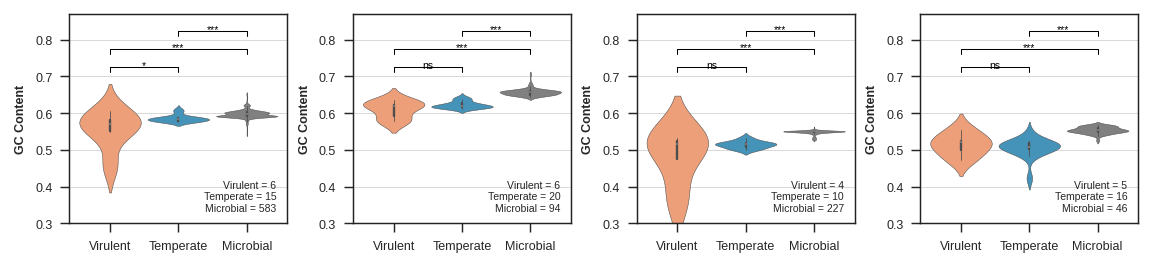

In [79]:
# Filter one genus at a time
genera = ["Pseudomonas", "Sphingomonas", "Pantoea", "Erwinia"]

# Create a 2x2 figure
fig, axs = plt.subplots(1, 4, figsize=(550*points_to_inches, 125*points_to_inches), sharey=False)

# Flatten axes array
axs = axs.flatten()

# Plot each genus as a combined violin plot
for i, genus in enumerate(genera):
    # Combine virulent, temperate, and bacterial data
    virulent_subset = virulent_data[virulent_data["genus"] == genus].copy()
    temperate_subset = temperate_data[temperate_data["genus"] == genus].copy()
    bacterial_subset = strains_microbial_gc[strains_microbial_gc["genus"] == genus].copy()
    
    # Add type labels
    virulent_subset["Type"] = "Virulent"
    temperate_subset["Type"] = "Temperate"
    bacterial_subset["Type"] = "Microbial"
    
    # Concatenate all subsets
    combined_data = pd.concat([virulent_subset, temperate_subset, bacterial_subset])
    
    # Draw violin plot
    sns.violinplot(data=combined_data, x="Type", y="GC", ax=axs[i], palette=palette_lifestyle, linewidth=0.25,width=0.9)
    
    # Set titles and labels
    axs[i].set_xlabel("")
    axs[i].set_ylabel("GC Content" , fontsize=6)

    axs[i].set_ylim(0.3, 0.87)
    
    # Run t tests against bacteria
    virulent_gc = virulent_subset["GC"]
    temperate_gc = temperate_subset["GC"]
    bacterial_gc = bacterial_subset["GC"]

    # Compute mean differences
    mean_diff_bacterial_temperate = (bacterial_gc.mean() - temperate_gc.mean()) / temperate_gc.mean() * 100
    mean_diff_bacterial_virulent = (bacterial_gc.mean() - virulent_gc.mean()) / virulent_gc.mean() * 100

    # Bootstrap confidence intervals
    ci_bacterial_temperate = bootstrap_ci(bacterial_gc, temperate_gc)
    ci_bacterial_virulent = bootstrap_ci(bacterial_gc, virulent_gc)

    # Print results and confidence intervals
    print(f"Percentage difference (Bacterial - Temperate) for {genus}: {mean_diff_bacterial_temperate:.2f}%")
    print(f"95% CI: [{ci_bacterial_temperate[0]:.2f}%, {ci_bacterial_temperate[1]:.2f}%]")
    print(f"Percentage difference (Bacterial - Virulent) for {genus}: {mean_diff_bacterial_virulent:.2f}%")
    print(f"95% CI: [{ci_bacterial_virulent[0]:.2f}%, {ci_bacterial_virulent[1]:.2f}%]")
    print('-' * 50)

    # Store p values
    p_vals = {}
    p_vals['Virulent vs Temperate'] = stats.ttest_ind(virulent_gc, temperate_gc, nan_policy='omit')[1]
    p_vals['Virulent vs Bacterial'] = stats.ttest_ind(virulent_gc, bacterial_gc, nan_policy='omit')[1]
    p_vals['Temperate vs Bacterial'] = stats.ttest_ind(temperate_gc, bacterial_gc, nan_policy='omit')[1]

    # Annotate p values
    y_max = 0.63  # Fixed max value for annotations
    y_offset = (0.077 * y_max)  # Offset for annotation positions

    # Get x tick positions
    x_ticks = axs[i].get_xticks()
    x_ticklabels = [tick.get_text() for tick in axs[i].get_xticklabels()]

    # Map categories to x positions
    x_mapping = {label: pos for label, pos in zip(x_ticklabels, x_ticks)}

    # Draw significance brackets
    for j, (comparison, p_val) in enumerate(p_vals.items()):
        if "Virulent" in comparison and "Temperate" in comparison:
            x1, x2 = x_mapping['Virulent'], x_mapping['Temperate']
        elif "Virulent" in comparison and "Bacterial" in comparison:
            x1, x2 = x_mapping['Virulent'], x_mapping['Microbial']
        elif "Temperate" in comparison and "Bacterial" in comparison:
            x1, x2 = x_mapping['Temperate'], x_mapping['Microbial']
        
        y = y_max + (y_offset * (j + 1))  # Adjust the y position for each annotation
        axs[i].plot([x1, x1, x2, x2], [y + 0.035, y + y_offset , y + y_offset, y + 0.035], lw=0.5, c='k')
        axs[i].text((x1 + x2) * 0.5, y + y_offset - 0.01, significance_asterisks(p_val), ha='center', va='bottom', color='k', fontsize=5)

    # Label sample counts
    axs[i].text(0.95, 0.05, 
                f'Virulent = {len(virulent_subset)}\nTemperate = {len(temperate_subset)}\nMicrobial = {len(bacterial_subset)}', 
                horizontalalignment='right', verticalalignment='bottom', 
                transform=axs[i].transAxes, fontsize=5)

# Tighten layout
plt.tight_layout()

plt.savefig("/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/FIGURES_AND_TABLES/gc_genus_lifestyle.svg")

# Show plot
plt.show()


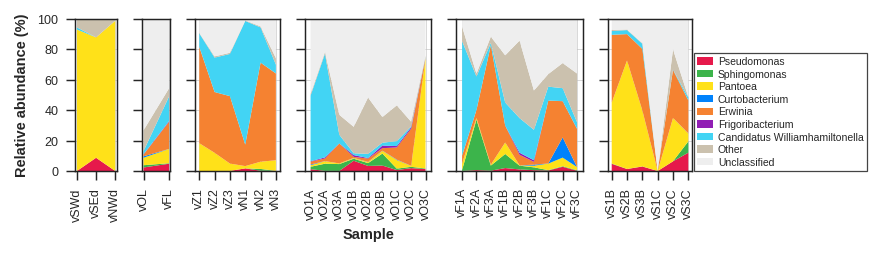

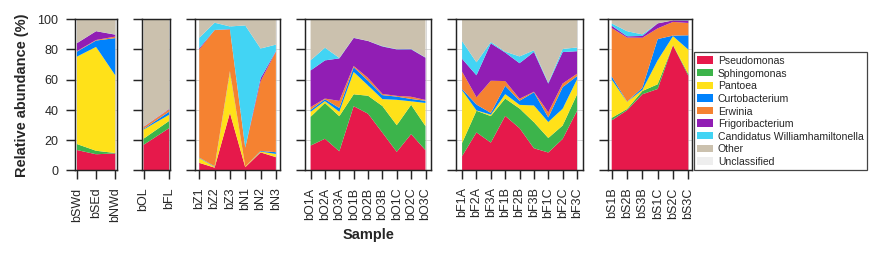

In [80]:
host_df=phyllosphere_active_metadata[desired_ranks + ["BACPLHIP_lifestyle"] + SAMPLES]

relative_genus_grouped_df=host_df.groupby(['genus'])[SAMPLES].sum().apply(pd.to_numeric, errors='coerce')

plot_stackplot_dict(filter_top_taxa(relative_genus_grouped_df.T, 3, palette_genus), viral_group_samples_dict, "genus", palette_genus)
plot_stackplot_dict(filter_top_taxa(bacterial_relative_genus_sample_df.T, 3, palette_genus), bacterial_group_samples_dict, "genus", palette_genus)


### Host-Linked Exploratory Analyses


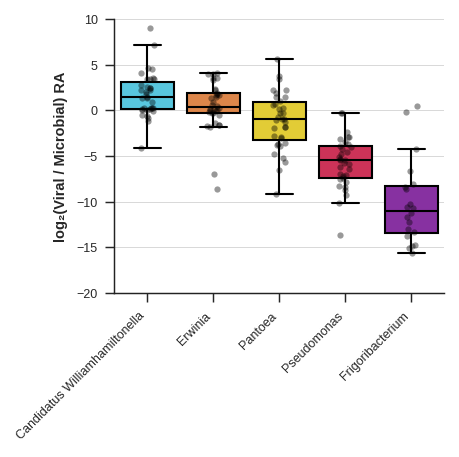

In [81]:

df_temperate_vs_microbial,df_virulent_vs_microbial,df_combined_vs_microbial=get_temperate_virulent_microbial_relative_sample(temperate_data, virulent_data, strains_microbial_gc,"genus", SAMPLES) 
df_combined_vs_microbial["ratio"]=df_combined_vs_microbial["combined"]/df_combined_vs_microbial["microbial"] 
df_combined_vs_microbial_host_prevalence=df_combined_vs_microbial.merge(host_prevalence[["genus", "category"]], left_on="genus", right_on="genus") 
df_combined_vs_microbial_host_prevalence[df_combined_vs_microbial_host_prevalence["category"].isin(["ubiquitous"])].sort_values("ratio",ascending=False)

# Define custom colors
genus_colors = {
    'Pseudomonas': '#E6194B',
    'Sphingomonas': '#3CB44B',
    'Pantoea': '#FFE119',
    'Curtobacterium': '#0082FC',
    'Erwinia': '#F58231',
    'Frigoribacterium': '#911EB4',
    'Candidatus Williamhamiltonella': '#42D4F4'
}

# Filter and prepare data
df_plot = df_combined_vs_microbial_host_prevalence.query("category == 'ubiquitous'").copy()
df_plot["log2_ratio"] = np.log2(df_plot["ratio"].replace(0, np.nan))

# Compute and sort mean log2 ratios
genus_order = (
    df_plot.groupby("genus")["log2_ratio"]
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)

# Restrict palette to plotted genera
palette = {g: genus_colors.get(g, "gray") for g in genus_order}

# Plot results
plt.figure(figsize=(3, 3))
sns.boxplot(
    data=df_plot,
    x="genus",
    y="log2_ratio",
    order=genus_order,
    palette=palette,
    showfliers=False,       
    linewidth=1,
    linecolor="black"
)
sns.stripplot(
    data=df_plot,
    x="genus",
    y="log2_ratio",
    order=genus_order,
    color="black",
    size=3,
    jitter=True,
    alpha=0.4
)

# Format plot
plt.ylabel("log₂(Viral / Microbial) RA")
plt.xlabel("")
plt.xticks(rotation=45, ha="right")
plt.ylim(-20, 10)
sns.despine()
plt.tight_layout()
plt.savefig("/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/FIGURES_AND_TABLES/log2_ratio_ubiquitous.svg")

plt.show()


In [82]:
df_plot.groupby("genus")[["log2_ratio"]].mean(numeric_only=True)

,log2_ratio
genus,
Candidatus Williamhamiltonella,1.739724
Erwinia,0.422343
Frigoribacterium,-10.136415
Pantoea,-1.180969
Pseudomonas,-5.712858


## Core And Common Phages


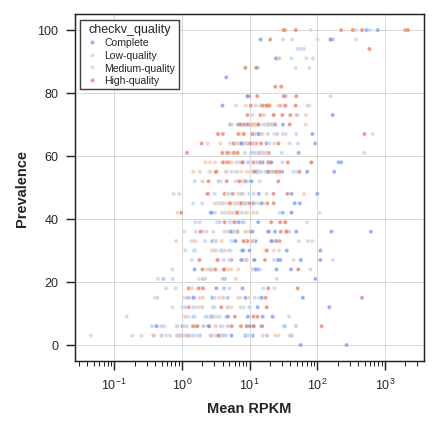

In [83]:
# Use precomputed abundance tables
plot_df_core = df_abundances_core[["vOTU", "mean_rpkm", "sample_percentage", "checkv_quality"]].dropna()

# Create plot
plt.figure(figsize=(3, 3))

# Color points by checkV quality
sns.scatterplot(data=plot_df_core, x='mean_rpkm', y='sample_percentage', 
                hue='checkv_quality', palette='coolwarm',  alpha=0.8,# You can choose other palettes too
                s=4, legend=True)  # Set legend to True to see the categories

# Set labels and title
plt.xlabel('Mean RPKM')
plt.ylabel('Prevalence')

# Use log-scaled x axis
plt.xscale("log")

# Show grid
plt.grid(True)

# Show plot
plt.show()


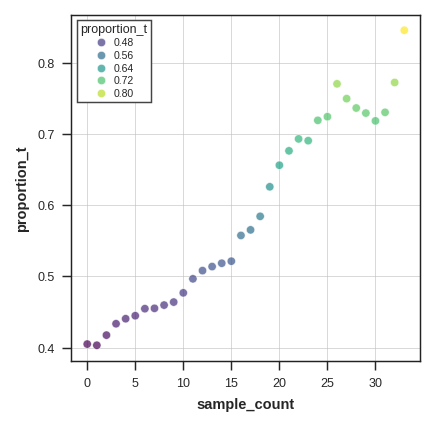

Spearman correlation: 0.986, p-value: 1.36e-26


In [84]:
# Optional scatter from the Figure 2 summary table
plot_df = summary_prevalence_df[["sample_count", "proportion_temperate"]].rename(columns={
    "proportion_temperate": "proportion_t"
}).copy()

plt.figure(figsize=(3,3))
sns.scatterplot(data=plot_df, x='sample_count', y='proportion_t', hue='proportion_t', palette='viridis', alpha=0.7)
plt.show()

spearman_corr, spearman_p = spearmanr(plot_df['sample_count'], plot_df['proportion_t'])
print(f"Spearman correlation: {spearman_corr:.3f}, p-value: {fmt_pvalue(spearman_p)}")
